# Human Action Recognition in Videos: CNN vs GNN, LSTM vs Transformer

**Authors:** Wassim Bahmani, Lucas Landemaine, Liam Touier
### End-to-end study: 2D CNN (MobileNetV2) and skeleton graph (GNN), combined with a recurrent model (LSTM) or an attention model (Transformer), on the KTH dataset

---

## Context and goals

Recognizing a human action in a video requires combining two kinds of information:

- **spatial information** ("what do we see in *one* frame?"): posture, position of the arms and legs, silhouette;
- **temporal information** ("how does it evolve *from one frame to the next*?"): speed, rhythm, order of movements.

> **Concrete example.** In a single frame, a person with legs apart could be **walking**, **jogging** or **running**: it is the *speed* of displacement and the *frequency* of steps that settle it. Conversely, **boxing** and **hand clapping** can already be partly told apart from a still image (arms stretched forward vs hands joined in front of the chest).

In this project, we build a benchmark comparing **five architectures**. They combine two ways of representing a frame with three ways of modeling time:

| #   | Model                  | Each frame is represented by…  | Time is modeled by…                                  | Question asked                                   |
| ----| -----------------------| -------------------------------| -----------------------------------------------------| -------------------------------------------------|
| 1   | **Temporal mean**      | a CNN vector (1280 values)     | nothing: frames are averaged                         | Is appearance alone enough?                      |
| 2   | **CNN + LSTM**         | a CNN vector                   | a recurrent network (reads frame by frame)           | Does sequential memory help?                     |
| 3   | **CNN + Transformer**  | a CNN vector                   | self-attention (every frame "looks at" every other)  | Does attention beat recurrence?                  |
| 4   | **GNN + LSTM**         | a 17-joint skeleton            | an LSTM                                              | Is a compact skeleton enough?                    |
| 5   | **GNN + Transformer**  | a 17-joint skeleton            | a Transformer                                        | Which combination is best?                       |

---

### Notebook outline
| Part | Content |
|---|---|
| 0 | Environment, KTH download, subject-wise split |
| 1 | **Visual exploration of the videos**: gallery, scenarios, animations, motion, sampling |
| 2 | CNN features (frozen MobileNetV2) and visualization |
| 3 | The three temporal heads on CNN features: training, curves, test |
| 4 | Sequence length ablation |
| 5 | Skeletons and graph neural networks (GNN) |
| 6 | Overall comparison of the 5 models |
| 7 | **Prediction examples on videos** and interpretability |
| 8 | Summary and conclusions |
| 9 | Extension: statistical robustness (multiple seeds, per-person bootstrap) |
| 10 | **Second protocol**: official KTH split, alternative heads, 11 seeds, controls |
| 11 | Extension A: action segments (`00sequences.txt`) and dense sampling |
| 12 | Extension B: explicit motion signal |
| 13 | Step 4: subject-wise 5-fold cross-validation |
| 14 | Comparing the two protocols and overall conclusion |

### Short glossary
- **Frame**: one image of the video (KTH: 25 frames per second, 160 × 120 pixels).
- **Clip / sequence**: the $T$ frames extracted from a video and fed to the model.
- **Head**: the small part of the network trained on top of frozen features.
- **Logits**: raw scores (one per class) before the *softmax*, which turns them into probabilities.
- **Ablation**: varying a single parameter (here $T$) to measure its effect.

> **About the commented results.** The analyses in this notebook quote the numbers from the **reference run** whose outputs are saved here (real KTH, Tesla T4 GPU, seed 42). If you re-run the notebook, you will get close but not identical values, because GPU computations differ slightly from one card to another.

In [1]:
####### Environment, dependencies and hardware check #######
import os
import sys
import time
import math
import random
import shutil
import zipfile
import urllib.request
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import animation
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import HTML, display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models.detection import keypointrcnn_resnet50_fpn, KeypointRCNN_ResNet50_FPN_Weights

import cv2
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

def seed_everything(seed=42):
    """Makes experiments reproducible: same seed => same initial weights and same batch order."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Plot style: subtle grid, fixed categorical palette (always in the same order)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({"grid.linestyle": ":", "grid.alpha": 0.6,
                     "axes.spines.top": False, "axes.spines.right": False})
plt.rcParams["animation.embed_limit"] = 60  # MB: max size of animations embedded in the notebook

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Compute device  : {device}")
if torch.cuda.is_available():
    print(f"GPU model       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Running on CPU. On Google Colab, enable the GPU: Runtime > Change runtime type > T4 GPU.")

PyTorch version : 2.11.0+cu130
Compute device  : cuda
GPU model       : Tesla T4
GPU memory      : 15.64 GB


### Analysis: environment and reproducibility
- **Fixed random seed** (`seed_everything(42)`) for Python, NumPy and CUDA: weight initialization and batch order are identical from one run to the next. Without it, two runs of the same code could differ by a few accuracy points, which would bias the comparison between models.
- **The GPU** mainly speeds up the heavy early steps: passing frames through MobileNetV2 and, in part 5, through the pose estimator.
- **On-disk caching**: these expensive computations are done only once. Afterwards, every temporal model trains in a few seconds on precomputed tensors.

---
# Part 0: The KTH dataset

**KTH** (Schüldt, Laptev and Caputo, 2004) is a classic action recognition dataset:
- **6 actions** performed by **25 people** in **4 scenarios**: $d_1$ outdoors, $d_2$ outdoors with scale variations (zoom), $d_3$ outdoors with different clothes, $d_4$ indoors;
- **599 grayscale videos** (one video is missing from the official release), 160 × 120 pixels, 25 fps, static camera, fairly uniform background;
- **long** videos: 8 to 60 seconds (median ≈ 18 s). The person repeats the action several times; for locomotion actions, they cross the field of view several times, back and forth.

| Label | Action | Visual signature |
|---|---|---|
| `boxing` | boxing | alternating forward punches; the person stays in place |
| `handclapping` | hand clapping | hands meet in front of the chest, in place |
| `handwaving` | hand waving | both raised arms swing above the head, in place |
| `jogging` | jogging | the person crosses the frame at medium speed |
| `running` | running | the person crosses the frame fast, with long strides |
| `walking` | walking | the person crosses the frame slowly |

Two **families** of actions already stand out: **"in-place"** actions (arms: boxing, clapping, waving) and **"locomotion"** actions (legs: walking, jogging, running). We expect confusions to happen mostly *within* a family.

In [2]:
####### Automatic KTH download (≈ 1 GB) and folder layout #######
DATA_ROOT  = os.path.join(os.getcwd(), "kth_dataset")
SYNTH_ROOT = os.path.join(os.getcwd(), "kth_synthetic")   # offline fallback, in a separate folder

# The 6 KTH actions (official names = folder names) and their display names
CLASSES = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
CLASS_TO_IDX = {cls_name: i for i, cls_name in enumerate(CLASSES)}
IDX_TO_CLASS = {i: cls_name for cls_name, i in CLASS_TO_IDX.items()}
DISPLAY_NAMES = {"boxing": "boxing", "handclapping": "hand clapping", "handwaving": "hand waving",
                 "jogging": "jogging", "running": "running", "walking": "walking"}
SCENARIOS = {"d1": "outdoors", "d2": "outdoors + zoom", "d3": "different clothes", "d4": "indoors"}
CLASS_COLORS = dict(zip(CLASSES, PALETTE))

# KTH mirrors, tried in order.
KTH_MIRRORS = [
    "https://www.csc.kth.se/cvap/actions/",
    "http://www.nada.kth.se/cvap/actions/",
]
MIN_VIDEOS_PER_CLASS = 90   # KTH has 100 videos per action (99 for handclapping)

def download_kth(classes=CLASSES, folder=DATA_ROOT):
    """
    Downloads and extracts the 6 KTH archives.
    Returns True if every action is present on disk.
    """
    os.makedirs(folder, exist_ok=True)
    for cls in classes:
        cls_dir = os.path.join(folder, cls)
        os.makedirs(cls_dir, exist_ok=True)
        n_existing = len(glob(os.path.join(cls_dir, "*.avi")))
        if n_existing >= MIN_VIDEOS_PER_CLASS:
            print(f"'{cls}': {n_existing} videos already present, skipping download.")
            continue

        zip_path = os.path.join(folder, f"{cls}.zip")
        for base_url in KTH_MIRRORS:
            url = f"{base_url}{cls}.zip"
            try:
                print(f"Downloading {url} ...")
                req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=60) as response, open(zip_path, 'wb') as out_file:
                    shutil.copyfileobj(response, out_file)
                # ZipFile raises an error if the server returned an HTML page instead of a zip
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(cls_dir)
                print(f"  -> '{cls}' extracted: {len(glob(os.path.join(cls_dir, '*.avi')))} videos.")
                break
            except Exception as e:
                print(f"  Failed with this mirror ({e}).")
            finally:
                if os.path.exists(zip_path):
                    os.remove(zip_path)

    return all(len(glob(os.path.join(folder, c, "*.avi"))) >= MIN_VIDEOS_PER_CLASS for c in classes)


# ---------- Fallback: small synthetic "stick figure" videos ----------
W_SYN, H_SYN = 160, 120

def _synthetic_pose(action, t, p):
    """(x, y) pixel position of each stick-figure joint at frame t (p: parameters of the person)."""
    s, phi, d = p['size'], p['omega'] * t + p['phase'], p['direction']

    def segment(origin, length, angle):
        # angle measured from the downward vertical, positive towards the front (walking direction)
        return (origin[0] + d * length * s * math.sin(angle), origin[1] + length * s * math.cos(angle))

    if action in ("walking", "jogging", "running"):
        cx = (p['x0'] + d * p['speed'] * s * t + 20) % (W_SYN + 40) - 20   # crosses the frame, then comes back
    else:
        cx = p['x0']
    hy = p['ground'] - 0.5 * s
    pelvis, neck = (cx, hy), (cx, hy - 0.45 * s)
    pts = {'head': (cx, hy - 0.58 * s), 'neck': neck, 'pelvis': pelvis}

    if action in ("walking", "jogging", "running"):          # side view
        amplitude = {"walking": 0.35, "jogging": 0.55, "running": 0.8}[action]
        elbow_bend = {"walking": 0.3, "jogging": 1.2, "running": 1.6}[action]      # elbow bend
        for side, offset in (('l', 0.0), ('r', math.pi)):
            a = amplitude * math.sin(phi + offset)
            knee = segment(pelvis, 0.25, a)
            pts.update({f'shoulder_{side}': neck, f'hip_{side}': pelvis, f'knee_{side}': knee,
                        f'ankle_{side}': segment(knee, 0.25, a - 0.4 * amplitude * (1 + math.sin(phi + offset + 1.2)))})
            elbow = segment(neck, 0.17, -0.8 * a)
            pts.update({f'elbow_{side}': elbow, f'wrist_{side}': segment(elbow, 0.17, -0.8 * a + elbow_bend)})
    elif action == "boxing":                                 # side view: guard, then alternating punches
        for side, offset, leg in (('l', 0.0, 0.2), ('r', math.pi, -0.2)):
            e = max(0.0, math.sin(phi + offset)) ** 2      # 0 = guard, 1 = arm extended
            elbow = segment(neck, 0.17, 0.5 + e * (math.pi / 2 - 0.5))
            knee = segment(pelvis, 0.25, leg)
            pts.update({f'shoulder_{side}': neck, f'hip_{side}': pelvis, f'knee_{side}': knee,
                        f'ankle_{side}': segment(knee, 0.25, leg), f'elbow_{side}': elbow,
                        f'wrist_{side}': segment(elbow, 0.17, 2.5 + e * (math.pi / 2 - 2.5))})
    else:                                                    # front view: clapping or waving
        for side, sg in (('l', -1), ('r', 1)):
            pts[f'shoulder_{side}'] = (cx + sg * 0.12 * s, neck[1])
            pts[f'hip_{side}'] = (cx + sg * 0.07 * s, hy)
            pts[f'knee_{side}'] = (cx + sg * 0.09 * s, hy + 0.25 * s)
            pts[f'ankle_{side}'] = (cx + sg * 0.10 * s, hy + 0.5 * s)
            if action == "handclapping":
                opening = 0.02 + 0.13 * (1 + math.cos(phi)) / 2
                pts[f'elbow_{side}'] = (cx + sg * 0.20 * s, neck[1] + 0.17 * s)
                pts[f'wrist_{side}'] = (cx + sg * opening * s, neck[1] + 0.12 * s)
            else:  # handwaving
                pts[f'elbow_{side}'] = (cx + sg * 0.24 * s, neck[1] - 0.08 * s)
                pts[f'wrist_{side}'] = (cx + sg * (0.26 + 0.12 * math.sin(phi)) * s, neck[1] - 0.26 * s)
    return pts

_SEGMENTS_SYN = [('neck', 'pelvis'), ('shoulder_l', 'shoulder_r'), ('hip_l', 'hip_r'),
                 ('shoulder_l', 'elbow_l'), ('elbow_l', 'wrist_l'), ('shoulder_r', 'elbow_r'), ('elbow_r', 'wrist_r'),
                 ('hip_l', 'knee_l'), ('knee_l', 'ankle_l'), ('hip_r', 'knee_r'), ('knee_r', 'ankle_r')]

def generate_synthetic_kth(folder=SYNTH_ROOT, n_frames=75):
    """
    Offline fallback: 25 persons x 6 actions x 4 scenarios of 160x120 stick-figure videos.
    Each "person" has their own size, rhythm, position and contrast, so the task is not trivial.
    WARNING: results obtained on these videos say NOTHING about performance on the real KTH.
    """
    rng = np.random.default_rng(0)
    speeds = {"walking": (0.018, 0.026), "jogging": (0.035, 0.05), "running": (0.06, 0.085)}
    omegas = {"walking": 0.25, "jogging": 0.38, "running": 0.5, "boxing": 0.3, "handclapping": 0.45, "handwaving": 0.3}
    for cls in CLASSES:
        cls_dir = os.path.join(folder, cls)
        os.makedirs(cls_dir, exist_ok=True)
        for pid in range(1, 26):
            for sc in ["d1", "d2", "d3", "d4"]:
                path = os.path.join(cls_dir, f"person{pid:02d}_{cls}_{sc}_uncomp.avi")
                p = {'size': rng.uniform(40, 52) * (rng.uniform(1.2, 1.4) if sc == "d2" else 1.0),
                     'omega': omegas[cls] * rng.uniform(0.85, 1.15), 'phase': rng.uniform(0, 2 * np.pi),
                     'direction': rng.choice([-1, 1]), 'x0': W_SYN / 2 + rng.uniform(-25, 25), 'ground': rng.uniform(100, 112),
                     'speed': rng.uniform(*speeds.get(cls, (0, 0)))}
                background = int(rng.uniform(90, 140) if sc == "d4" else rng.uniform(160, 220))
                ink = int(rng.uniform(0, 70))
                thickness = 3 if sc == "d3" else 2
                if os.path.exists(path):
                    continue
                out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'XVID'), 25.0, (W_SYN, H_SYN))
                if not out.isOpened():
                    out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'MJPG'), 25.0, (W_SYN, H_SYN))
                for t in range(n_frames):
                    img = np.full((H_SYN, W_SYN, 3), background, np.uint8)
                    pts = {k: (int(round(x)), int(round(y))) for k, (x, y) in _synthetic_pose(cls, t, p).items()}
                    for a, b in _SEGMENTS_SYN:
                        cv2.line(img, pts[a], pts[b], (ink,) * 3, thickness)
                    cv2.circle(img, pts['head'], max(3, int(0.08 * p['size'])), (ink,) * 3, -1)
                    noise = rng.normal(0, 4, img.shape)
                    out.write(np.clip(img + noise, 0, 255).astype(np.uint8))
                out.release()


KTH_OK = download_kth()
if KTH_OK:
    DATASET_DIR, USING_SYNTHETIC_DATA = DATA_ROOT, False
else:
    print("\n⚠️  KTH unavailable (no network?): generating the SYNTHETIC fallback dataset...")
    generate_synthetic_kth()
    DATASET_DIR, USING_SYNTHETIC_DATA = SYNTH_ROOT, True

n_videos = len(glob(os.path.join(DATASET_DIR, "*", "*.avi")))
print(f"\nAvailable videos: {n_videos}  |  source: {'SYNTHETIC (code testing only)' if USING_SYNTHETIC_DATA else 'official KTH'}")

  -> 'boxing' extracted: 100 videos.
  -> 'handclapping' extracted: 99 videos.
  -> 'handwaving' extracted: 100 videos.
  -> 'jogging' extracted: 100 videos.
  -> 'running' extracted: 100 videos.
  -> 'walking' extracted: 100 videos.

Available videos: 599  |  source: official KTH


### Analysis: data structure
- **File naming**: `person<ID>_<action>_<scenario>_uncomp.avi`. For example, `person03_walking_d1_uncomp.avi` is person #3 walking in scenario $d_1$. The person ID can therefore be read from the file name, which enables the subject-wise split in the next cell.
- **Why a synthetic fallback?** If the download fails (no network, server down), the notebook generates small "stick figure" videos mimicking the 6 actions. Each "person" has their own size, speed and position. This makes it possible to **check that all the code runs**, but **results obtained on this data say nothing about performance on the real KTH**. The last printed line shows which source is used.

In [3]:
####### Strict subject-wise split (no person shared between sets) #######
def parse_person_id(filepath):
    """Extracts the person ID from the file name (e.g. 'person03_walking_d1_uncomp.avi' -> 3)."""
    base = os.path.basename(filepath)
    return int(base.split('_')[0].replace('person', ''))

def parse_scenario(filepath):
    """Extracts the recording scenario (e.g. 'person03_walking_d1_uncomp.avi' -> 'd1')."""
    return os.path.basename(filepath).split('_')[2]

TRAIN_IDS = {11, 12, 13, 14, 15, 16, 17, 18}   # 8 persons
VAL_IDS   = {19, 20, 21, 23, 24, 25}           # 6 persons
# All the others (1 to 10, and 22) form the test set: 11 persons

def split_by_subject(dataset_dir=DATASET_DIR):
    """Splits the videos into train / val / test according to the person ID. Each item: (video_file, label, person)."""
    all_videos = sorted(glob(os.path.join(dataset_dir, "*", "*.avi")))   # sorted => same order on every machine
    splits = {'train': [], 'val': [], 'test': []}
    for vpath in all_videos:
        cls_name = os.path.basename(os.path.dirname(vpath))
        if cls_name not in CLASS_TO_IDX:
            continue
        pid, label = parse_person_id(vpath), CLASS_TO_IDX[cls_name]
        if pid in TRAIN_IDS:
            splits['train'].append((vpath, label, pid))
        elif pid in VAL_IDS:
            splits['val'].append((vpath, label, pid))
        else:
            splits['test'].append((vpath, label, pid))
    return splits

splits = split_by_subject()

train_pids = set(pid for _, _, pid in splits['train'])
val_pids   = set(pid for _, _, pid in splits['val'])
test_pids  = set(pid for _, _, pid in splits['test'])

assert train_pids.isdisjoint(val_pids),  "Subject leakage between training and validation!"
assert train_pids.isdisjoint(test_pids), "Subject leakage between training and test!"
assert val_pids.isdisjoint(test_pids),   "Subject leakage between validation and test!"

print("=" * 70)
print("SUBJECT-WISE SPLIT CHECK (requirement 3):")
print(f"  • Training   : persons {sorted(train_pids)} ({len(splits['train'])} videos)")
print(f"  • Validation : persons {sorted(val_pids)} ({len(splits['val'])} videos)")
print(f"  • Test       : persons {sorted(test_pids)} ({len(splits['test'])} videos)")
print("  Check      : NO person appears in two sets.")
print("=" * 70)

# Number of videos per action and per set
table = pd.DataFrame({
    name: pd.Series([CLASSES[l] for _, l, _ in splits[s]]).value_counts().reindex(CLASSES).fillna(0).astype(int)
    for s, name in [('train', 'Training'), ('val', 'Validation'), ('test', 'Test')]
})
table.index = [DISPLAY_NAMES[c] for c in CLASSES]
table.loc['TOTAL'] = table.sum()
display(table)

SUBJECT-WISE SPLIT CHECK (requirement 3):
  • Training   : persons [11, 12, 13, 14, 15, 16, 17, 18] (191 videos)
  • Validation : persons [19, 20, 21, 23, 24, 25] (144 videos)
  • Test       : persons [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 22] (264 videos)
  Check      : NO person appears in two sets.


,Training,Validation,Test
boxing,32,24,44
hand clapping,31,24,44
hand waving,32,24,44
jogging,32,24,44
running,32,24,44
walking,32,24,44
TOTAL,191,144,264


### Analysis: why split by person?
- **The pitfall**: if videos of person 11 were in both training and test, the model could recognize *the person* (clothes, height, silhouette) rather than *the movement*. Test accuracy would be inflated without the model actually learning to generalize.
- **Analogy**: it is like studying with the exact exam questions. You get a good grade without understanding the course.
- **Check**: the three `assert`s guarantee that no person appears in two sets (`isdisjoint`). Otherwise, the notebook would stop with an error.
- **Role of each set**:
  - *training*: fit the model weights;
  - *validation*: pick the best moment of training (the best epoch);
  - *test*: measure final performance, **only once**, on never-seen people.
- The actions are **balanced**: each person performs each action in each scenario, giving roughly the same number of videos per action (table above).

Sample video       : person11_boxing_d1_uncomp.avi
Action             : boxing
Duration           : 351 frames at 25 fps ≈ 14.0 s
Extracted clip (T_max, C, H, W) : (32, 3, 224, 224)


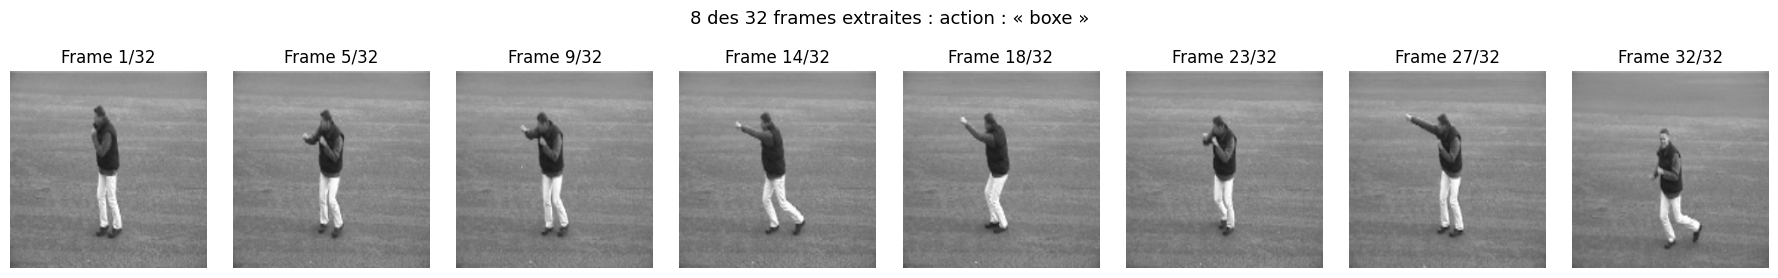

In [4]:
####### Reading videos and uniformly sampling T_max = 32 frames #######
MAX_FRAMES = 32   # number of frames cached per video (enables the T = 4, 8, 16, 32 ablation)
FRAME_SIZE = 224  # input resolution expected by MobileNetV2
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

imagenet_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((FRAME_SIZE, FRAME_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def read_raw_frames(video_path, num_frames=MAX_FRAMES):
    """
    Reads `num_frames` evenly spaced frames from the start to the end of the video.
    Returns an array (num_frames, H, W, 3) in RGB uint8, at the original size (handy for display).
    """
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return np.zeros((num_frames, 120, 160, 3), dtype=np.uint8)

    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames, frame_idx, ptr = [], 0, 0
    while ptr < num_frames:
        if not cap.grab():          # grab() advances without decoding the image: faster
            break
        if frame_idx == indices[ptr]:
            _, frame = cap.retrieve()
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            while ptr < num_frames and indices[ptr] == frame_idx:   # handles repeated indices (very short video)
                frames.append(rgb)
                ptr += 1
        frame_idx += 1
    cap.release()

    # If the video is shorter than advertised, repeat the last frame
    while len(frames) < num_frames:
        frames.append(frames[-1].copy() if frames else np.zeros((120, 160, 3), dtype=np.uint8))
    return np.stack(frames)

def extract_uniform_frames(video_path, num_frames=MAX_FRAMES):
    """Frames ready for the CNN: tensor (num_frames, 3, 224, 224) normalized like ImageNet."""
    frames = read_raw_frames(video_path, num_frames)
    return torch.stack([imagenet_transform(f) for f in frames], dim=0)

def denormalize(frame_tensor):
    """Inverse of the ImageNet normalization, to display a (3, H, W) tensor as an image."""
    img = frame_tensor.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

sample_vpath, sample_label, _ = splits['train'][0]
sample_clip = extract_uniform_frames(sample_vpath, MAX_FRAMES)
cap = cv2.VideoCapture(sample_vpath)
n_total, fps_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), cap.get(cv2.CAP_PROP_FPS) or 25.0
cap.release()

print(f"Sample video       : {os.path.basename(sample_vpath)}")
print(f"Action             : {DISPLAY_NAMES[IDX_TO_CLASS[sample_label]]}")
print(f"Duration           : {n_total} frames at {fps_video:.0f} fps ≈ {n_total / fps_video:.1f} s")
print(f"Extracted clip (T_max, C, H, W) : {tuple(sample_clip.shape)}")

fig, axes = plt.subplots(1, 8, figsize=(18, 2.6))
for i, t in enumerate(np.linspace(0, MAX_FRAMES - 1, 8, dtype=int)):
    axes[i].imshow(denormalize(sample_clip[t]))
    axes[i].set_title(f"Frame {t + 1}/32")
    axes[i].axis('off')
plt.suptitle(f"8 of the 32 extracted frames: action: \"{DISPLAY_NAMES[IDX_TO_CLASS[sample_label]]}\"", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### Analysis: uniform sampling of $T_{\max} = 32$ frames
- A KTH video contains several hundred frames (see the duration printed above). We keep only **32, evenly spaced** from start to end (`np.linspace`). This covers the whole video at a fixed compute cost, whatever its length. The trade-off: on an 18 s video, two kept frames are about 0.6 s apart. We will see that this choice has major consequences on the results.
- Each frame is resized to 224 × 224 and **normalized with the ImageNet mean and standard deviation**, since this is the format MobileNetV2 was trained on. For display, we apply the inverse operation (`denormalize`).
- From these 32 cached frames, we can instantly build sequences of $T \in \{4, 8, 16, 32\}$ frames for the ablation in part 4, without recomputing anything.

---
# Part 1: Visual exploration: what do the videos look like?

Before training any model, we need to **look at the data**. This helps understand what makes each action recognizable, anticipate likely confusions and choose a suitable representation.

This part presents five examples:
1. a **gallery** with one video per action;
2. the **4 recording scenarios** for the same action;
3. **animations** to watch the videos move at real speed;
4. the **motion** between two frames and the **rhythm** of each action;
5. the effect of **temporal sampling** ($T = 4, 8, 16, 32$) on the same video.

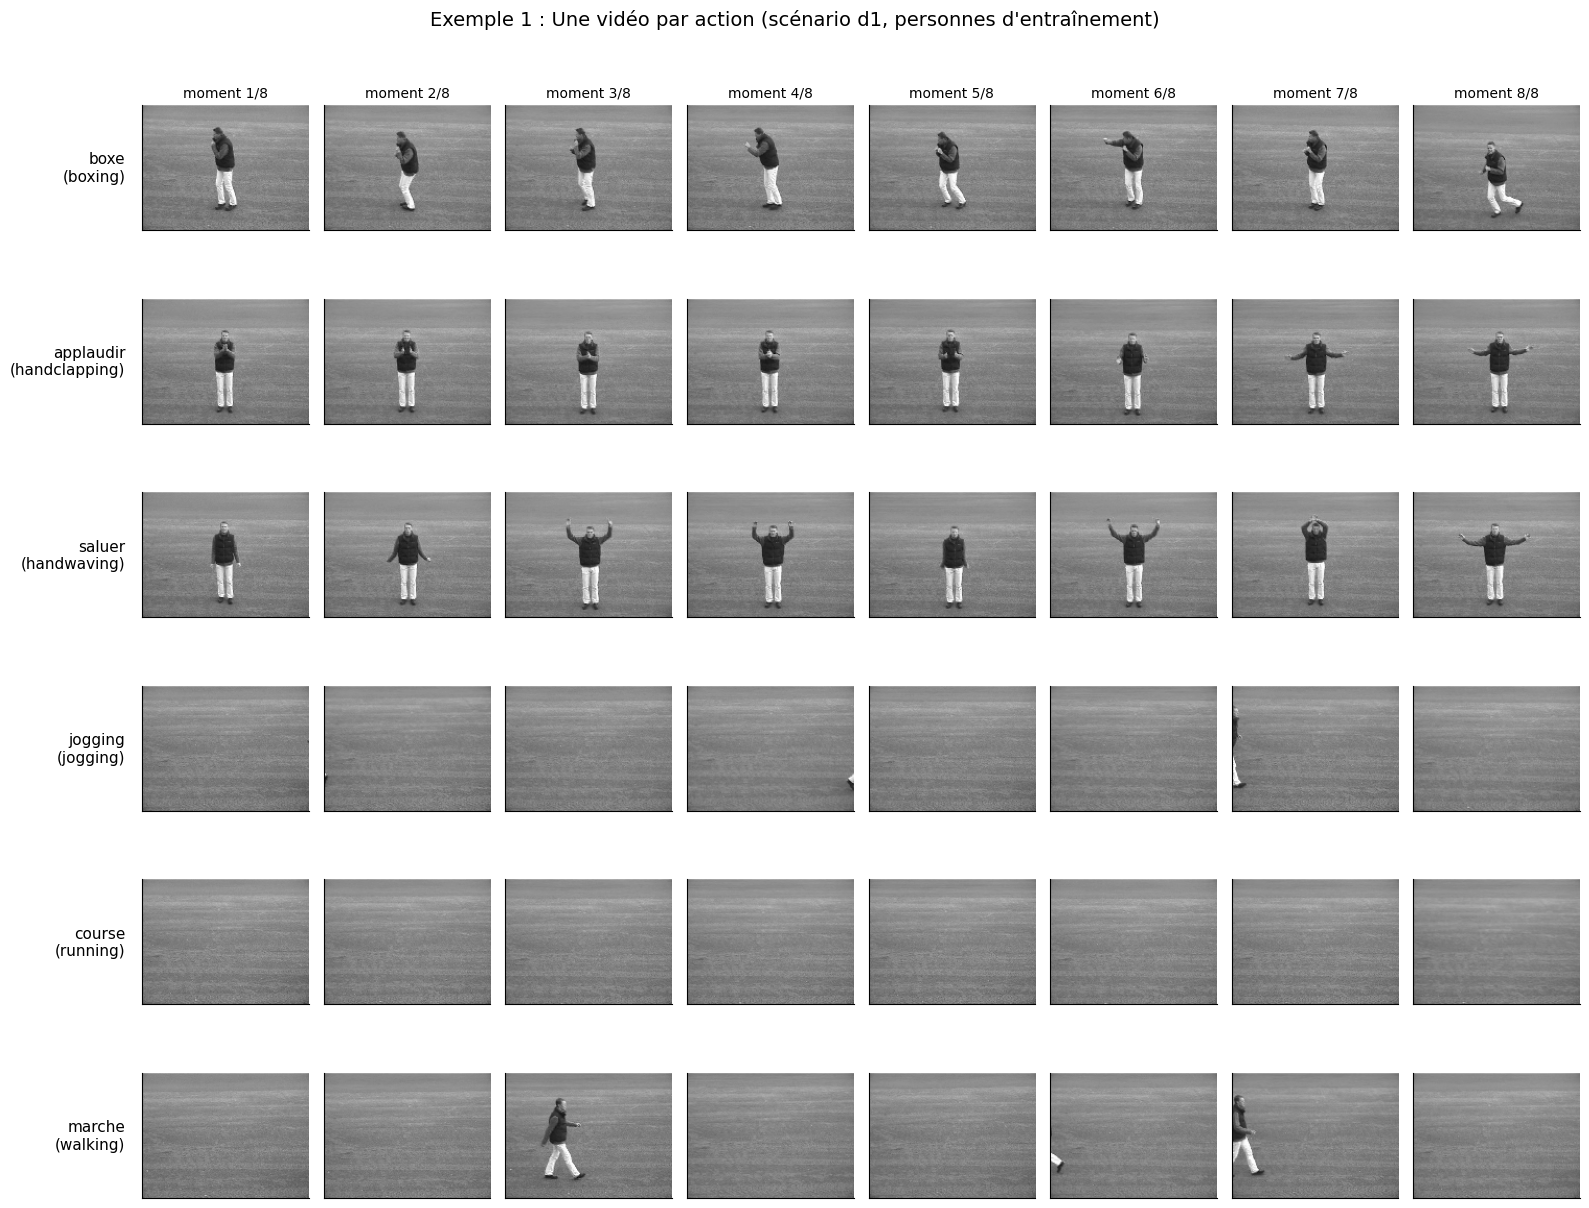

In [5]:
# Example 1: Gallery, one video per action (8 frames spread over the whole video)
def pick_video(split, class_name, scenario=None, person=None):
    """Returns (index in the split, video_file) of the first video matching the criteria, otherwise (None, None)."""
    for i, (vpath, label, pid) in enumerate(splits[split]):
        if CLASSES[label] != class_name:
            continue
        if scenario is not None and parse_scenario(vpath) != scenario:
            continue
        if person is not None and pid != person:
            continue
        return i, vpath
    return None, None

def pick_video_or_fallback(split, class_name, scenario=None, person=None):
    """Like pick_video, but relaxes the criteria if no video matches."""
    i, vpath = pick_video(split, class_name, scenario, person)
    if vpath is None:
        i, vpath = pick_video(split, class_name, scenario)
    if vpath is None:
        i, vpath = pick_video(split, class_name)
    return i, vpath

N_THUMBNAILS = 8
fig, axes = plt.subplots(len(CLASSES), N_THUMBNAILS, figsize=(16, 12.5))
for r, cls in enumerate(CLASSES):
    _, vpath = pick_video_or_fallback('train', cls, scenario='d1')
    frames = read_raw_frames(vpath, N_THUMBNAILS)
    for c in range(N_THUMBNAILS):
        ax = axes[r, c]
        ax.imshow(frames[c])
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r == 0:
            ax.set_title(f"moment {c + 1}/{N_THUMBNAILS}", fontsize=10)
        if c == 0:
            ax.set_ylabel(DISPLAY_NAMES[cls], fontsize=11, rotation=0, ha='right', va='center', labelpad=12)
plt.suptitle("Example 1: One video per action (scenario d1, training persons)", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

**What to notice:**
- **Boxing, clapping, waving**: the person stays in the same place; only the arms move. In a single frame, the arm position is already very informative (raised arms = waving).
- **Walking, jogging, running**: the person crosses the frame. In an isolated frame, the three look very similar: a side-view silhouette with legs more or less apart. What sets them apart is **the speed of displacement** from one frame to the next.
- **For locomotion actions, many frames are empty**: the person crosses the field of view, leaves it, then comes back a bit later. In the gallery, they appear in only a few thumbnails, sometimes none. This is an important property of KTH: for these actions, a good share of the frames given to the models only show the background.

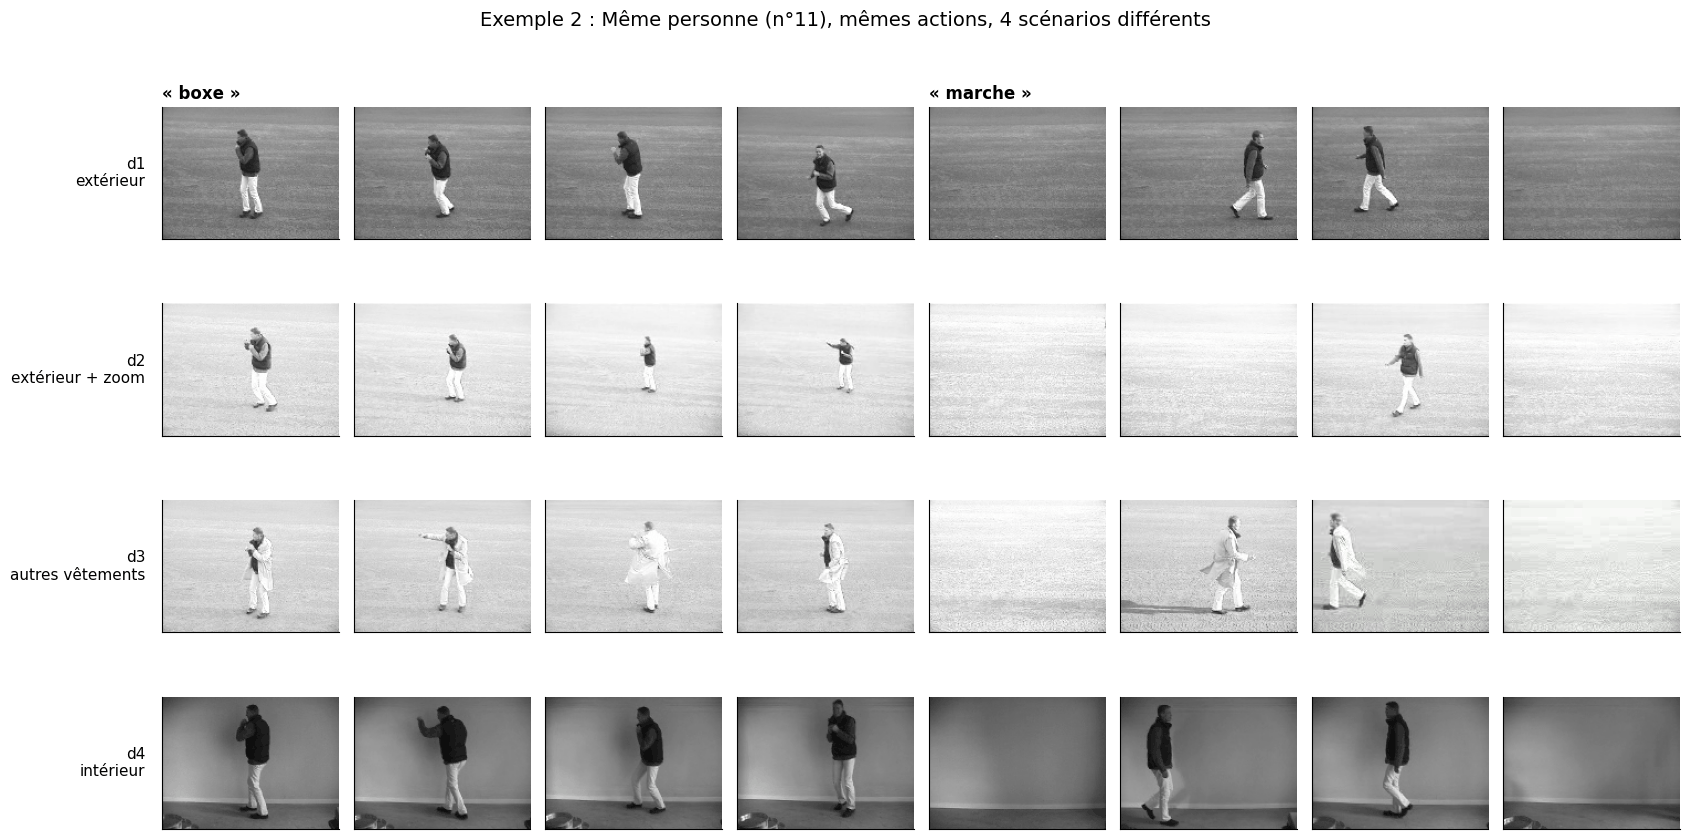

In [6]:
# Example 2: The 4 recording scenarios for the same person
actions_demo = ["boxing", "walking"]
pid_demo = sorted(train_pids)[0]
fig, axes = plt.subplots(4, 8, figsize=(17, 8.8))
for r, sc in enumerate(["d1", "d2", "d3", "d4"]):
    for k, cls in enumerate(actions_demo):
        _, vpath = pick_video_or_fallback('train', cls, scenario=sc, person=pid_demo)
        frames = read_raw_frames(vpath, 4)
        for c in range(4):
            ax = axes[r, 4 * k + c]
            ax.imshow(frames[c])
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            if r == 0 and c == 0:
                ax.set_title(f"\"{DISPLAY_NAMES[cls]}\"", fontsize=12, fontweight='bold', loc='left')
        axes[r, 0].set_ylabel(f"{sc}\n{SCENARIOS[sc]}", fontsize=11, rotation=0, ha='right', va='center', labelpad=12)
plt.suptitle(f"Example 2: Same person (#{pid_demo}), same actions, 4 different scenarios", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

**What to notice:** the same action looks very different depending on the scenario: person size ($d_2$, zoom), clothes ($d_3$), lighting and background ($d_4$, indoors). A good model must be **robust** to these variations. This is an argument in favor of the skeleton (part 5): it keeps only joint positions and ignores colors, textures and background.

### Example 3: The videos in motion
Still images miss the essential: **motion**. The animation below plays an excerpt of each action, keeping one frame out of two, i.e. ≈ 12.5 fps. The videos therefore play at roughly real speed. When the notebook is run, the cell below renders an interactive player (▶ / ⏸ buttons); the GIF below is an export of the reference run.

![The 6 KTH actions at roughly real speed](assets/kth_actions.gif)

**What to observe:** compare the displacement speed and step frequency across walking, jogging and running, then the arm rhythm across boxing, clapping and waving.

In [7]:
# Example 3: Animation of the 6 actions at (almost) real speed
def read_consecutive_frames(video_path, start=0, n=40, frame_step=2):
    """Reads n frames starting at frame `start`, keeping one frame out of `frame_step` (frame_step=2 at 25 fps => 12.5 fps)."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    frames, k = [], 0
    while len(frames) < n:
        ret, frame = cap.read()
        if not ret:
            break
        if k % frame_step == 0:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        k += 1
    cap.release()
    while len(frames) < n:
        frames.append(frames[-1].copy() if frames else np.zeros((120, 160, 3), dtype=np.uint8))
    return np.stack(frames)

def animate_clips(clips, titles, fps=12.5, n_cols=3, dpi=60):
    """Animates several clips ((n, H, W, 3) arrays) side by side; returns an HTML player embedded in the notebook."""
    n_frames = min(len(c) for c in clips)
    table_rows = math.ceil(len(clips) / n_cols)
    fig, axes = plt.subplots(table_rows, n_cols, figsize=(3.3 * n_cols, 2.8 * table_rows), dpi=dpi)
    axes = np.atleast_1d(axes).ravel()
    images = []
    for ax, clip, plot_title in zip(axes, clips, titles):
        images.append(ax.imshow(clip[0]))
        ax.set_title(plot_title, fontsize=11)
    for ax in axes:
        ax.axis('off')
    fig.tight_layout()

    def update_frame(i):
        for im, clip in zip(images, clips):
            im.set_data(clip[i])
        return images

    anim = animation.FuncAnimation(fig, update_frame, frames=n_frames, interval=1000 / fps, blit=True)
    plt.close(fig)   # avoids also showing a static image below the animation
    return HTML(anim.to_jshtml(default_mode='loop'))

animation_order = ["boxing", "handclapping", "handwaving", "walking", "jogging", "running"]
clips, titles = [], []
for cls in animation_order:
    _, vpath = pick_video_or_fallback('train', cls, scenario='d1')
    clips.append(read_consecutive_frames(vpath, start=0, n=40, frame_step=2))   # 80 original frames ≈ 3.2 s
    titles.append(DISPLAY_NAMES[cls])
display(animate_clips(clips, titles))

### Example 4: Visualizing motion: the difference between two frames
A simple way to "see" motion is to subtract two nearby frames: static pixels (the background) cancel out, and only the pixels that moved remain visible. Averaging this difference over the whole image gives a **motion energy** over time.

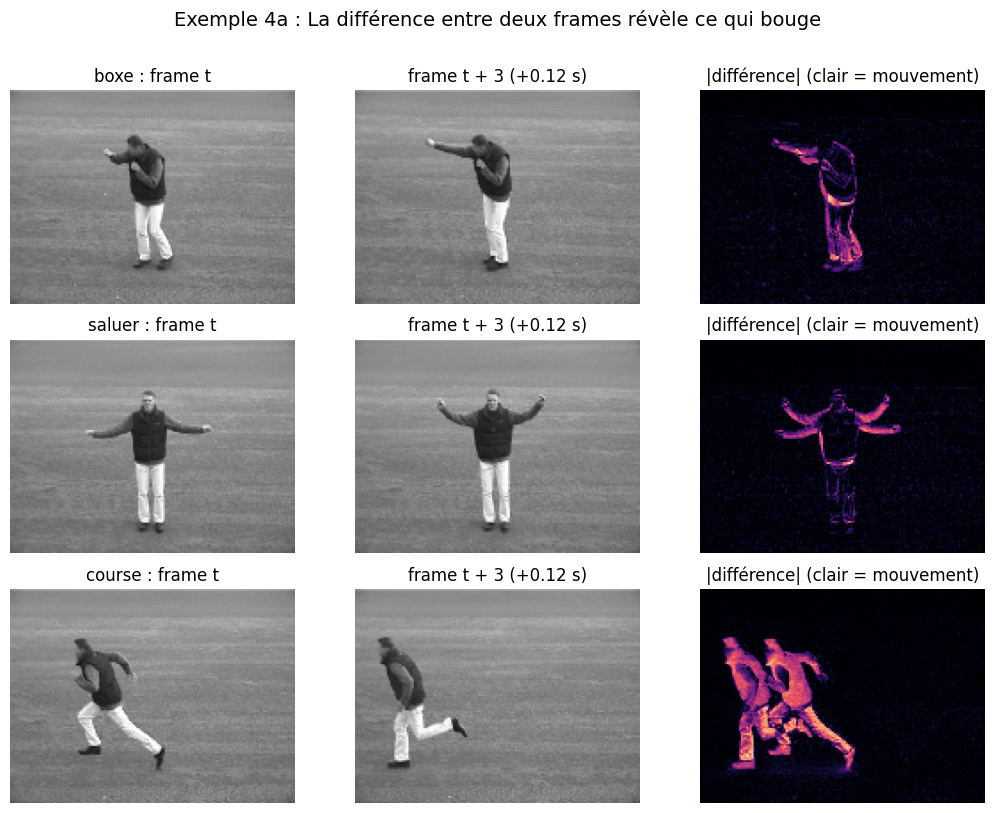

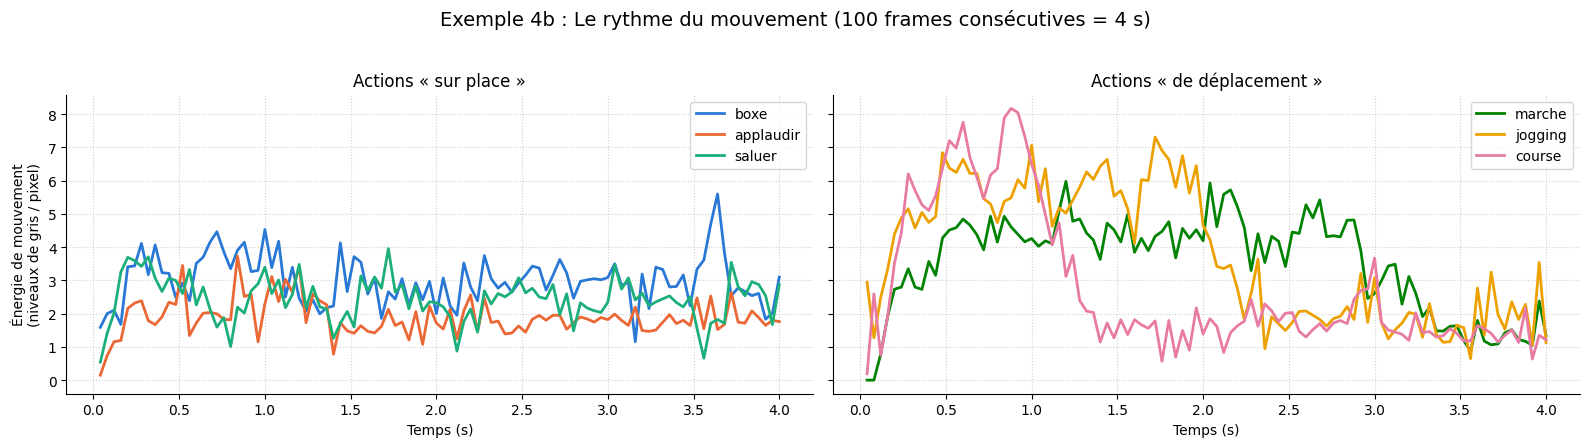

In [8]:
# Example 4: Where and at what rhythm does motion happen?
def motion_energy(frames):
    """Mean over the image of |frame(t+1) - frame(t)|: large when many pixels change."""
    gray = frames.astype(np.float32).mean(axis=3)
    return np.abs(np.diff(gray, axis=0)).mean(axis=(1, 2))

# (a) WHERE? Difference maps at the moment of maximal motion
GAP = 3   # 3 frames apart = 0.12 s
fig, axes = plt.subplots(3, 3, figsize=(10.5, 8))
for r, cls in enumerate(["boxing", "handwaving", "running"]):
    _, vpath = pick_video_or_fallback('train', cls, scenario='d1')
    fr = read_consecutive_frames(vpath, start=0, n=150, frame_step=1)
    t = int(np.argmax(motion_energy(fr)[:-GAP]))
    diff = np.abs(fr[t + GAP].astype(np.float32) - fr[t].astype(np.float32)).mean(axis=2)
    axes[r, 0].imshow(fr[t]);          axes[r, 0].set_title(f"{DISPLAY_NAMES[cls]}: frame t")
    axes[r, 1].imshow(fr[t + GAP]);  axes[r, 1].set_title(f"frame t + {GAP} (+{GAP / 25:.2f} s)")
    axes[r, 2].imshow(diff, cmap='magma'); axes[r, 2].set_title("|difference| (bright = motion)")
    for ax in axes[r]:
        ax.axis('off')
plt.suptitle("Example 4a: The difference between two frames reveals what moves", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# (b) AT WHAT RHYTHM? Motion energy over 4 seconds
fig, axes = plt.subplots(1, 2, figsize=(16, 4.3), sharey=True)
families = [("\"In-place\" actions", ["boxing", "handclapping", "handwaving"]),
            ("\"Locomotion\" actions", ["walking", "jogging", "running"])]
for ax, (plot_title, family_classes) in zip(axes, families):
    for cls in family_classes:
        _, vpath = pick_video_or_fallback('train', cls, scenario='d1')
        e = motion_energy(read_consecutive_frames(vpath, start=0, n=101, frame_step=1))
        ax.plot(np.arange(1, len(e) + 1) / 25, e, lw=2, color=CLASS_COLORS[cls], label=DISPLAY_NAMES[cls])
    ax.set_title(plot_title, fontsize=12)
    ax.set_xlabel("Time (s)")
    ax.grid(True)
    ax.legend()
axes[0].set_ylabel("Motion energy\n(gray levels / pixel)")
plt.suptitle("Example 4b: The rhythm of motion (100 consecutive frames = 4 s)", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

**Interpretation:**
- The difference map shows **where** motion happens: the arms for boxing and waving, the whole body (mostly the legs) for running.
- The energy curves show **when** there is motion:
  - **in-place actions**: the energy stays roughly constant, since the person is always in the field of view and keeps moving;
  - **locomotion actions**: the energy rises when the person crosses the frame, then drops back to the noise level once they have left. The duration of the crossing depends directly on the speed. In the example shown, it is about 1 s for running, 2 s for jogging and 3 s for walking.
- **Consequence for the models**: speed information does exist in the video, but at the scale of a **second** or less. To exploit it, a model must receive frames that are close enough in time. The next example shows that this is not the case here.

### Example 5: What the model "sees" depending on $T$
The models do not receive the whole video, but $T$ evenly spaced frames. The smaller $T$, the larger the gap between two consecutive frames.

T =  4: one frame every 5.76 s
T =  8: one frame every 2.28 s
T = 16: one frame every 1.12 s
T = 32: one frame every 0.56 s


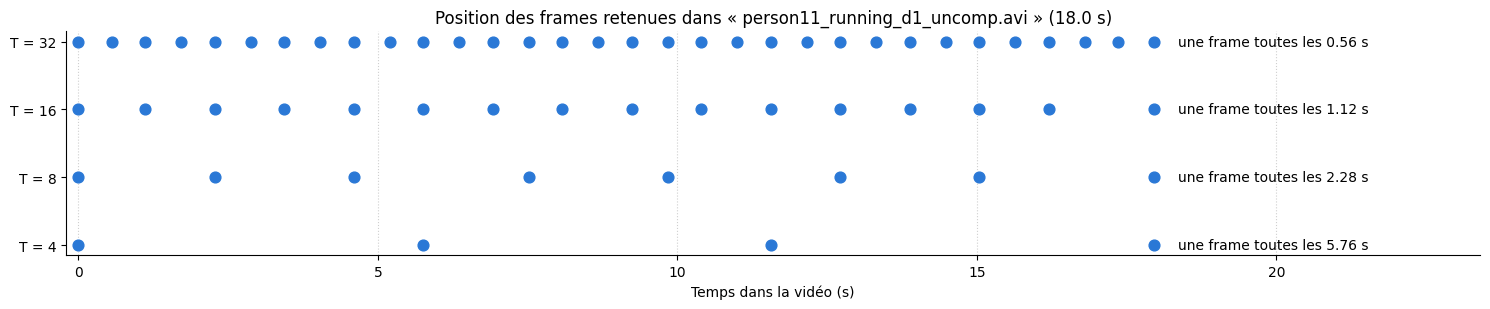

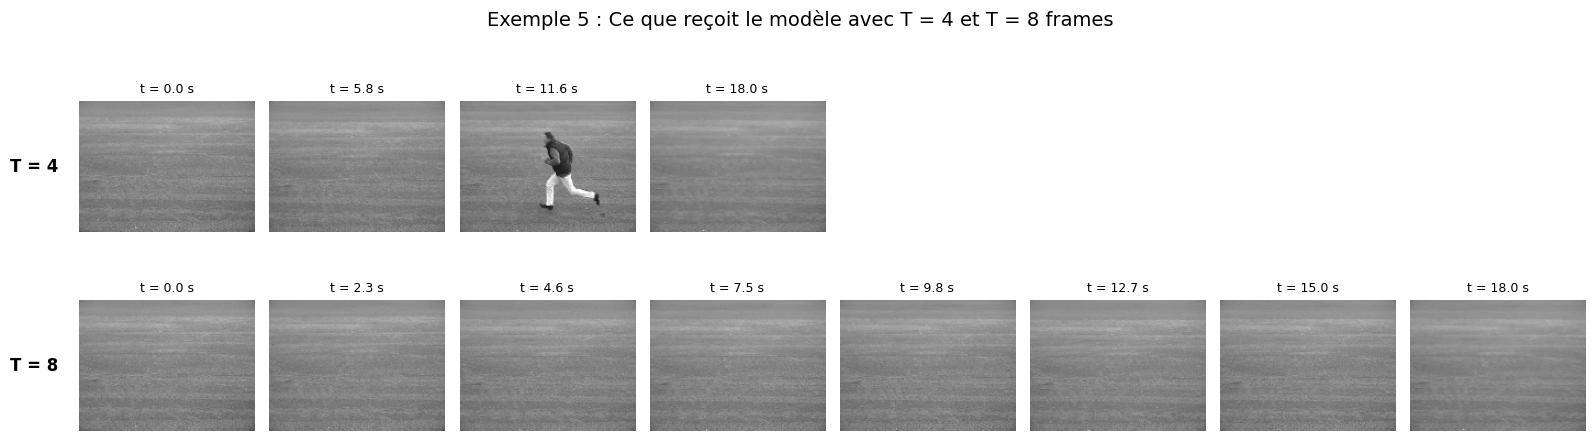

In [9]:
# Example 5: Effect of temporal sampling T ∈ {4, 8, 16, 32} on the same video
_, vpath_T = pick_video_or_fallback('train', 'running', scenario='d1')
cap = cv2.VideoCapture(vpath_T)
total_T, fps_T = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), cap.get(cv2.CAP_PROP_FPS) or 25.0
cap.release()
idx32 = np.linspace(0, total_T - 1, MAX_FRAMES, dtype=int)   # indices (in the original video) of the 32 cached frames

fig, ax = plt.subplots(figsize=(15, 3.2))
for k, T in enumerate([4, 8, 16, 32]):
    idx_T = idx32[np.linspace(0, MAX_FRAMES - 1, T, dtype=int)]
    ax.scatter(idx_T / fps_T, np.full(T, k), s=60, color=PALETTE[0], zorder=3)
    ecart = (idx_T[1] - idx_T[0]) / fps_T
    ax.text(total_T / fps_T * 1.02, k, f"one frame every {ecart:.2f} s", va='center', fontsize=10)
    print(f"T = {T:2d}: one frame every {ecart:.2f} s")
ax.set_yticks(range(4)); ax.set_yticklabels([f"T = {T}" for T in [4, 8, 16, 32]])
ax.set_xlim(-0.2, total_T / fps_T * 1.3)
ax.set_xlabel("Time in the video (s)")
ax.grid(True, axis='x')
ax.set_title(f"Position of the selected frames in \"{os.path.basename(vpath_T)}\" ({total_T / fps_T:.1f} s)", fontsize=12)
plt.tight_layout()
plt.show()

frames32 = read_raw_frames(vpath_T, MAX_FRAMES)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
for r, T in enumerate([4, 8]):
    sel = np.linspace(0, MAX_FRAMES - 1, T, dtype=int)
    for c in range(8):
        ax = axes[r, c]
        ax.axis('off')
        if c < T:
            ax.imshow(frames32[sel[c]])
            ax.set_title(f"t = {idx32[sel[c]] / fps_T:.1f} s", fontsize=9)
    axes[r, 0].text(-0.12, 0.5, f"T = {T}", transform=axes[r, 0].transAxes, ha='right', va='center',
                    fontsize=12, fontweight='bold')
plt.suptitle("Example 5: What the model receives with T = 4 and T = 8 frames", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation: temporal aliasing:**
- A step cycle lasts about one second, a punch even less. Yet in this running video, two kept frames are **≈ 1.1 s apart with $T = 16$** and ≈ 0.6 s apart with $T = 32$ (values printed above). Even with 32 frames, the model therefore only sees postures taken "at random" in the cycle, without being able to follow a step. It is the temporal equivalent of an undersampled signal.
- For locomotion actions, there is the additional problem of **empty frames**: the person crosses the field of view for only 1 to 3 s, so only a few of the 16 frames show them.
- **Major consequence for what follows**: the "temporal" models receive a sequence of spaced-out snapshots, several of which are empty. They can only exploit coarse cues: presence or absence of the person, position, posture. Keeping this in mind explains a good share of the results in parts 3, 4 and 7.

---
# Part 2: Representing each frame with a pretrained CNN (MobileNetV2)

**Idea: transfer learning.** MobileNetV2 was trained on ImageNet (1.2 million images, 1000 categories). Its layers learned to detect edges, textures and shapes, then object parts. These detectors remain useful for our videos. We therefore **reuse** the network as is (it is **frozen**: its weights are not modified) and keep only its output before the classification layer:

$$\underbrace{3 \times 224 \times 224}_{150\,528 \text{ values}} \;\xrightarrow{\text{frozen MobileNetV2}}\; \underbrace{1280 \times 7 \times 7}_{\text{feature maps}} \;\xrightarrow{\text{spatial average}}\; \underbrace{1280}_{\text{frame vector}}$$

Each video thus becomes a $32 \times 1280$ matrix: 32 frames, 1280 values per frame.

**Why freeze the network?** With only ≈ 190 training videos, retraining the ≈ 2.2 million weights of MobileNetV2's convolutional part would quickly lead to overfitting. By freezing it, we run it **only once per frame**, cache the result, then quickly train small temporal heads on top.

In [10]:
####### Frozen pretrained MobileNetV2 + feature caching #######
CACHE_DIR = os.path.join(os.getcwd(), "cached_features")
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_SUFFIX = "_synthetique" if USING_SYNTHETIC_DATA else ""
CACHE_FILE = os.path.join(CACHE_DIR, f"kth_mobilenetv2_32frames{CACHE_SUFFIX}.pt")

class MobileNetV2Extractor(nn.Module):
    """MobileNetV2 pretrained on ImageNet, fully frozen. Returns a 1280-dimensional vector per image."""
    def __init__(self):
        super().__init__()
        base = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        for param in base.parameters():
            param.requires_grad = False      # frozen: no weight will be modified
        self.features = base.features        # convolutional part (the ImageNet classification layer is dropped)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        # x: (num_frames, 3, 224, 224)
        x = self.features(x)                 # (n, 1280, 7, 7)
        x = self.pool(x)                     # (n, 1280, 1, 1): spatial average
        return torch.flatten(x, 1)           # (n, 1280)

extractor = MobileNetV2Extractor().to(device)
extractor.eval()                             # also freezes the BatchNorm statistics

def list_videos(splits):
    """Video names of each split: used to check that a cache matches the current data."""
    return {s: [os.path.basename(v) for v, _, _ in splits[s]] for s in ['train', 'val', 'test']}

def extract_and_cache_features(splits, feature_extractor, cache_path=CACHE_FILE, force=False):
    """Computes the features (32 frames x 1280) of every video and saves them to disk (.pt)."""
    if os.path.exists(cache_path) and not force:
        cache = torch.load(cache_path, map_location='cpu', weights_only=True)
        if cache.get('videos') == list_videos(splits):
            print(f"Feature cache loaded: {os.path.relpath(cache_path)}")
            for s in ['train', 'val', 'test']:
                print(f"  • {s.upper():<5}: features {tuple(cache[s]['features'].shape)}, labels {tuple(cache[s]['labels'].shape)}")
            return cache
        print("The cache does not match the current videos: recomputing.")

    print(f"Extracting features with frozen MobileNetV2 on {device}...")
    cache = {'videos': list_videos(splits)}
    with torch.no_grad():
        for split_name in ['train', 'val', 'test']:
            all_feats, all_labels = [], []
            start = time.time()
            for vpath, label, _ in tqdm(splits[split_name], desc=f"Extraction {split_name}"):
                clip = extract_uniform_frames(vpath, MAX_FRAMES).to(device)   # (32, 3, 224, 224)
                all_feats.append(feature_extractor(clip).cpu())                         # (32, 1280)
                all_labels.append(label)
            cache[split_name] = {'features': torch.stack(all_feats, dim=0),       # (N, 32, 1280)
                                 'labels': torch.tensor(all_labels, dtype=torch.long)}
            print(f"  {split_name}: {time.time() - start:.1f} s | shape {tuple(cache[split_name]['features'].shape)}")

    torch.save(cache, cache_path)
    print(f"Cache saved: {os.path.relpath(cache_path)}")
    return cache

dataset_features = extract_and_cache_features(splits, extractor)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 61.6MB/s]


Extracting features with frozen MobileNetV2 on cuda...


Extraction train:   0%|          | 0/191 [00:00<?, ?it/s]

  train: 31.9 s | shape (191, 32, 1280)


Extraction val:   0%|          | 0/144 [00:00<?, ?it/s]

  val: 21.4 s | shape (144, 32, 1280)


Extraction test:   0%|          | 0/264 [00:00<?, ?it/s]

  test: 42.6 s | shape (264, 32, 1280)
Cache saved: cached_features/kth_mobilenetv2_32frames.pt


### Analysis: feature extraction (requirement 1)
- **Frozen parameters**: `param.requires_grad = False` on every layer, and `extractor.eval()` also freezes the BatchNorm statistics.
- **Compression**: each frame goes from $3 \times 224 \times 224 = 150\,528$ values to a $1280$-value descriptor, about 118 times less. This vector describes *what is in* the image (shapes, textures, silhouette).
- **On-disk cache**: about 160 KB per video ($32 \times 1280$ real numbers), ≈ 100 MB for all of KTH. The cache is automatically **recomputed** if the list of videos changes (for example when switching from the synthetic set to the real KTH).
- **Important limitation**: MobileNetV2 processes each frame **independently**. It does not "see" motion. All temporal information has to be extracted by the heads of part 3.

In [11]:
####### Temporal subsampling for the ablation (T ∈ {4, 8, 16, 32}) #######
IDX_16 = np.linspace(0, MAX_FRAMES - 1, 16, dtype=int)   # the 16 frames used by default

def make_loaders(feature_data, field='features', seq_len=16, batch_size=32):
    """
    Keeps `seq_len` evenly spaced frames out of the 32 cached ones and returns one DataLoader per split.
    `field` = 'features' (CNN) or 'skeletons' (skeletons, part 5).
    """
    assert seq_len in [4, 8, 16, 32], "Possible sequence lengths: 4, 8, 16 or 32"
    indices = np.linspace(0, MAX_FRAMES - 1, seq_len, dtype=int)
    loaders = {}
    for split_name in ['train', 'val', 'test']:
        X = feature_data[split_name][field][:, indices]          # (N, seq_len, ...)
        y = feature_data[split_name]['labels']
        loaders[split_name] = DataLoader(TensorDataset(X, y), batch_size=batch_size,
                                         shuffle=(split_name == 'train'), num_workers=0)
    return loaders

for T in [4, 8, 16, 32]:
    print(f"T = {T:2d} -> indices kept out of the 32 frames: {np.linspace(0, MAX_FRAMES - 1, T, dtype=int).tolist()}")

loaders_16 = make_loaders(dataset_features, 'features', seq_len=16, batch_size=32)
x_batch, y_batch = next(iter(loaders_16['train']))
print(f"\nBatch check (T = 16):")
print(f"  • Features (batch, T, D) : {tuple(x_batch.shape)}")
print(f"  • Labels (batch)         : {tuple(y_batch.shape)}")

T =  4 -> indices kept out of the 32 frames: [0, 10, 20, 31]
T =  8 -> indices kept out of the 32 frames: [0, 4, 8, 13, 17, 22, 26, 31]
T = 16 -> indices kept out of the 32 frames: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 31]
T = 32 -> indices kept out of the 32 frames: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

Batch check (T = 16):
  • Features (batch, T, D) : (32, 16, 1280)
  • Labels (batch)         : (32,)


### Analysis: temporal subsampling
- `make_loaders` picks $T$ evenly spaced indices out of the 32 cached frames. For $T = 4$, for example, these are frames 0, 10, 20 and 31.
- The same indices are used for every video and every model: the comparison stays fair, and no data is recomputed.
- A batch has shape $(B, T, D) = (32, 16, 1280)$: 32 videos, 16 frames per video, 1280 features per frame.

### Visualizing the CNN features: 2D projection (PCA)
Each video is summarized by the mean of its 32 vectors (1280 dimensions), then projected to 2D with **principal component analysis** (PCA). PCA keeps the two directions of largest variance. If the actions form well-separated clouds, even a simple classifier will succeed. If they overlap, temporal information will be needed.

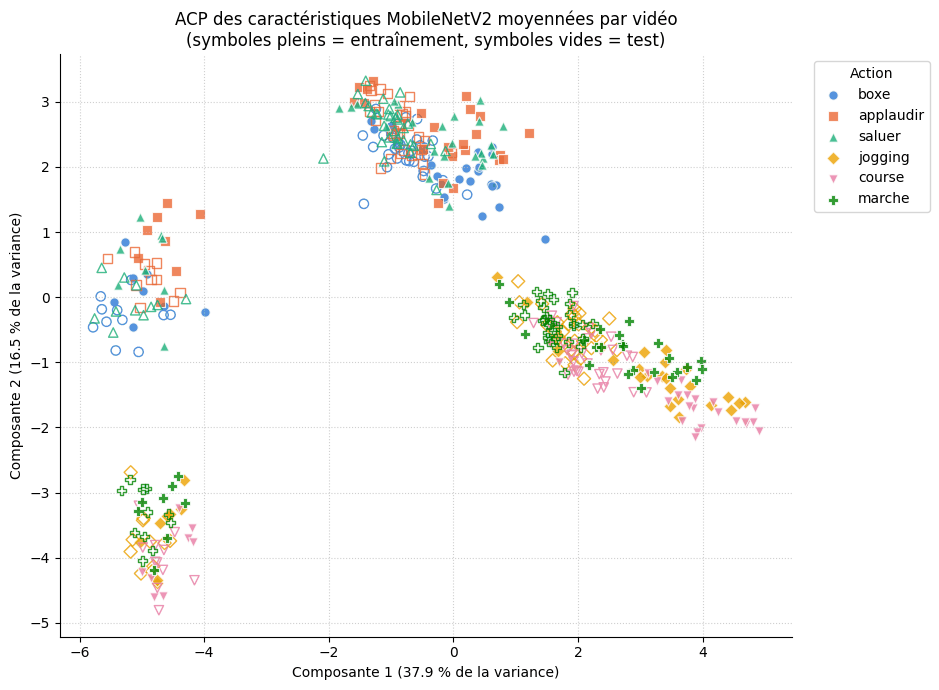

In [12]:
####### PCA of the MobileNetV2 features (one video = one point) #######
X_tr = dataset_features['train']['features'].mean(dim=1).numpy()
y_tr = dataset_features['train']['labels'].numpy()
X_te = dataset_features['test']['features'].mean(dim=1).numpy()
y_te = dataset_features['test']['labels'].numpy()

pca = PCA(n_components=2, random_state=42).fit(X_tr)
Z_tr, Z_te = pca.transform(X_tr), pca.transform(X_te)

MARKERS = ['o', 's', '^', 'D', 'v', 'P']   # shape + color: each action stays identifiable without color
fig, ax = plt.subplots(figsize=(9.5, 7))
for c, cls in enumerate(CLASSES):
    ax.scatter(*Z_tr[y_tr == c].T, color=CLASS_COLORS[cls], marker=MARKERS[c], s=45, alpha=0.8,
               edgecolor='white', linewidth=0.8, label=DISPLAY_NAMES[cls])
    ax.scatter(*Z_te[y_te == c].T, facecolor='none', edgecolor=CLASS_COLORS[cls], marker=MARKERS[c], s=45, alpha=0.8)
ax.set_xlabel(f"Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f} % of variance)")
ax.set_ylabel(f"Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f} % of variance)")
ax.set_title("PCA of MobileNetV2 features averaged per video\n(filled markers = training, hollow markers = test)", fontsize=12)
ax.grid(True)
ax.legend(title="Action", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation (reference run):**
- We see **four clouds**. The two clouds on the left would correspond to scenario $d_4$ (indoors) and the two on the right to the outdoor scenarios ($d_1$, $d_2$, $d_3$): this is a hypothesis, since the figure is not colored by scenario. **The first component (≈ 38 % of the variance) might therefore encode the background first rather than the action (unverified hypothesis).** This would be consistent with pretrained CNNs describing the whole image, most of which is background.
- The second component separates the two **families**: "in-place" actions (top) and "locomotion" actions (bottom). Even a simple classifier will therefore easily tell the families apart.
- Within a family, the actions mix: **walking, jogging and running fully overlap**, and boxing / clapping / waving partly do. This is where the errors will happen.

Caution: PCA shows only 2 dimensions out of 1280. Two clouds that overlap in 2D may very well be separable in higher dimension.

**Checking the "background" hypothesis.** The next figure uses exactly the same projection, but colors each video by **scenario** instead of action. If the $d_4$ (indoor) videos alone form the clouds on the left, the first component does encode the background first.

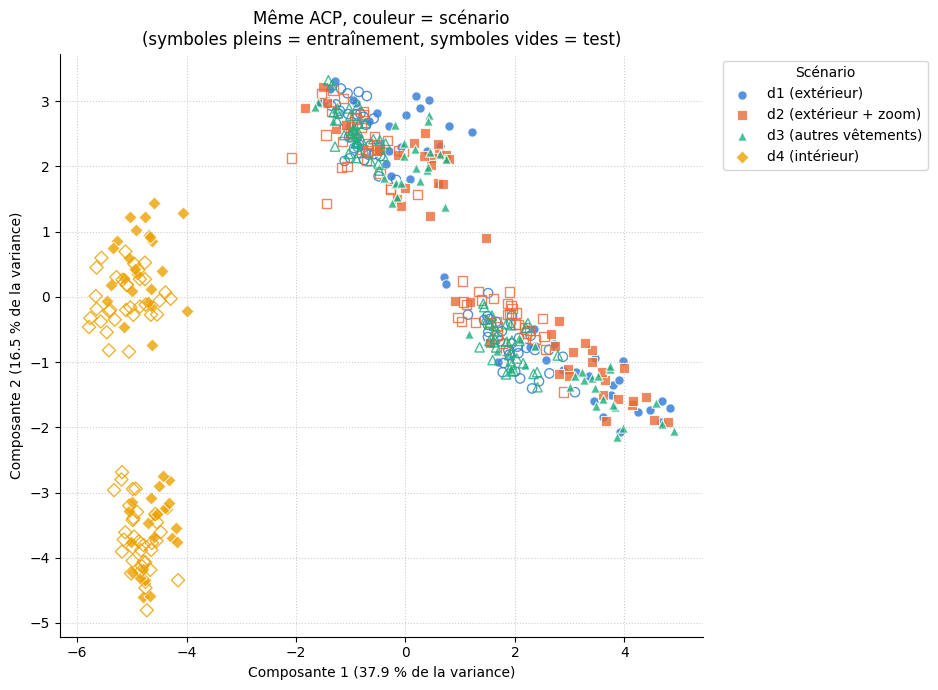

d4 videos located on the left side of component 1: {'train': '100 %', 'test': '100 %'}


In [13]:
####### PCA colored by scenario: does the CNN encode the background first? #######
sc_tr = np.array([parse_scenario(v) for v, _, _ in splits['train']])
sc_te = np.array([parse_scenario(v) for v, _, _ in splits['test']])
fig, ax = plt.subplots(figsize=(9.5, 7))
for k, sc in enumerate(["d1", "d2", "d3", "d4"]):
    ax.scatter(*Z_tr[sc_tr == sc].T, color=PALETTE[k], marker=MARKERS[k], s=45, alpha=0.8,
               edgecolor='white', linewidth=0.8, label=f"{sc} ({SCENARIOS[sc]})")
    ax.scatter(*Z_te[sc_te == sc].T, facecolor='none', edgecolor=PALETTE[k], marker=MARKERS[k], s=45, alpha=0.8)
ax.set_xlabel(f"Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f} % of variance)")
ax.set_ylabel(f"Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f} % of variance)")
ax.set_title("Same PCA, color = scenario\n(filled markers = training, hollow markers = test)", fontsize=12)
ax.grid(True)
ax.legend(title="Scenario", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

part_d4 = {name: float(np.mean(Z[sc == "d4", 0] < np.median(Z[:, 0]))) for name, Z, sc in [("train", Z_tr, sc_tr), ("test", Z_te, sc_te)]}
print("d4 videos located on the left side of component 1:", {k: f"{v * 100:.0f} %" for k, v in part_d4.items()})

**Reading:** compare the two figures. If the left / right separation matches the scenarios ($d_4$ on one side, $d_1$–$d_3$ on the other) rather than the actions, the background dominates the first component. In our other runs (features from part 10, official split), this was the case: indoor videos formed separate clouds for both action families.

---
# Part 3: Three ways of modeling time on CNN features

All three heads receive the same input: a sequence $x_1, \dots, x_T$ of 1280-dimensional vectors. Each starts with a linear **projection** to 256 dimensions (`proj`), then aggregates time differently.

#### 1. Temporal mean ("no time" baseline)
$$h = \frac{1}{T} \sum_{t=1}^{T} \text{proj}(x_t)$$
The mean does **not depend on frame order**: shuffling the video, or playing it backwards, leaves the prediction unchanged. This model therefore measures what can be achieved **with appearance alone**.

#### 2. LSTM (recurrence)
The LSTM reads the frames **one by one**, like reading a sentence word by word, and updates an internal memory:
$$(h_t, c_t) = \text{LSTM}(x_t,\, h_{t-1},\, c_{t-1})$$
**Gates** (forget, input and output) decide at each step what to forget, what to add to the memory $c_t$ and what to pass on. Here, we then average the outputs $h_1, \dots, h_T$ (instead of keeping only $h_T$) so that every time step contributes to the decision.
*Limitation*: information from frame 1 must go through $T - 1$ steps before interacting with frame $T$, and it can fade along the way.

#### 3. Transformer (self-attention)
Each frame computes a **query** $Q$, a **key** $K$ and a **value** $V$, then "looks at" **all the other frames in a single step**:
$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$
- **Learned positional embeddings**: attention alone ignores order, exactly like the mean. We therefore add to each frame a vector that depends on its position $t$ and is learned by the network. Without them, the Transformer could not tell a video from its reverse.
- **[CLS] token**: an extra learned vector placed at the start of the sequence. It gathers information from all frames through attention, and its output is used to classify the video (same principle as BERT or ViT).
- **Multi-head** (`nhead=4`): 4 attentions computed in parallel, which can specialize (for example one on neighboring frames, another on distant frames).

In [14]:
####### Requirement 2: Three temporal heads on CNN features #######
MODEL_NAMES = ["Temporal mean", "CNN + LSTM", "CNN + Transformer", "GNN + LSTM", "GNN + Transformer"]
MODEL_COLORS = dict(zip(MODEL_NAMES, PALETTE))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Head 1: temporal mean
class MeanPoolClassifier(nn.Module):
    def __init__(self, in_features=1280, hidden_dim=256, num_classes=6, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_features, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, num_classes))

    def forward(self, x):                    # x : (B, T, 1280)
        x = self.proj(x)                     # (B, T, 256)
        pooled = torch.mean(x, dim=1)        # mean over time -> (B, 256): frame order is lost
        return self.classifier(pooled)       # logits (B, 6)

# Head 2: CNN + LSTM
class CNNLSTMClassifier(nn.Module):
    def __init__(self, in_features=1280, hidden_dim=256, num_layers=2, num_classes=6, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_features, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.lstm = nn.LSTM(input_size=hidden_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, num_classes))

    def forward(self, x):                    # x : (B, T, 1280)
        x = self.proj(x)                     # (B, T, 256)
        lstm_out, _ = self.lstm(x)           # (B, T, 256): one hidden state per time step, computed from t = 1 to t = T
        pooled = torch.mean(lstm_out, dim=1) # mean of the hidden states
        return self.classifier(pooled)

# Head 3: CNN + Transformer with LEARNED positional embeddings
class CNNTransformerClassifier(nn.Module):
    def __init__(self, in_features=1280, d_model=256, nhead=4, num_layers=2,
                 dim_feedforward=512, num_classes=6, max_len=64, dropout=0.2):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_features, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        # LEARNED positional embeddings (requirement 2): one vector per position, adjusted during training
        self.pos_embeddings = nn.Parameter(torch.randn(1, max_len + 1, d_model) * 0.02)
        self.dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                                   dropout=dropout, batch_first=True, activation='gelu')
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.classifier = nn.Sequential(nn.Linear(d_model, 128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, num_classes))

    def sequence_frames(self, x):
        """Frame vectors right before the Transformer: (B, T, 1280) -> (B, T, d_model)."""
        return self.proj(x)

    def forward(self, x):
        B, T, _ = x.shape
        h = self.sequence_frames(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        h = torch.cat((cls_tokens, h), dim=1)                # (B, T + 1, d_model): [CLS] at position 0
        h = h + self.pos_embeddings[:, :T + 1, :]            # "tag" each frame with its position
        out = self.transformer_encoder(self.dropout(h))
        return self.classifier(out[:, 0, :])                 # classify from the [CLS] token output

p_mean = count_parameters(MeanPoolClassifier())
p_lstm = count_parameters(CNNLSTMClassifier())
p_tf   = count_parameters(CNNTransformerClassifier())
print("NUMBER OF TRAINABLE PARAMETERS (CNN heads):")
print(f"  1. Temporal mean              : {p_mean:>10,d}")
print(f"  2. CNN + LSTM                : {p_lstm:>10,d}")
print(f"  3. CNN + Transformer (learned PE): {p_tf:>10,d}")

NUMBER OF TRAINABLE PARAMETERS (CNN heads):
  1. Temporal mean        :    362,118
  2. CNN + LSTM                :  1,414,790
  3. CNN + Transformer (learned PE):  1,433,222


### Architecture comparison: number of parameters
| Head | Trainable parameters | Where do they come from? |
|---|---|---|
| Temporal mean | ≈ 362 k | mostly the $1280 \to 256$ projection (≈ 328 k) |
| CNN + LSTM | ≈ 1.41 M | projection + 2 LSTM layers (≈ 526 k each: 4 gates, each with its own weights) |
| CNN + Transformer | ≈ 1.43 M | projection + 2 encoder layers (≈ 527 k each: attention $4 \times 256^2$ + MLP $2 \times 256 \times 512$) |

The LSTM and the Transformer have a **comparable size**. The comparison between them is therefore really about *how time is modeled*, not about model capacity. The exact numbers are printed by the cell above.

In [15]:
####### Training and evaluation engine (identical for all models) #######
NUM_EPOCHS = 35             # main training
NUM_EPOCHS_ABLATION = 30    # ablation over T (part 4)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # gradient clipping
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += x_batch.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate_model(model, loader):
    """Mean loss and accuracy over a loader (evaluation mode: no dropout)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = model(x_batch)
        total_loss += criterion(logits, y_batch).item() * x_batch.size(0)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += x_batch.size(0)
    return total_loss / total, correct / total

def train_model(model, name, loaders, num_epochs=NUM_EPOCHS, lr=1e-3, weight_decay=1e-4, verbose=True):
    """Trains the model and, at the end, reloads the weights of the best epoch (according to VALIDATION)."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val, best_weights = -1.0, None
    start = time.time()
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, loaders['train'], optimizer)
        val_loss, val_acc = evaluate_model(model, loaders['val'])
        scheduler.step()
        for field, value in zip(history, [tr_loss, tr_acc, val_loss, val_acc]):
            history[field].append(value)
        if val_acc > best_val:
            best_val = val_acc
            best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if verbose and (epoch % 10 == 0 or epoch == num_epochs):
            print(f"[{name:<18}] Epoch {epoch:02d}/{num_epochs} | Train acc: {tr_acc * 100:5.1f} % | Val acc: {val_acc * 100:5.1f} %")
    model.load_state_dict(best_weights)
    if verbose:
        print(f"[{name:<18}] Best validation accuracy: {best_val * 100:.1f} % ({time.time() - start:.1f} s)")
    return history, time.time() - start

@torch.no_grad()
def predict(model, loader):
    """Probabilities (N, 6) and true labels (N,) over a whole loader, in loader order."""
    model.eval()
    probas, true_labels = [], []
    for x_batch, y_batch in loader:
        probas.append(F.softmax(model(x_batch.to(device)), dim=1).cpu())
        true_labels.append(y_batch)
    return torch.cat(probas).numpy(), torch.cat(true_labels).numpy()

def test_report(model, loader):
    """Accuracy, macro F1, loss, predictions and probabilities of a model on a split (in split order)."""
    probas, y = predict(model, loader)
    preds = probas.argmax(axis=1)
    mean_loss = float(-np.log(probas[np.arange(len(y)), y] + 1e-12).mean())
    return {'acc': accuracy_score(y, preds), 'f1': f1_score(y, preds, average='macro'),
            'mean_loss': mean_loss, 'preds': preds, 'targets': y, 'probas': probas}

def plot_curves(histories, plot_title):
    """Loss and accuracy curves (training as solid lines, validation as dashed lines)."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    for name, h in histories.items():
        line_color, epochs = MODEL_COLORS[name], np.arange(1, len(h['train_loss']) + 1)
        axes[0].plot(epochs, h['train_loss'], '-', color=line_color, lw=2, label=f"{name}")
        axes[0].plot(epochs, h['val_loss'], '--', color=line_color, lw=2)
        axes[1].plot(epochs, np.array(h['train_acc']) * 100, '-', color=line_color, lw=2, label=f"{name}")
        axes[1].plot(epochs, np.array(h['val_acc']) * 100, '--', color=line_color, lw=2)
    axes[0].set_title("Loss (cross-entropy)"); axes[0].set_xlabel("Epoch")
    axes[1].set_title("Accuracy (%)");         axes[1].set_xlabel("Epoch")
    axes[1].legend(loc='lower right')
    for ax in axes:
        ax.grid(True)
    plt.suptitle(plot_title + "\n(solid = training, dashed = validation)", fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

### Analysis: a fair training protocol for all models
- **Loss function**: cross-entropy (`CrossEntropyLoss`). It penalizes the model when the probability given to the correct class is low: loss $= -\log p_{\text{true class}}$.
- **Optimizer**: AdamW ($\text{lr} = 10^{-3}$, *weight decay* $= 10^{-4}$), with a learning rate following a cosine decay down to $10^{-5}$. Large steps at first, then small steps to refine.
- **Gradient clipping** (`clip_grad_norm_ = 1.0`): avoids overly abrupt updates, a classic risk with LSTMs.
- **Best checkpoint**: at each epoch, we measure **validation** accuracy and keep the weights of the best epoch. This is a form of early stopping, which limits overfitting. The test set **never** takes part in this choice.
- **Same hyperparameters for all**: this is what makes the comparison fair. The flip side is that no model is optimally tuned. Transformers, for example, often benefit from a learning-rate *warm-up* phase.

In [16]:
####### Training the three CNN heads at the reference length T = 16 #######
print("TRAINING THE THREE CNN HEADS ON T = 16 FRAMES")
histories_cnn = {}

seed_everything(42)
model_mean = MeanPoolClassifier().to(device)
histories_cnn["Temporal mean"], _ = train_model(model_mean, "Temporal mean", loaders_16)

seed_everything(42)
model_lstm = CNNLSTMClassifier().to(device)
histories_cnn["CNN + LSTM"], _ = train_model(model_lstm, "CNN + LSTM", loaders_16)

seed_everything(42)
model_tf = CNNTransformerClassifier().to(device)
histories_cnn["CNN + Transformer"], _ = train_model(model_tf, "CNN + Transformer", loaders_16)

TRAINING THE THREE CNN HEADS ON T = 16 FRAMES
[Temporal mean] Epoch 10/35 | Train acc:  89.5 % | Val acc:  78.5 %
[Temporal mean] Epoch 20/35 | Train acc:  98.4 % | Val acc:  82.6 %
[Temporal mean] Epoch 30/35 | Train acc: 100.0 % | Val acc:  84.7 %
[Temporal mean] Epoch 35/35 | Train acc:  99.5 % | Val acc:  86.1 %
[Temporal mean] Best validation accuracy: 86.1 % (1.7 s)
[CNN + LSTM        ] Epoch 10/35 | Train acc:  68.1 % | Val acc:  61.8 %
[CNN + LSTM        ] Epoch 20/35 | Train acc:  80.1 % | Val acc:  61.1 %
[CNN + LSTM        ] Epoch 30/35 | Train acc:  86.4 % | Val acc:  59.7 %
[CNN + LSTM        ] Epoch 35/35 | Train acc:  84.3 % | Val acc:  63.2 %
[CNN + LSTM        ] Best validation accuracy: 67.4 % (2.0 s)
[CNN + Transformer ] Epoch 10/35 | Train acc:  85.9 % | Val acc:  77.1 %
[CNN + Transformer ] Epoch 20/35 | Train acc:  99.0 % | Val acc:  81.2 %
[CNN + Transformer ] Epoch 30/35 | Train acc: 100.0 % | Val acc:  87.5 %
[CNN + Transformer ] Epoch 35/35 | Train acc: 100.0 

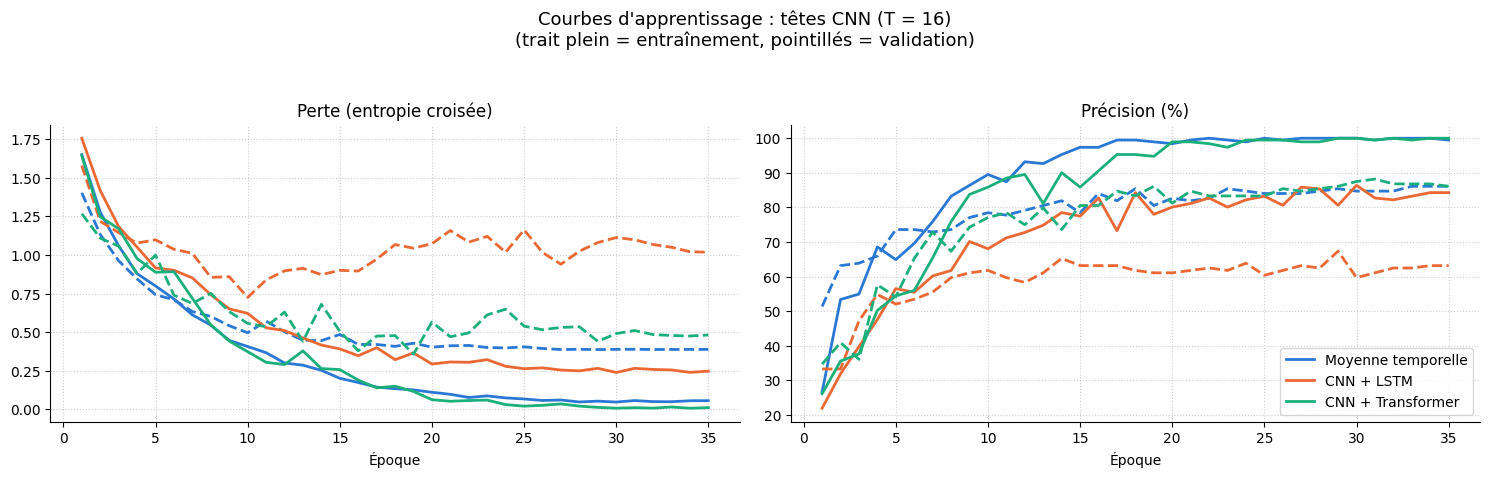

In [17]:
####### Learning curves of the CNN heads #######
plot_curves(histories_cnn, "Learning curves: CNN heads (T = 16)")

### How to read the learning curves?
- **Training loss goes down but validation loss goes up**: this is **overfitting**; the model memorizes the training people instead of learning the actions.
- **Validation accuracy moves "in steps"**: this is normal with a small validation set, where a single video is worth about 0.7 point.
- **A long plateau at the start** (common for the Transformer): attention sometimes needs several epochs before "kicking in". A *warm-up* or a lower learning rate can help.
- Thanks to the **best checkpoint**, the epoch at the top of the validation curve is kept, not the last one.

**In the reference run**, the temporal mean and the Transformer reach ≈ 100 % training accuracy (99.5 % and 100 %), with a best validation accuracy of 86.1 % and 88.2 %. The LSTM only reaches ≈ 84 % in training and 67.4 % at best in validation (≈ 63 % at the last epoch). Overfitting is clear in all three cases, as expected with 191 training videos; the gap between training and validation is largest for the LSTM, whose validation loss starts rising from around epoch 10.

In [18]:
####### Test evaluation (never-seen persons, T = 16) #######
def print_results(results):
    print("=" * 72)
    print(f"{'Model':<22} | {'Test accuracy':>14} | {'Macro F1':>9} | {'Test loss':>10}")
    print("-" * 72)
    for name, r in results.items():
        print(f"{name:<22} | {r['acc'] * 100:>13.2f}% | {r['f1']:>9.4f} | {r['mean_loss']:>10.4f}")
    print("=" * 72)

results = {}   # filled progressively: one results dictionary per model, all at T = 16
results["Temporal mean"] = test_report(model_mean, loaders_16['test'])
results["CNN + LSTM"]         = test_report(model_lstm, loaders_16['test'])
results["CNN + Transformer"]  = test_report(model_tf,   loaders_16['test'])

print("TEST EVALUATION (never-seen persons, T = 16):")
print_results(results)

TEST EVALUATION (never-seen persons, T = 16):
Model                  |  Test accuracy |  Macro F1 |  Test loss
------------------------------------------------------------------------
Temporal mean     |         78.79% |    0.7917 |     0.5982
CNN + LSTM             |         65.15% |    0.6408 |     0.9624
CNN + Transformer      |         80.68% |    0.8074 |     0.9715


### Analysis: results on never-seen people ($T = 16$)
- **Accuracy**: fraction of correctly classified videos.
- **Macro F1**: the F1 score (harmonic mean of precision and recall) is computed **for each action**, then averaged without weighting. A poorly recognized action therefore lowers the score, even if it is rare. On KTH, the classes are balanced, so accuracy and macro F1 are close.
- **Test loss**: a low loss together with good accuracy means the model is both right **and** confident.

**What to look at?** The gap between the temporal mean and the two sequential models measures **the contribution of temporal information**:
- if it is small, appearance is almost enough (the "in-place" and "locomotion" families separate easily);
- if it is large, the order and rhythm of the frames matter.

**What the reference run shows:** the Transformer reaches 80.7 % and the temporal mean 78.8 %, a 1.9-point gap (about 5 videos out of 264, not significant with a single seed); the LSTM is clearly behind (65.2 %). The contribution of time is therefore small. Three reasons explain it:
1. frames are more than one second apart and often empty (example 5 of part 1): there is very little fine-grained dynamics to exploit;
2. with 191 videos, the sequential models, about four times larger than the mean, overfit (especially the LSTM: ≈ 84 % in training vs ≈ 63 % in validation at the last epoch, curves above);
3. the mean does not depend on frame order. When order carries little information, this "flaw" becomes a **strength**: the model cannot learn spurious temporal patterns.

The examples in part 7 show *on which videos* the models differ, and whether the sequential models really use frame order.

> **Update with 10 seeds (part 9).** At $T = 16$: Transformer 79.6 ± 1.4 %, temporal mean 78.8 ± 0.8 %, LSTM 68.6 ± 4.0 %. The Transformer − mean gap (+0.8 point, 95 % CI [−2.8; +4.7]) remains non-significant. The LSTM's lag is confirmed but reduced from 15.5 to **+11.0 points [+7.0; +15.2]**: the single-seed value (65.2 %) lies in the lower part of the LSTM's spread.

---
# Part 4: Ablation study: how many frames are needed?

We retrain the three CNN heads with $T \in \{4, 8, 16, 32\}$ frames (30 epochs each), all else being equal. Two questions: from how many frames does the model "understand" the action? Do the LSTM and the Transformer react differently to longer sequences?

REQUIREMENT 4: SEQUENCE LENGTH ABLATION
T = 04 | Temporal mean : 66.29 % | CNN + LSTM : 54.92 % | CNN + Transformer : 66.29 %
T = 08 | Temporal mean : 67.05 % | CNN + LSTM : 55.30 % | CNN + Transformer : 70.83 %
T = 16 | Temporal mean : 78.03 % | CNN + LSTM : 65.53 % | CNN + Transformer : 78.79 %
T = 32 | Temporal mean : 79.55 % | CNN + LSTM : 75.38 % | CNN + Transformer : 81.82 %


Model,Temporal mean,CNN + LSTM,CNN + Transformer
T,,,
4,66.29,54.92,66.29
8,67.05,55.30,70.83
16,78.03,65.53,78.79
32,79.55,75.38,81.82


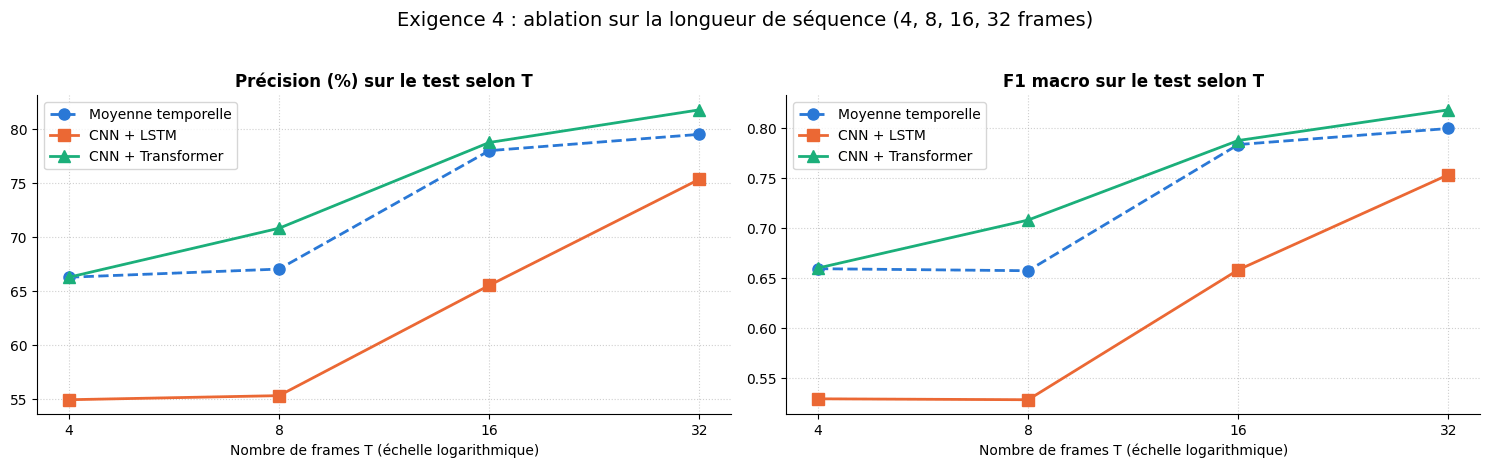

In [19]:
####### Requirement 4: Ablation over sequence length (4, 8, 16, 32 frames) #######
SEQUENCE_LENGTHS = [4, 8, 16, 32]
cnn_builders = {"Temporal mean": MeanPoolClassifier,
                     "CNN + LSTM": CNNLSTMClassifier,
                     "CNN + Transformer": CNNTransformerClassifier}
ablation_rows = []

print("REQUIREMENT 4: SEQUENCE LENGTH ABLATION")
for T in SEQUENCE_LENGTHS:
    loaders_T = make_loaders(dataset_features, 'features', seq_len=T, batch_size=32)
    message = f"T = {T:02d}"
    for name, ModelClass in cnn_builders.items():
        seed_everything(42)
        model_T = ModelClass().to(device)                      # new model: does not overwrite those from part 3
        train_model(model_T, f"{name} (T={T})", loaders_T, num_epochs=NUM_EPOCHS_ABLATION, verbose=False)
        r = test_report(model_T, loaders_T['test'])
        ablation_rows.append({'T': T, 'Model': name, 'Accuracy (%)': r['acc'] * 100, 'Macro F1': r['f1']})
        message += f" | {name} : {r['acc'] * 100:5.2f} %"
    print(message)

df_ablation = pd.DataFrame(ablation_rows)
display(df_ablation.pivot(index='T', columns='Model', values='Accuracy (%)')[list(cnn_builders)].round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
markers = {"Temporal mean": 'o', "CNN + LSTM": 's', "CNN + Transformer": '^'}
for ax, column in zip(axes, ['Accuracy (%)', 'Macro F1']):
    for name in cnn_builders:
        d = df_ablation[df_ablation['Model'] == name]
        ax.plot(d['T'], d[column], marker=markers[name], markersize=8, lw=2,
                ls='--' if name == "Temporal mean" else '-', color=MODEL_COLORS[name], label=name)
    ax.set_xscale('log', base=2)
    ax.set_xticks(SEQUENCE_LENGTHS); ax.set_xticklabels(SEQUENCE_LENGTHS)
    ax.set_xlabel("Number of frames T (log scale)")
    ax.set_title(f"Test {column} vs T", fontweight='bold')
    ax.grid(True)
    ax.legend()
plt.suptitle("Requirement 4: sequence length ablation (4, 8, 16, 32 frames)", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### How to interpret the ablation (requirement 4)
What the reference run shows:
- **All curves rise with $T$**: going from 4 to 16 frames gains ≈ 11 to 12.5 points (mean +11.7; LSTM +10.6; Transformer +12.5). This is mostly not about "better tracked motion" (frames remain more than one second apart), but about **coverage**: with more frames, there is a better chance of seeing the person when they cross the field of view, and more distinct postures.
- **The temporal mean plateaus from $T = 16$** (≈ 78 %): averaging 32 frames rather than 16 gives almost the same mean.
- **The Transformer is the best from $T = 8$ on** (+3.8 points over the mean at $T = 8$, +0.8 at $T = 16$, +2.3 at $T = 32$) and still improves at $T = 32$ (≈ 82 %). It directly connects any pair of frames and can "choose" the informative frames (see the attention maps in part 7).
- **The LSTM is always behind**, but it gains the most between 16 and 32 frames (≈ +10 points): with closer frames, step-by-step recurrence starts to be useful.
- **Compare the $T = 16$ row with part 3**: same architecture, same seed, but 30 epochs instead of 35. The Transformer gets 78.8 % here vs 80.7 % in part 3. This simple change moves the result by 1.9 points (about 5 videos), which gives an idea of how **unstable** these numbers are.

⚠️ **Statistical caution**: each point corresponds to **a single training run** (a single seed), and one test video is worth about 0.4 accuracy point on the real KTH. Gaps of 1 to 2 points are therefore not significant. To draw solid conclusions, each configuration should be repeated with several seeds and reported as mean ± standard deviation.

> **Update with 10 seeds (part 9).** The qualitative trends hold (all three heads improve with $T$, the mean plateaus from $T = 16$), but several single-seed numbers were too optimistic or too pessimistic:
> - "The Transformer is the best from $T = 8$ on": with 10 seeds, its lead over the mean is **+1.2 points at $T = 8$** (71.6 vs 70.4, not +3.8) and +0.8 at $T = 16$ (not significant). It is only established at $T = 32$: **+3.6 points [+0.8; +6.1]**.
> - "The LSTM is always behind": true on average, but at $T = 32$ the LSTM (77.3 ± 1.6 %) can no longer be distinguished from the temporal mean (78.0 ± 2.2 %); its gap with the Transformer (+4.3) has a 95 % CI [−1.0; +10.2] that contains 0.
> - Gains from $T = 4$ to $T = 16$ with 10 seeds: mean +13.8, LSTM +8.8, Transformer +15.9 points. The "single seed" limitation is addressed in part 9 for the CNN heads (skeleton models remain single-seed).

---
# Part 5: Representing the body as a skeleton: graph neural networks (GNN)

**Another idea:** instead of describing each frame with 1280 appearance features, we describe it by the **position of 17 joints** (nose, eyes, ears, shoulders, elbows, wrists, hips, knees, ankles). The body becomes a **graph**:
- the **nodes** are the joints, with 3 values each: $(x, y, \text{confidence})$;
- the **edges** are the bones connecting the joints (shoulder–elbow, elbow–wrist…).

Why this is interesting:
- **compactness**: $17 \times 3 = 51$ values per frame instead of 1280;
- **invariance**: clothing color, lighting and background disappear; only the geometry of the movement remains;
- **structure**: the network knows which joints are physically connected. This is an *inductive bias*: knowledge about the problem built into the architecture.

The price to pay: the **pose** must be estimated first, i.e. the joints must be located in the image. This step can fail, for example if the person is small, blurry or partly out of frame.

Skeleton graph: 17 joints (nodes), 16 bones (edges)
Normalized adjacency matrix: (17, 17)


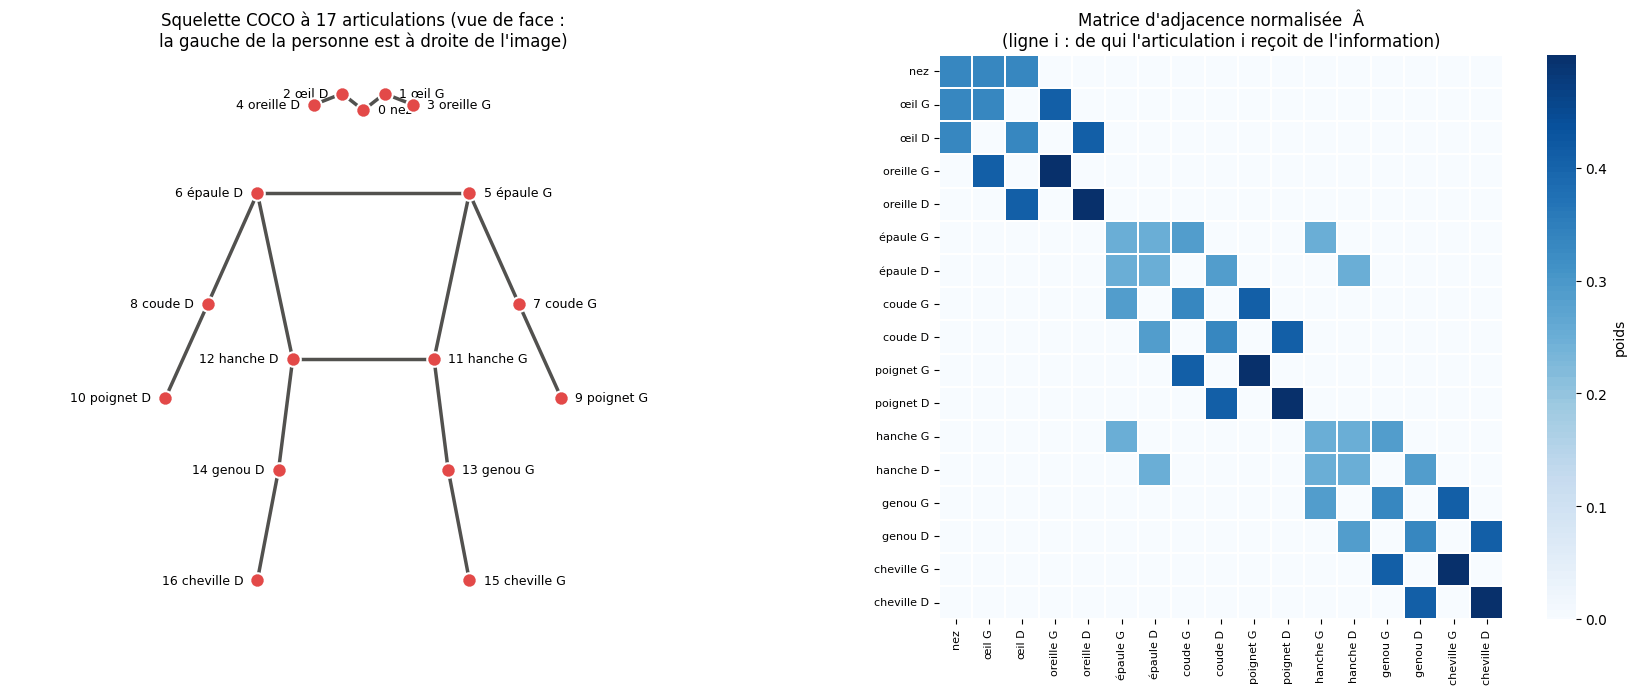

In [20]:
####### Skeleton graph (COCO standard, 17 joints) and normalized adjacency matrix #######
NUM_JOINTS = 17
JOINT_NAMES = ["nose", "L eye", "R eye", "L ear", "R ear", "L shoulder", "R shoulder",
               "L elbow", "R elbow", "L wrist", "R wrist", "L hip", "R hip",
               "L knee", "R knee", "L ankle", "R ankle"]

# Bones (undirected edges)
SKELETON_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4),           # head / face
    (5, 6), (5, 11), (6, 12), (11, 12),       # torso
    (5, 7), (7, 9),                           # left arm
    (6, 8), (8, 10),                          # right arm
    (11, 13), (13, 15),                       # left leg
    (12, 14), (14, 16),                       # right leg
]

def build_normalized_adjacency(num_nodes=NUM_JOINTS, edges=SKELETON_EDGES):
    """Â = D^(-1/2) (A + I) D^(-1/2)  (GCN formulation of Kipf & Welling, 2017)."""
    A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for u, v in edges:
        A[u, v] = A[v, u] = 1.0
    A_tilde = A + np.eye(num_nodes, dtype=np.float32)       # self-loops: each joint keeps its own information
    d_inv_sqrt = np.power(A_tilde.sum(axis=1), -0.5)        # degrees (at least 1 thanks to the self-loops)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return torch.tensor(D_inv_sqrt @ A_tilde @ D_inv_sqrt, dtype=torch.float32)

A_norm = build_normalized_adjacency().to(device)
print(f"Skeleton graph: {NUM_JOINTS} joints (nodes), {len(SKELETON_EDGES)} bones (edges)")
print(f"Normalized adjacency matrix: {tuple(A_norm.shape)}")

# Figure: skeleton topology (front view) + matrix Â
positions_schema = {0: (0.5, 0.9), 1: (0.53, 0.93), 2: (0.47, 0.93), 3: (0.57, 0.91), 4: (0.43, 0.91),
                    5: (0.65, 0.75), 6: (0.35, 0.75), 7: (0.72, 0.55), 8: (0.28, 0.55), 9: (0.78, 0.38),
                    10: (0.22, 0.38), 11: (0.60, 0.45), 12: (0.40, 0.45), 13: (0.62, 0.25), 14: (0.38, 0.25),
                    15: (0.65, 0.05), 16: (0.35, 0.05)}
fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={'width_ratios': [1, 1.25]})
for u, v in SKELETON_EDGES:
    axes[0].plot(*zip(positions_schema[u], positions_schema[v]), '-', color='#52514e', lw=2.5)
for j, (jx, jy) in positions_schema.items():
    axes[0].scatter(jx, jy, color=PALETTE[7], s=110, zorder=5, edgecolor='white', linewidth=1.5)
    axes[0].text(jx + (0.02 if jx >= 0.5 else -0.02), jy, f"{j} {JOINT_NAMES[j]}", fontsize=9,
                 ha='left' if jx >= 0.5 else 'right', va='center')
axes[0].set_title("17-joint COCO skeleton (front view:\nthe person's left is on the right of the image)", fontsize=12)
axes[0].set_xlim(0.0, 1.0); axes[0].set_ylim(-0.02, 1.0); axes[0].axis('off')

sns.heatmap(A_norm.cpu().numpy(), ax=axes[1], cmap='Blues', square=True, cbar_kws={'label': 'weight'},
            xticklabels=JOINT_NAMES, yticklabels=JOINT_NAMES, linewidths=0.3, linecolor='white')
axes[1].set_title("Normalized adjacency matrix  Â\n(row i: which joints joint i receives information from)", fontsize=12)
axes[1].tick_params(axis='x', rotation=90, labelsize=8); axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

### Analysis: the normalized adjacency matrix
- $A$ equals 1 between two joints connected by a bone. We add **self-loops** ($A + I$) so that each joint keeps its own information during aggregation.
- **Symmetric normalization**: $\hat{A} = \tilde{D}^{-1/2}(A + I)\tilde{D}^{-1/2}$, where $\tilde{D}$ is the degree matrix. A highly connected joint (shoulder, hip) does not "speak louder" than the others, and values stay stable when layers are stacked.
- In the heatmap, each row shows **which joints a joint receives information from**. The body structure is visible: the diagonal (self-loops) and a few neighbors per row.

### Skeleton extraction: two methods
| Method | Used when | Principle | Quality |
|---|---|---|---|
| **Keypoint R-CNN** (torchvision) | a GPU is available | network pretrained on COCO that detects people and locates their **17 COCO joints** | real pose estimation; ≈ 10 to 25 min for all of KTH on a T4 GPU (only once, then cached) |
| **Silhouette** (fallback) | no GPU | finds the moving area (difference with the background), then places the 17 joints inside this box according to average body proportions | **coarse approximation**: only the position and size of the box vary, not the actual posture of the arms and legs |

Coordinates are **normalized** by the image size: $x/W$ and $y/H$ lie in $[0, 1]$. When no person is detected (for example because they left the field of view), the frame gets a zero skeleton with confidence 0.

In [21]:
####### Skeleton extraction (17 joints per frame) and caching #######
SKELETON_METHOD = "keypointrcnn" if torch.cuda.is_available() else "silhouette"
SKELETON_CACHE_FILE = os.path.join(CACHE_DIR, f"kth_squelettes_{SKELETON_METHOD}_32frames{CACHE_SUFFIX}.pt")
CONF_THRESHOLD = 0.3   # minimum confidence to draw a joint

_pose_estimator = None
def get_pose_estimator():
    """Loads Keypoint R-CNN only once (weights pretrained on COCO)."""
    global _pose_estimator
    if _pose_estimator is None:
        # KTH is 160x120: images are upscaled to 320 px in height (800 by default), which is much faster
        _pose_estimator = keypointrcnn_resnet50_fpn(weights=KeypointRCNN_ResNet50_FPN_Weights.DEFAULT,
                                                     min_size=320, max_size=427).eval().to(device)
    return _pose_estimator

@torch.no_grad()
def skeletons_keypointrcnn(frames_rgb, person_threshold=0.5, chunk_size=16):
    """(T, H, W, 3) uint8 -> (T, 17, 3): (x/W, y/H, confidence) of the most likely person in each frame."""
    model = get_pose_estimator()
    T, H, W, _ = frames_rgb.shape
    skeletons = np.zeros((T, NUM_JOINTS, 3), dtype=np.float32)
    for start in range(0, T, chunk_size):
        frame_batch = [torch.from_numpy(f).permute(2, 0, 1).float().div(255).to(device) for f in frames_rgb[start:start + chunk_size]]
        for k, output in enumerate(model(frame_batch)):
            # Detections are sorted by decreasing score: #0 is the most likely person
            if len(output['scores']) == 0 or output['scores'][0] < person_threshold:
                continue   # no person detected: zero skeleton, confidence 0
            kp = output['keypoints'][0].cpu().numpy()                             # (17, 3): x, y, visibility
            conf = torch.sigmoid(output['keypoints_scores'][0]).cpu().numpy()    # scores -> [0, 1]
            skeletons[start + k, :, 0] = kp[:, 0] / W
            skeletons[start + k, :, 1] = kp[:, 1] / H
            skeletons[start + k, :, 2] = conf
    return skeletons

# Relative position (inside the person's bounding box) of each joint for a standing body, front view
BODY_PROPORTIONS = [(0.50, 0.08), (0.54, 0.06), (0.46, 0.06), (0.58, 0.08), (0.42, 0.08),
                     (0.70, 0.20), (0.30, 0.20), (0.78, 0.38), (0.22, 0.38), (0.82, 0.52), (0.18, 0.52),
                     (0.62, 0.52), (0.38, 0.52), (0.64, 0.75), (0.36, 0.75), (0.65, 0.97), (0.35, 0.97)]

def skeletons_silhouette(frames_rgb, diff_threshold=25, min_area=20):
    """
    FALLBACK method (no GPU): pseudo-skeleton.
    1) the background is estimated as the median of the frames (the person moves, the background does not);
    2) the area that differs from the background gives the person's bounding box;
    3) the 17 joints are placed inside this box according to fixed proportions.
    Only the position and size of the box change over time: this is NOT a real pose estimation.
    """
    T, H, W, _ = frames_rgb.shape
    gray = frames_rgb.astype(np.float32).mean(axis=3)
    background = np.median(gray, axis=0)
    skeletons = np.zeros((T, NUM_JOINTS, 3), dtype=np.float32)
    for t in range(T):
        fg_mask = (np.abs(gray[t] - background) > diff_threshold).astype(np.uint8) * 255
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
        contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        if cv2.contourArea(contour) < min_area:
            continue
        bx, by, bw, bh = cv2.boundingRect(contour)
        for j, (rx, ry) in enumerate(BODY_PROPORTIONS):
            skeletons[t, j] = [(bx + rx * bw) / W, (by + ry * bh) / H, 0.5]
    return skeletons

def extract_skeletons(frames_rgb):
    if SKELETON_METHOD == "keypointrcnn":
        return skeletons_keypointrcnn(frames_rgb)
    return skeletons_silhouette(frames_rgb)

def extract_and_cache_skeletons(splits, cache_path=SKELETON_CACHE_FILE, force=False):
    if os.path.exists(cache_path) and not force:
        cache = torch.load(cache_path, map_location='cpu', weights_only=True)
        if cache.get('videos') == list_videos(splits):
            print(f"Skeleton cache loaded: {os.path.relpath(cache_path)}")
            return cache
        print("The cache does not match the current videos: recomputing.")

    print(f"Extracting skeletons (method: {SKELETON_METHOD})...")
    cache = {'videos': list_videos(splits), 'method': SKELETON_METHOD}
    for split_name in ['train', 'val', 'test']:
        all_skels, all_labels = [], []
        for vpath, label, _ in tqdm(splits[split_name], desc=f"Skeletons {split_name}"):
            frames = read_raw_frames(vpath, MAX_FRAMES)                  # same 32 frames as for the CNN
            all_skels.append(torch.from_numpy(extract_skeletons(frames)))  # (32, 17, 3)
            all_labels.append(label)
        cache[split_name] = {'skeletons': torch.stack(all_skels, dim=0),     # (N, 32, 17, 3)
                             'labels': torch.tensor(all_labels, dtype=torch.long)}
    torch.save(cache, cache_path)
    print(f"Cache saved: {os.path.relpath(cache_path)}")
    return cache

print(f"Skeleton extraction method: {SKELETON_METHOD}")
if SKELETON_METHOD == "silhouette":
    print("⚠️  No GPU: approximate pseudo-skeletons. GNN results will not be very representative.")
skeleton_data = extract_and_cache_skeletons(splits)

# DataLoaders for the GNNs: T = 16 frames, 17 joints, 3 channels
gnn_loaders = make_loaders(skeleton_data, 'skeletons', seq_len=16, batch_size=32)
x_skel, _ = next(iter(gnn_loaders['train']))
print(f"GNN batch (batch, T, joints, channels): {tuple(x_skel.shape)}")

# Fraction of frames in which a person was found, per action
detection = {}
for split_name in ['train', 'val', 'test']:
    S = skeleton_data[split_name]['skeletons']
    frac = (S[..., 2].amax(dim=2) > 0).float().mean(dim=1)   # per video
    for lab, f in zip(skeleton_data[split_name]['labels'].tolist(), frac.tolist()):
        detection.setdefault(CLASSES[lab], []).append(f)
display(pd.DataFrame({"% of frames with a detected person":
                      {DISPLAY_NAMES[c]: 100 * np.mean(detection[c]) for c in CLASSES}}).round(1))

Skeleton extraction method: keypointrcnn
Extracting skeletons (method: keypointrcnn)...


Skeletons train:   0%|          | 0/191 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/keypointrcnn_resnet50_fpn_coco-fc266e95.pth" to /root/.cache/torch/hub/checkpoints/keypointrcnn_resnet50_fpn_coco-fc266e95.pth



  0%|          | 0.00/226M [00:00<?, ?B/s]
  7%|▋         | 16.8M/226M [00:00<00:01, 176MB/s]
 17%|█▋        | 37.8M/226M [00:00<00:00, 201MB/s]
 25%|██▌       | 57.0M/226M [00:00<00:00, 187MB/s]
 33%|███▎      | 75.6M/226M [00:00<00:00, 190MB/s]
 42%|████▏     | 94.8M/226M [00:00<00:00, 193MB/s]
 50%|█████     | 113M/226M [00:00<00:00, 177MB/s] 
 58%|█████▊    | 132M/226M [00:00<00:00, 182MB/s]
 67%|██████▋   | 151M/226M [00:00<00:00, 189MB/s]
 76%|███████▌  | 171M/226M [00:00<00:00, 193MB/s]
 84%|████████▍ | 190M/226M [00:01<00:00, 196MB/s]
100%|██████████| 226M/226M [00:01<00:00, 181MB/s]


Skeletons val:   0%|          | 0/144 [00:00<?, ?it/s]

Skeletons test:   0%|          | 0/264 [00:00<?, ?it/s]

Cache saved: cached_features/kth_skeletons_keypointrcnn_32frames.pt
GNN batch (batch, T, joints, channels): (32, 16, 17, 3)


,% of frames with a detected person
boxing,99.9
hand clapping,99.9
hand waving,99.7
jogging,44.7
running,35.7
walking,50.8


### Analysis: what a skeleton contains
- **Tensor shape**: $(B, T, V, C) = (32, 16, 17, 3)$, i.e. 32 videos, 16 frames, 17 joints ($V$) and 3 channels $(x, y, \text{confidence})$.
- **Detection rate** (table above): for each action, the fraction of frames in which a person was found. In the reference run, it is ≈ 100 % for in-place actions, but **only 36 to 51 % for locomotion actions**: the person is missing from one frame out of two, or more (see the gallery in part 1). For these actions, the GNN therefore mostly receives zero skeletons. The absence of detection is still information in itself: a runner crosses the frame faster, so they are visible in fewer frames.
- **Normalization choice**: coordinates are kept in the image frame, not centered on the body. This way, the **global displacement** of the person, highly discriminative for walking / jogging / running, remains visible.

### Example: skeletons overlaid on the videos

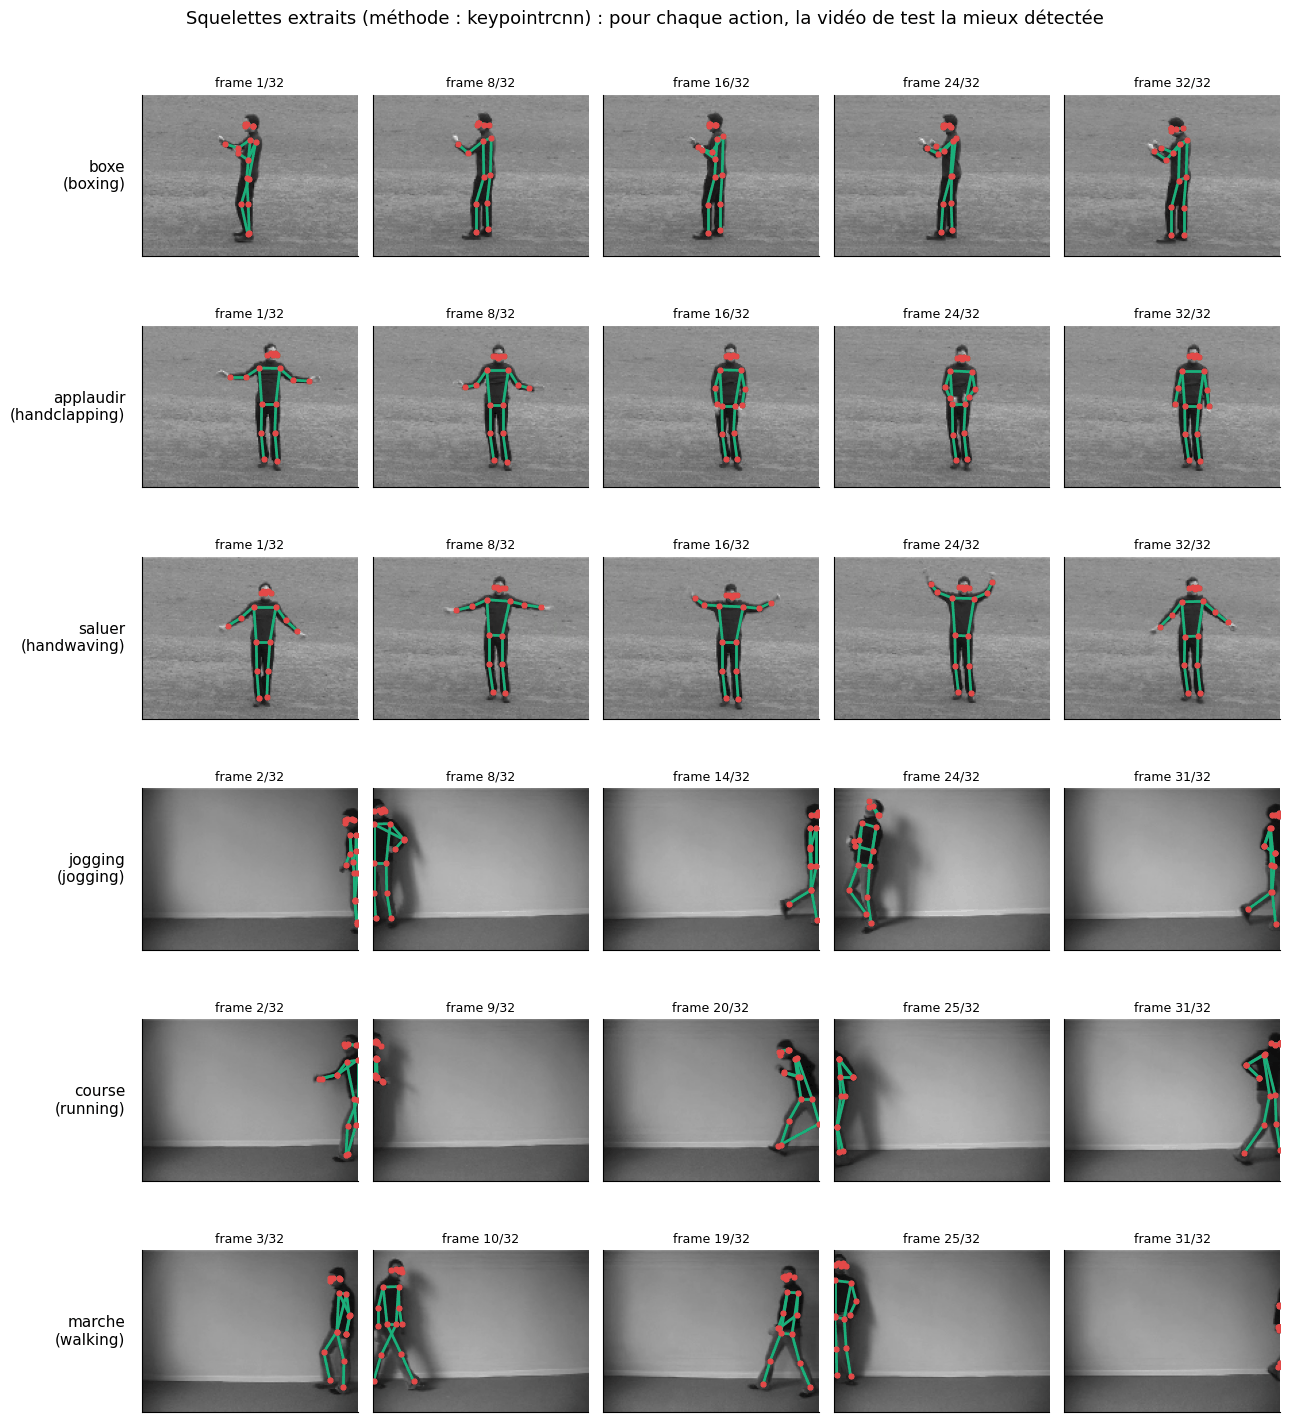

In [22]:
####### Extracted skeletons overlaid on the frames (one test video per action) #######
def draw_skeleton(ax, skeleton, W, H, line_color='#1baf7a'):
    """Draws the bones whose two joints are reliable enough."""
    for u, v in SKELETON_EDGES:
        if skeleton[u, 2] > CONF_THRESHOLD and skeleton[v, 2] > CONF_THRESHOLD:
            ax.plot([skeleton[u, 0] * W, skeleton[v, 0] * W], [skeleton[u, 1] * H, skeleton[v, 1] * H],
                    '-', color=line_color, lw=2)
    ok = skeleton[:, 2] > CONF_THRESHOLD
    ax.scatter(skeleton[ok, 0] * W, skeleton[ok, 1] * H, s=12, color=PALETTE[7], zorder=3)

def best_detected_video(class_name, split='test'):
    """Index of the video of this action in which a person is detected in the largest number of frames."""
    S = skeleton_data[split]['skeletons']
    fraction = (S[..., 2].amax(dim=2) > 0).float().mean(dim=1).numpy()
    indices = [i for i, (_, label, _) in enumerate(splits[split]) if CLASSES[label] == class_name]
    return max(indices, key=lambda i: fraction[i])

N_POSITIONS = 5
fig, axes = plt.subplots(len(CLASSES), N_POSITIONS, figsize=(13, 14.5))
for r, cls in enumerate(CLASSES):
    i = best_detected_video(cls)
    vpath = splits['test'][i][0]
    frames = read_raw_frames(vpath, MAX_FRAMES)
    H, W = frames.shape[1:3]
    video_skeletons = skeleton_data['test']['skeletons'][i].numpy()
    # 5 frames spread over those in which a person was detected (otherwise, spread over the whole video)
    detected = np.where(video_skeletons[:, :, 2].max(axis=1) > 0)[0]
    if len(detected) >= N_POSITIONS:
        positions = detected[np.linspace(0, len(detected) - 1, N_POSITIONS, dtype=int)]
    else:
        positions = np.linspace(0, MAX_FRAMES - 1, N_POSITIONS, dtype=int)
    for c, t in enumerate(positions):
        ax = axes[r, c]
        ax.imshow(frames[t])
        draw_skeleton(ax, video_skeletons[t], W, H)
        ax.set_xlim(-0.5, W - 0.5); ax.set_ylim(H - 0.5, -0.5)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(f"frame {t + 1}/32", fontsize=9)
        if c == 0:
            ax.set_ylabel(DISPLAY_NAMES[cls], fontsize=11, rotation=0, ha='right', va='center', labelpad=12)
plt.suptitle(f"Extracted skeletons (method: {SKELETON_METHOD}): for each action, the best-detected test video",
             fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

For each action, we show the test video in which the person is most often detected, and 5 frames where they are visible. Remember that, for locomotion actions, **most frames are empty**: this figure shows the *best* cases.

**What to observe:** with Keypoint R-CNN, the skeleton follows the arms and legs. The difference between boxing (arms forward), clapping (wrists meeting) and waving (wrists above the head) is directly visible. Pose estimator errors (missing joints, skeleton offset on a blurry person) propagate all the way to the GNN: this is the main weakness of this approach. With the *silhouette* method, the "skeleton" is just a fixed template, moved and stretched with the person's bounding box.

**Animation: the video and the extracted skeleton side by side.** On the left, the frame with the skeleton overlaid. On the right, **only what the GNN receives**: 17 points connected by bones, without a single pixel. The 32 cached frames cover the whole video, so the animation looks sped up. When the notebook is run, the cell below renders an interactive player; the GIF below is an export of the reference run.

![Video with overlaid skeleton vs what the GNN receives](assets/kth_cnn_vs_skeleton.gif)

In [23]:
####### Animation: "what the CNN sees" vs "what the GNN sees" #######
def animate_skeletons(indices, split='test', fps=6, dpi=60):
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(7.5, 2.9 * n), dpi=dpi)
    axes = np.atleast_2d(axes)
    elements = []
    for r, i in enumerate(indices):
        vpath, label, _ = splits[split][i]
        frames = read_raw_frames(vpath, MAX_FRAMES)
        video_skeletons = skeleton_data[split]['skeletons'][i].numpy()
        H, W = frames.shape[1:3]
        image = axes[r, 0].imshow(frames[0])
        axes[r, 0].set_title(f"Video: {DISPLAY_NAMES[CLASSES[label]]}", fontsize=11)
        axes[r, 1].set_facecolor('black')
        axes[r, 1].set_xlim(0, W); axes[r, 1].set_ylim(H, 0); axes[r, 1].set_aspect('equal')
        axes[r, 1].set_title("What the GNN receives", fontsize=11)
        video_rows = [axes[r, 0].plot([], [], '-', color='#1baf7a', lw=2)[0] for _ in SKELETON_EDGES]
        single_rows = [axes[r, 1].plot([], [], '-', color='white', lw=2)[0] for _ in SKELETON_EDGES]
        for ax in axes[r]:
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        elements.append((frames, video_skeletons, W, H, image, video_rows, single_rows))
    fig.tight_layout()

    def update_frame(t):
        artists = []
        for frames, sq, W, H, image, video_rows, single_rows in elements:
            image.set_data(frames[t])
            artists.append(image)
            for (u, v), l1, l2 in zip(SKELETON_EDGES, video_rows, single_rows):
                if sq[t, u, 2] > CONF_THRESHOLD and sq[t, v, 2] > CONF_THRESHOLD:
                    xs, ys = [sq[t, u, 0] * W, sq[t, v, 0] * W], [sq[t, u, 1] * H, sq[t, v, 1] * H]
                else:
                    xs, ys = [], []
                l1.set_data(xs, ys); l2.set_data(xs, ys)
                artists += [l1, l2]
        return artists

    anim = animation.FuncAnimation(fig, update_frame, frames=MAX_FRAMES, interval=1000 / fps, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml(default_mode='loop'))

display(animate_skeletons([best_detected_video('handwaving'), best_detected_video('running')]))

In [24]:
####### Graph convolution layer on the skeleton (spatial GCN) #######
class SkeletonGraphConv(nn.Module):
    """
    Graph convolution over the 17 joints:
      H^(l+1) = ReLU( BatchNorm( Â · H^(l) · W ) )
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)   # W: shared by all joints
        self.bn = nn.BatchNorm1d(out_features)
        self.relu = nn.ReLU()

    def forward(self, x, A_hat):
        # x : (B*T, 17, in_features) ; A_hat : (17, 17)
        support = torch.matmul(A_hat, x)   # message passing: each joint aggregates its neighbors
        out = self.linear(support)         # (B*T, 17, out_features)
        BT, V, C = out.shape
        out = self.bn(out.reshape(BT * V, C)).reshape(BT, V, C)
        return self.relu(out)

### Analysis: graph convolution (message passing)
A `SkeletonGraphConv` layer computes:
$$H^{(l+1)} = \text{ReLU}\big(\text{BN}(\hat{A}\, H^{(l)}\, W)\big)$$
- $\hat{A}H$: each joint takes a **weighted average** of the features of its direct neighbors. The wrist receives those of the elbow; the elbow, those of the shoulder and wrist.
- $W$: a linear transformation **shared** by all joints, just as CNN filters are shared by all pixels.
- **Two stacked layers**: each joint "sees" up to 2 bones away (for example wrist → elbow → shoulder). This is enough to capture relations such as "arm stretched" or "wrists close to each other".

After the two layers, we **average over the 17 joints** (*readout*) to get one vector per frame. Then, exactly as in part 3, an LSTM or a Transformer processes the sequence of these vectors.

In [25]:
####### Architecture 4: GNN + LSTM #######
class GNNLSTMClassifier(nn.Module):
    """
    1. Spatial GCN : processes the skeleton of each frame (2 layers)
    2. Readout     : mean over the 17 joints -> one vector per frame
    3. LSTM        : 2 recurrent layers over time
    4. Classifier  : 6 actions
    """
    def __init__(self, A_hat, in_channels=3, gnn_hidden=64, lstm_hidden=128, num_layers=2, num_classes=6, dropout=0.3):
        super().__init__()
        self.register_buffer('A_hat', A_hat.clone())   # fixed graph: follows the model (GPU, checkpoint) without being trained
        self.gcn1 = SkeletonGraphConv(in_channels, gnn_hidden)
        self.gcn2 = SkeletonGraphConv(gnn_hidden, gnn_hidden)
        self.lstm = nn.LSTM(input_size=gnn_hidden, hidden_size=lstm_hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(nn.Linear(lstm_hidden, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, num_classes))

    def forward(self, x):
        B, T, V, C = x.shape                          # (B, T, 17, 3)
        h = x.reshape(B * T, V, C)                    # all frames of the batch processed at once
        h = self.gcn2(self.gcn1(h, self.A_hat), self.A_hat)   # (B*T, 17, 64)
        h_seq = h.mean(dim=1).reshape(B, T, -1)       # readout -> (B, T, 64)
        lstm_out, _ = self.lstm(h_seq)
        return self.classifier(lstm_out.mean(dim=1))

seed_everything(42)
gnn_lstm_model = GNNLSTMClassifier(A_norm).to(device)
p_gnn_lstm = count_parameters(gnn_lstm_model)
print(f"Training GNN + LSTM ({p_gnn_lstm:,} parameters)...")
histories_gnn = {}
histories_gnn["GNN + LSTM"], _ = train_model(gnn_lstm_model, "GNN + LSTM", gnn_loaders)

results["GNN + LSTM"] = test_report(gnn_lstm_model, gnn_loaders['test'])
print(f"GNN + LSTM — test accuracy: {results['GNN + LSTM']['acc'] * 100:.2f} % | Macro F1: {results['GNN + LSTM']['f1']:.4f}")

Training GNN + LSTM (244,742 parameters)...
[GNN + LSTM        ] Epoch 10/35 | Train acc:  37.2 % | Val acc:  34.7 %
[GNN + LSTM        ] Epoch 20/35 | Train acc:  41.4 % | Val acc:  39.6 %
[GNN + LSTM        ] Epoch 30/35 | Train acc:  41.9 % | Val acc:  38.2 %
[GNN + LSTM        ] Epoch 35/35 | Train acc:  44.5 % | Val acc:  38.2 %
[GNN + LSTM        ] Best validation accuracy: 41.0 % (1.6 s)
GNN + LSTM — test accuracy: 40.53 % | Macro F1: 0.2745


### Analysis: GNN + LSTM
- **Two stages**: (1) the GCN turns each skeleton into a 64-value posture vector; (2) the LSTM tracks how this posture evolves over time.
- **Compactness**: ≈ 245 k parameters, vs ≈ 1.41 M for the CNN + LSTM, about 6 times fewer. Almost the whole budget is in the LSTM: the GCN weighs only about 5,000 parameters.
- `A_hat` is registered as a model **buffer**: it follows the model to the GPU and into checkpoints, but it is not trained, since the body graph is fixed in advance.

In [26]:
####### Architecture 5: GNN + Transformer #######
class GNNTransformerClassifier(nn.Module):
    """
    1. Spatial GCN : processes the skeleton of each frame
    2. Readout     : mean over the 17 joints
    3. Transformer : multi-head self-attention over time, with learned positional embeddings
    4. [CLS] token : its output is used to classify the video
    """
    def __init__(self, A_hat, in_channels=3, gnn_hidden=64, d_model=128, nhead=4,
                 num_layers=2, num_classes=6, max_len=64, dropout=0.2):
        super().__init__()
        self.register_buffer('A_hat', A_hat.clone())
        self.gcn1 = SkeletonGraphConv(in_channels, gnn_hidden)
        self.gcn2 = SkeletonGraphConv(gnn_hidden, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_embeddings = nn.Parameter(torch.randn(1, max_len + 1, d_model) * 0.02)   # plongements positionnels APPRIS
        self.dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
                                                   dropout=dropout, batch_first=True, activation='gelu')
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False)
        self.classifier = nn.Sequential(nn.Linear(d_model, 64), nn.GELU(), nn.Dropout(dropout), nn.Linear(64, num_classes))

    def sequence_frames(self, x):
        """Frame vectors right before the Transformer: (B, T, 17, 3) -> (B, T, d_model)."""
        B, T, V, C = x.shape
        h = self.gcn2(self.gcn1(x.reshape(B * T, V, C), self.A_hat), self.A_hat)   # (B*T, 17, d_model)
        return h.mean(dim=1).reshape(B, T, -1)

    def forward(self, x):
        B, T = x.shape[:2]
        h = self.sequence_frames(x)
        h = torch.cat((self.cls_token.expand(B, -1, -1), h), dim=1) + self.pos_embeddings[:, :T + 1, :]
        out = self.transformer_encoder(self.dropout(h))
        return self.classifier(out[:, 0, :])

seed_everything(42)
gnn_tf_model = GNNTransformerClassifier(A_norm).to(device)
p_gnn_tf = count_parameters(gnn_tf_model)
print(f"Training GNN + Transformer ({p_gnn_tf:,} parameters)...")
histories_gnn["GNN + Transformer"], _ = train_model(gnn_tf_model, "GNN + Transformer", gnn_loaders)

results["GNN + Transformer"] = test_report(gnn_tf_model, gnn_loaders['test'])
print(f"GNN + Transformer — test accuracy: {results['GNN + Transformer']['acc'] * 100:.2f} % | Macro F1: {results['GNN + Transformer']['f1']:.4f}")

Training GNN + Transformer (291,014 parameters)...
[GNN + Transformer ] Epoch 10/35 | Train acc:  47.6 % | Val acc:  51.4 %
[GNN + Transformer ] Epoch 20/35 | Train acc:  56.0 % | Val acc:  50.0 %
[GNN + Transformer ] Epoch 30/35 | Train acc:  59.7 % | Val acc:  55.6 %
[GNN + Transformer ] Epoch 35/35 | Train acc:  60.7 % | Val acc:  53.5 %
[GNN + Transformer ] Best validation accuracy: 56.2 % (2.9 s)
GNN + Transformer — test accuracy: 53.41 % | Macro F1: 0.5028


### Analysis: GNN + Transformer
- **Space, then time**: the GCN models **local** interactions between neighboring joints within a frame. The Transformer then relates postures **anywhere in time** (frame $t_i$ with frame $t_j$).
- **Size**: ≈ 291 k parameters, about 5 times fewer than the CNN + Transformer (≈ 1.43 M).
- **`sequence_frames` method**: returns the sequence of frame vectors *before* the Transformer. It is used in part 7 to extract the real attention maps.

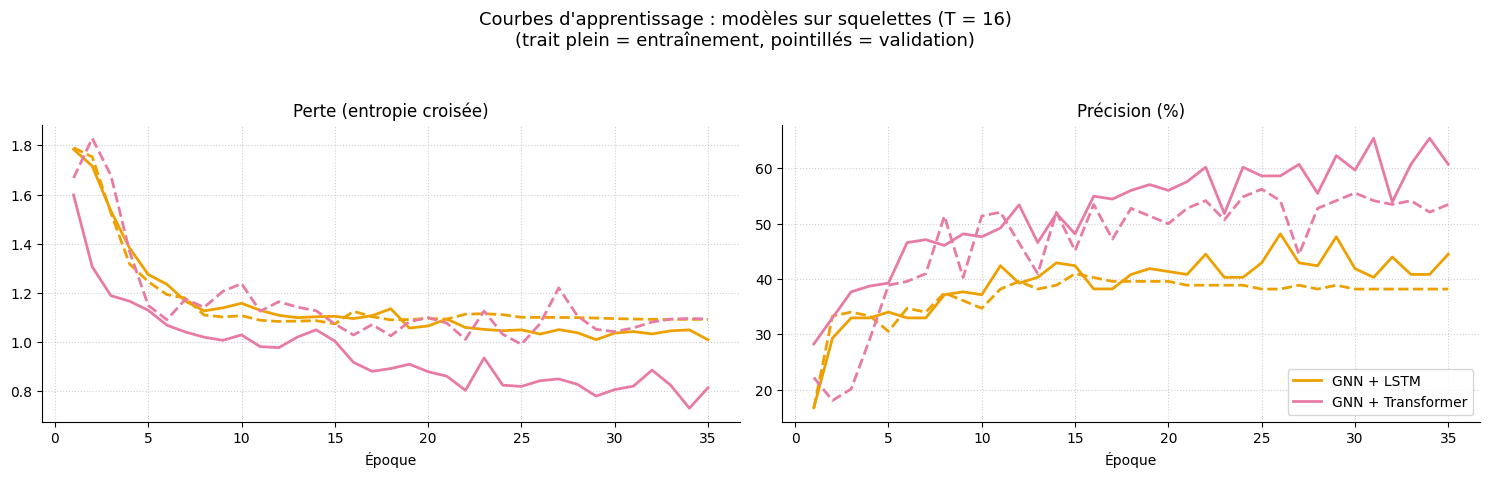

In [27]:
####### Learning curves of the two GNNs #######
plot_curves(histories_gnn, "Learning curves: skeleton models (T = 16)")

### Analysis: why are the GNNs so weak here?
Compare with the curves of the CNN heads: this is no longer overfitting, but **underfitting**. In the reference run, the GNNs only reach ≈ 45 to 61 % accuracy **even on the training data** (44.5 % and 60.7 % at the last epoch). The model fails to extract enough information from its inputs. Four causes add up:
1. **Often-missing skeletons**: for locomotion actions, a person is detected in only 36 to 51 % of frames (skeleton extraction table above). The rest of the time, the GNN receives zeros.
2. **Low resolution**: people in KTH are a few dozen pixels tall. Keypoint R-CNN, trained on much sharper COCO photos, sometimes misplaces the joints.
3. **Mean *readout* erases joint identity**: GCN weights are shared by all joints, then we average over the 17. Yet the body graph is very symmetric (left ≈ right, and even wrist ≈ ankle: two extremities connected to an intermediate joint). The model therefore struggles to know *which* joint is where, e.g. "a wrist above the head". ST-GCN avoids this by keeping the 17 joints separate until the end of the network.
4. **Same hyperparameters as for the CNNs**: 35 epochs are enough for the CNN heads, but not necessarily for a weaker signal.

The future-work ideas in part 8 suggest ways to address each of these points.

---
# Part 6: Overall comparison of the 5 models

All models are evaluated on **the same test videos** (same people, same order), with $T = 16$ frames. Two latency measures are reported:
- **Head latency**: time of one pass through the temporal model alone, for one video (batch of 1).
- **16-frame extraction**: time to compute the model input from the images (MobileNetV2 for the CNNs, pose estimation for the GNNs). **In a real application, this cost often dominates.**

OVERALL COMPARISON OF THE 5 MODELS (T = 16, skeleton extraction: keypointrcnn)


,Representation,Params (head),Head latency (ms),16-frame extraction (ms),Test accuracy (%),Macro F1
Model,,,,,,
Temporal mean,CNN (pixels),"362,118",0.24,17.0,78.79,0.7917
CNN + LSTM,CNN (pixels),"1,414,790",1.18,17.0,65.15,0.6408
CNN + Transformer,CNN (pixels),"1,433,222",1.08,17.0,80.68,0.8074
GNN + LSTM,Skeleton (graph),"244,742",0.81,484.2,40.53,0.2745
GNN + Transformer,Skeleton (graph),"291,014",1.27,484.2,53.41,0.5028


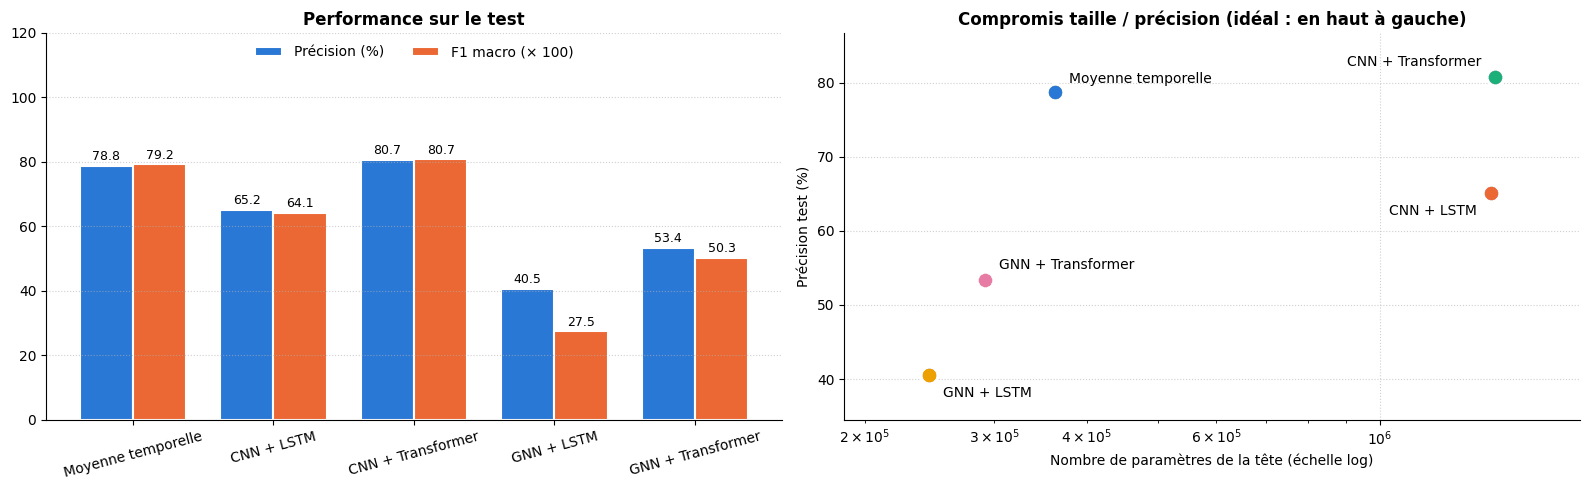

In [28]:
####### Overall comparison of the 5 models #######
def measure_latency(fn, inp, n_runs=100, n_warmup=10):
    """Mean time (ms) of a call to fn(inp). The GPU is synchronized to measure the actual compute time."""
    with torch.no_grad():
        for _ in range(n_warmup):
            fn(inp)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(n_runs):
            fn(inp)
        if device.type == 'cuda':
            torch.cuda.synchronize()
    return (time.perf_counter() - start) / n_runs * 1000

final_models = {
    "Temporal mean": {'model': model_mean,     'inp': 'cnn', 'representation': 'CNN (pixels)'},
    "CNN + LSTM":         {'model': model_lstm,     'inp': 'cnn', 'representation': 'CNN (pixels)'},
    "CNN + Transformer":  {'model': model_tf,       'inp': 'cnn', 'representation': 'CNN (pixels)'},
    "GNN + LSTM":         {'model': gnn_lstm_model, 'inp': 'gnn', 'representation': 'Skeleton (graph)'},
    "GNN + Transformer":  {'model': gnn_tf_model,   'inp': 'gnn', 'representation': 'Skeleton (graph)'},
}
for m in final_models.values():
    m['model'].eval()

sample_input = {'cnn': torch.randn(1, 16, 1280, device=device), 'gnn': torch.rand(1, 16, NUM_JOINTS, 3, device=device)}
frames_latence = read_raw_frames(splits['test'][0][0], 16)
extraction_latency = {
    'cnn': measure_latency(extractor, torch.randn(16, 3, FRAME_SIZE, FRAME_SIZE, device=device), n_runs=10, n_warmup=2),
    'gnn': measure_latency(extract_skeletons, frames_latence, n_runs=3, n_warmup=1),
}

table_rows = []
for name, m in final_models.items():
    table_rows.append({'Model': name,
                   'Representation': m['representation'],
                   'Params (head)': count_parameters(m['model']),
                   'Head latency (ms)': measure_latency(m['model'], sample_input[m['inp']]),
                   '16-frame extraction (ms)': extraction_latency[m['inp']],
                   'Test accuracy (%)': results[name]['acc'] * 100,
                   'Macro F1': results[name]['f1']})
df_bench = pd.DataFrame(table_rows).set_index('Model')
print(f"OVERALL COMPARISON OF THE 5 MODELS (T = 16, skeleton extraction: {SKELETON_METHOD})")
display(df_bench.style.format({'Params (head)': '{:,.0f}', 'Head latency (ms)': '{:.2f}',
                               '16-frame extraction (ms)': '{:.1f}', 'Test accuracy (%)': '{:.2f}', 'Macro F1': '{:.4f}'}))

# Plots: accuracy / F1 per model, and size / accuracy trade-off
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(df_bench))
bar_width = 0.38
bars = axes[0].bar(x - bar_width / 2, df_bench['Test accuracy (%)'], width=bar_width, color=PALETTE[0],
                     edgecolor='white', linewidth=1.5, label='Accuracy (%)')
axes[0].bar_label(bars, fmt='%.1f', fontsize=9, padding=2)
bars = axes[0].bar(x + bar_width / 2, df_bench['Macro F1'] * 100, width=bar_width, color=PALETTE[1],
                     edgecolor='white', linewidth=1.5, label='Macro F1 (× 100)')
axes[0].bar_label(bars, fmt='%.1f', fontsize=9, padding=2)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_bench.index, rotation=15)
axes[0].set_ylim(0, 120); axes[0].set_title("Test performance", fontweight='bold')
axes[0].legend(loc='upper center', ncol=2, frameon=False)
axes[0].grid(True, axis='y')

# Label offsets: models of similar size (LSTM / Transformer) are labeled on either side of the point
shifts = {"Temporal mean": (10, 6, 'left'), "CNN + LSTM": (-10, -16, 'right'), "CNN + Transformer": (-10, 8, 'right'),
             "GNN + LSTM": (10, -16, 'left'), "GNN + Transformer": (10, 8, 'left')}
for name, row in df_bench.iterrows():
    axes[1].scatter(row['Params (head)'], row['Test accuracy (%)'], s=140, color=MODEL_COLORS[name],
                    edgecolor='white', linewidth=2, zorder=3)
    dx, dy, ha = shifts[name]
    axes[1].annotate(name, (row['Params (head)'], row['Test accuracy (%)']), textcoords='offset points',
                     xytext=(dx, dy), ha=ha, fontsize=10)
axes[1].margins(x=0.15, y=0.15)
axes[1].set_xscale('log')
axes[1].set_xlabel("Number of head parameters (log scale)")
axes[1].set_ylabel("Test accuracy (%)")
axes[1].set_title("Size / accuracy trade-off (ideal: top left)", fontweight='bold')
axes[1].grid(True)
plt.tight_layout()
plt.show()

### Analysis: what the comparison shows
1. **Spatial representation: CNN or skeleton?**
   - **CNN (pixels)**: captures overall appearance (silhouette, background, motion blur). It is rich, but sensitive to the background (as the PCA in part 2 suggests), and the heads are heavy (≈ 0.4 to 1.4 M parameters).
   - **Skeleton (graph)**: keeps only body geometry, with heads about 5 to 6 times lighter. In the reference run, however, it does **much worse** (≈ 41 to 53 %, vs ≈ 65 to 81 % for the CNNs), for the reasons detailed after the GNN curves. Pose estimation is also **the most expensive step** of the pipeline: ≈ 480 ms for 16 frames, vs ≈ 17 ms for MobileNetV2 on the reference T4 GPU ("Extraction" column).
2. **Temporal modeling: LSTM or Transformer?**
   - At comparable size, **the Transformer beats the LSTM by 15.5 points** on CNN features and by **12.9 points** on skeletons. With spaced-out and often empty frames, being able to directly "pick" the useful frames (attention) is better than pushing everything step by step through a memory (recurrence).
   - But the Transformer beats the simple mean by only 1.9 points (non-significant with a single seed) and the LSTM stays 13.6 points behind: frame order carries little information here (see the shuffling experiment in part 7).
3. **The accuracy / cost trade-off**: the right-hand plot places each model according to its size and accuracy. The best trade-offs are at the top left (small and accurate). Here, the temporal mean is the smallest CNN head (0.36 M parameters) and stays close to the Transformer (78.8 % vs 80.7 %), which is four times larger.

### Reading a confusion matrix
Each **row** is the true action and each **column** the predicted action. Values are row-normalized: the diagonal gives the **recall** of each action, i.e. the fraction of true "boxing" videos recognized as "boxing". Everything off the diagonal is a confusion.

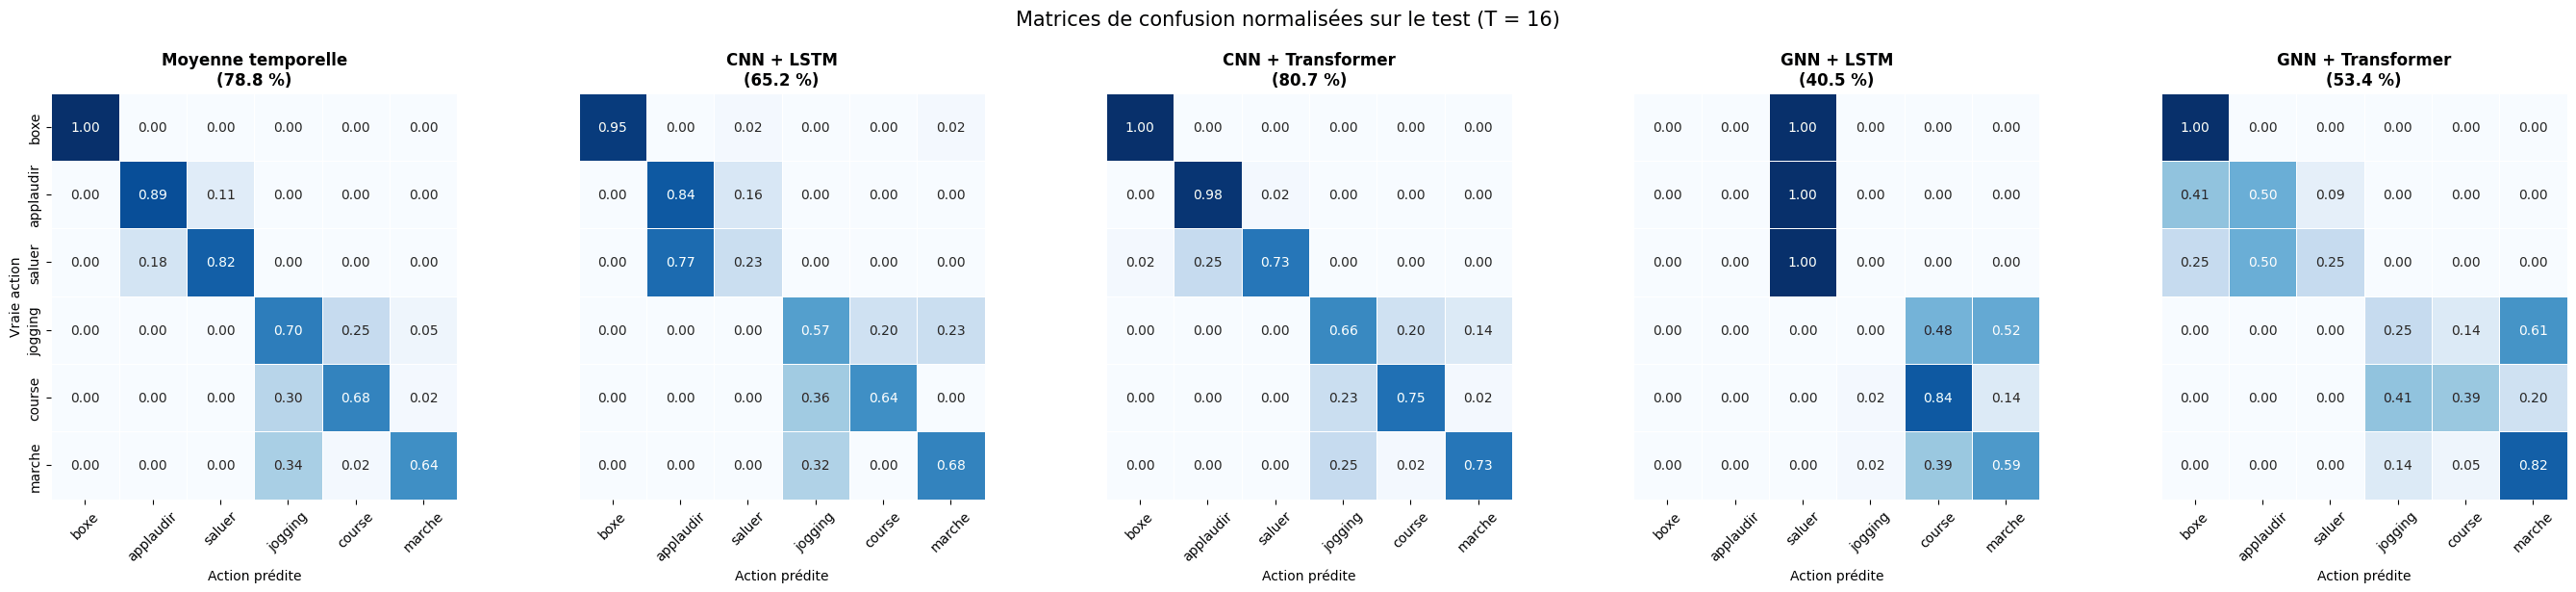

In [29]:
####### Normalized confusion matrices of the 5 models #######
tick_labels = [DISPLAY_NAMES[c] for c in CLASSES]
fig, axes = plt.subplots(1, 5, figsize=(28, 5.6))
for idx, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(r['targets'], r['preds'], labels=range(len(CLASSES)), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, xticklabels=tick_labels,
                yticklabels=tick_labels if idx == 0 else False, ax=axes[idx], cbar=False, square=True,
                linewidths=0.5, linecolor='white')
    axes[idx].set_title(f"{name}\n({r['acc'] * 100:.1f} %)", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Predicted action")
    axes[idx].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Vraie action")
plt.suptitle("Normalized confusion matrices on the test set (T = 16)", fontsize=15, y=1.04)
plt.tight_layout()
plt.show()

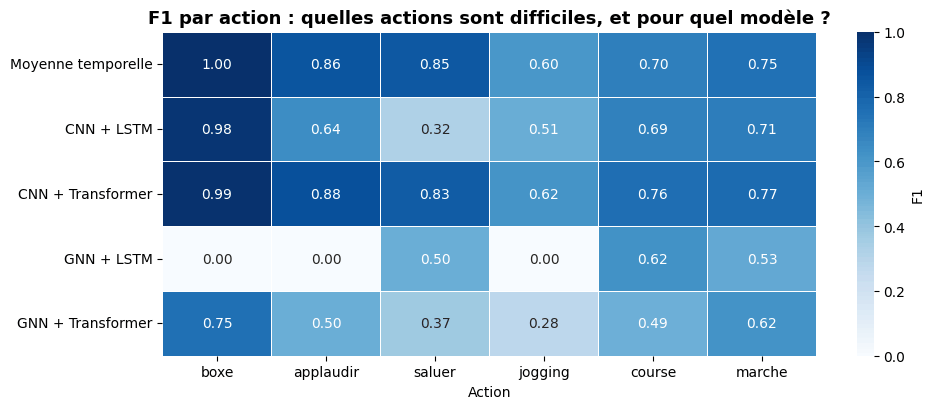

In [30]:
####### F1 per action and per model #######
f1_per_action = pd.DataFrame(
    {name: f1_score(r['targets'], r['preds'], labels=range(len(CLASSES)), average=None) for name, r in results.items()},
    index=tick_labels).T
fig, ax = plt.subplots(figsize=(10, 4.2))
sns.heatmap(f1_per_action, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'F1'})
ax.set_title("F1 per action: which actions are hard, and for which model?", fontsize=13, fontweight='bold')
ax.set_xlabel("Action"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Error analysis (reference run)
- **Almost no confusion between families** for the CNN models: an "in-place" action is almost never mistaken for a "locomotion" action, and vice versa (one single exception: a boxing video classified as "walking" by the CNN + LSTM). The two large blocks of off-diagonal zeros show it.
- **Walking ↔ jogging ↔ running**: this is the hardest boundary, for every model (F1 of about 0.5 to 0.75 for the CNN models). The postures are nearly identical, and what distinguishes them, speed, is hard to see on frames one second apart and often empty. Moreover, speed depends on the person: one person's fast jog looks like another's slow run.
- **Clapping ↔ waving**: this is the main confusion on the arm side. In KTH, many people clap with wide-open arms, and waving moves the arms through the horizontal (see the gallery in part 1). At random instants, the two postures therefore often look alike.
- **Boxing is almost perfectly recognized** by the CNN models: the person is in side view, in guard, which is very different from the two other arm actions.
- **The GNN + LSTM collapsed on arm actions**: in this run, it predicts "hand waving" for 100 % of boxing, clapping and waving videos (zero F1 for boxing and clapping). The predicted class changes from one run to another ("boxing" in a previous run): this behavior is not reproducible with a single seed. It is a typical symptom of underfitting: lacking anything better, the model outputs the same class for a whole group.
- The **per-action F1 map** sums it all up: a pale column flags an action that is hard for every model, a pale row a weak model.

---
# Part 7: Examples on videos: predictions and interpretability

Global numbers do not tell **on which videos** the models succeed or fail. This part examines test videos one by one, with four tools:
1. a **prediction gallery**: one video per action, plus the hardest cases;
2. the **real attention maps** of the Transformers: which frames matter for the decision?
3. a **frame-shuffling experiment**: do the models really use temporal order?
4. a **demo**: predict the action of any video, including your own.

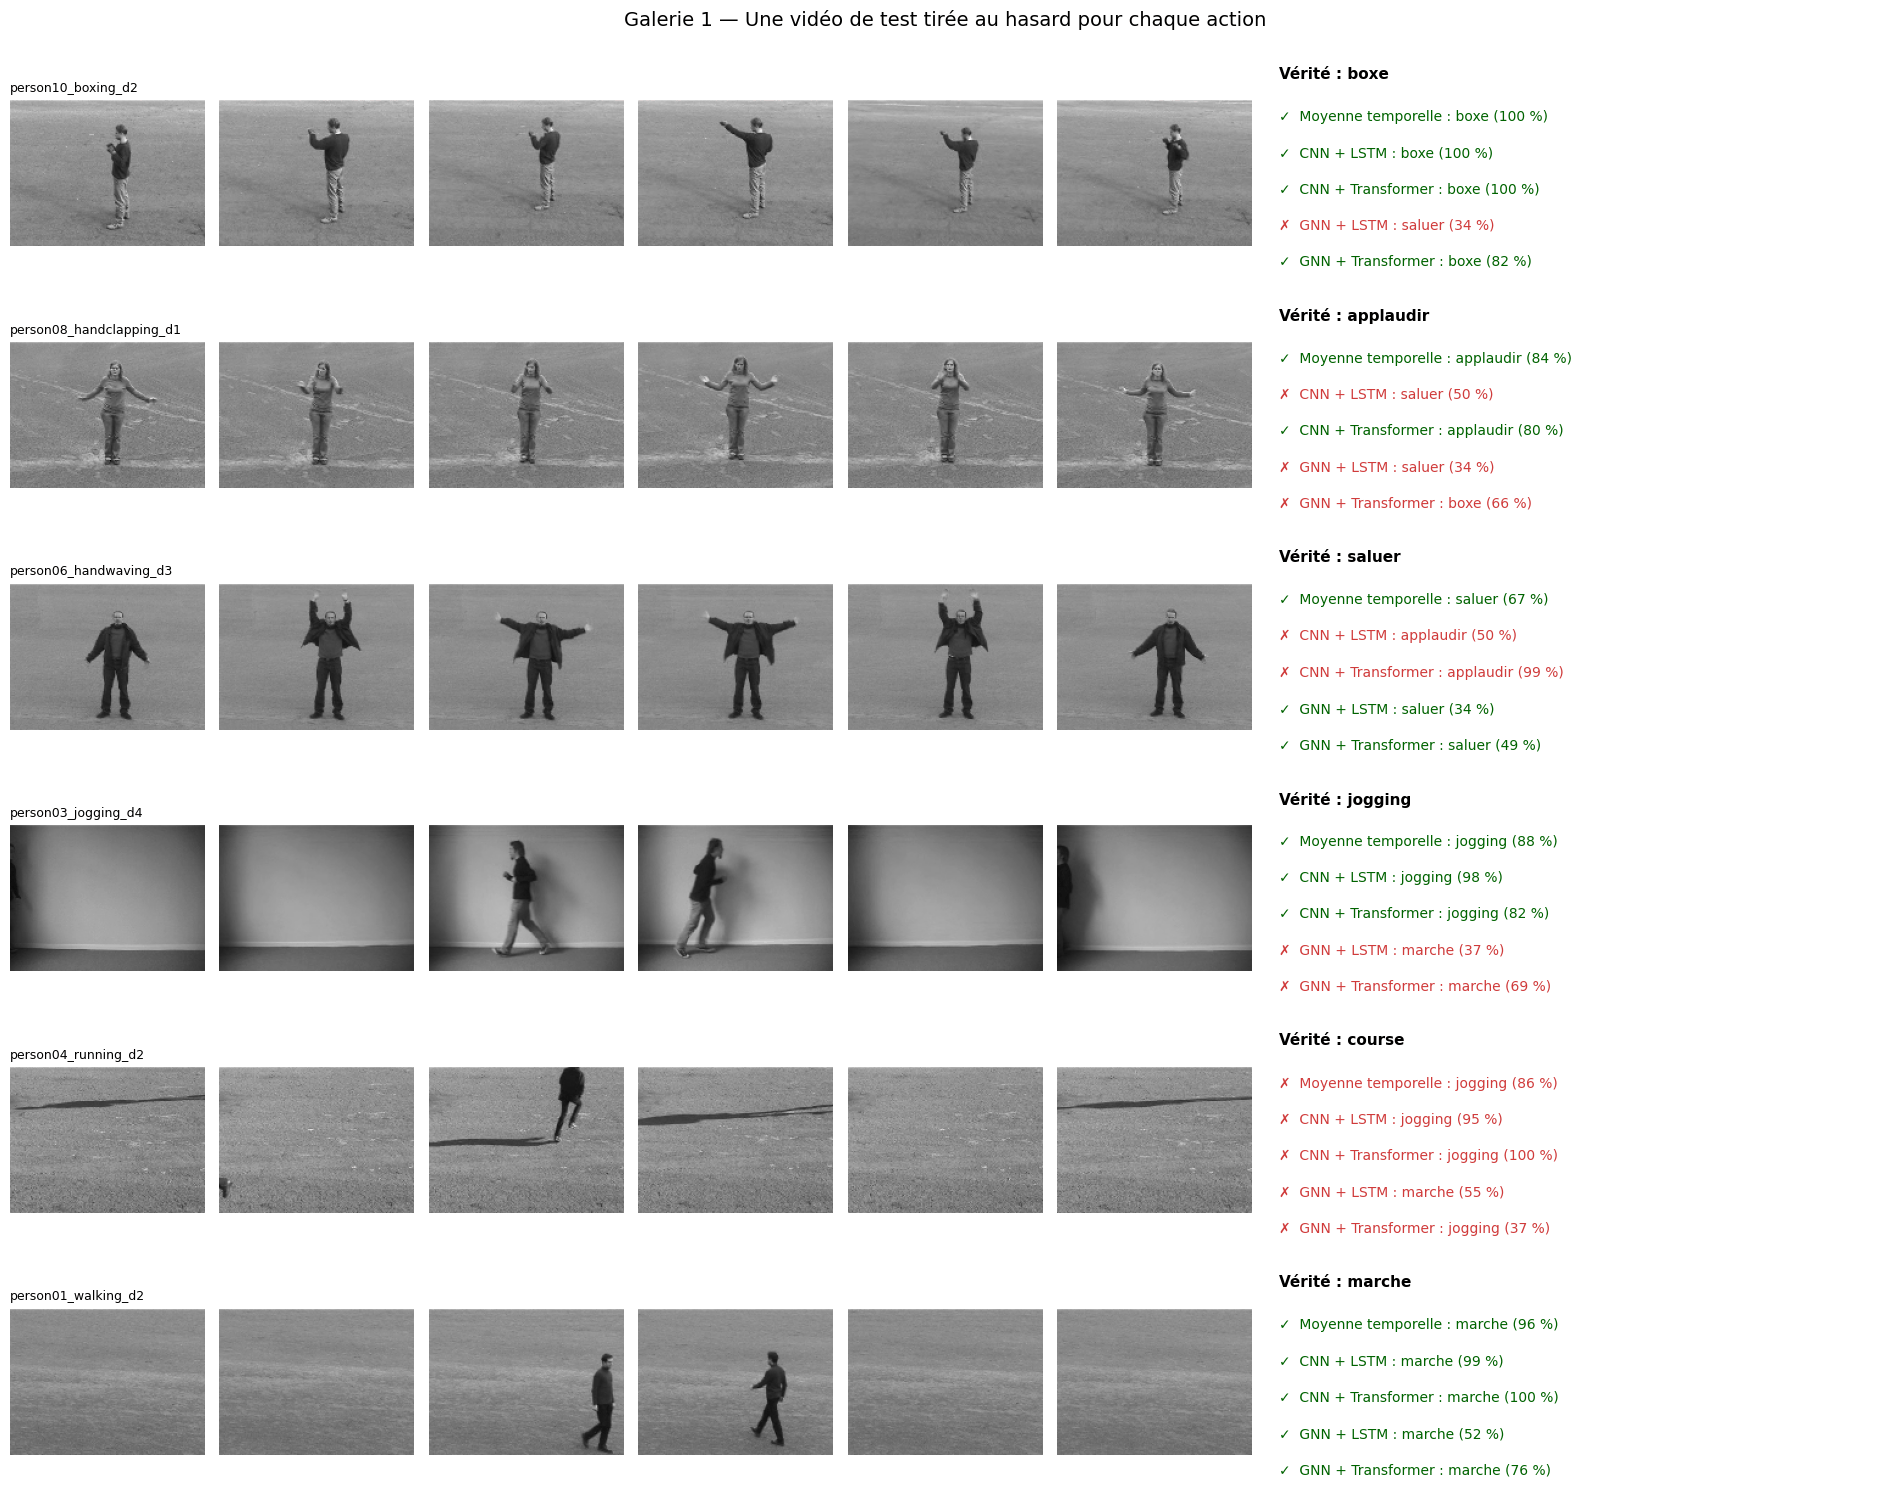

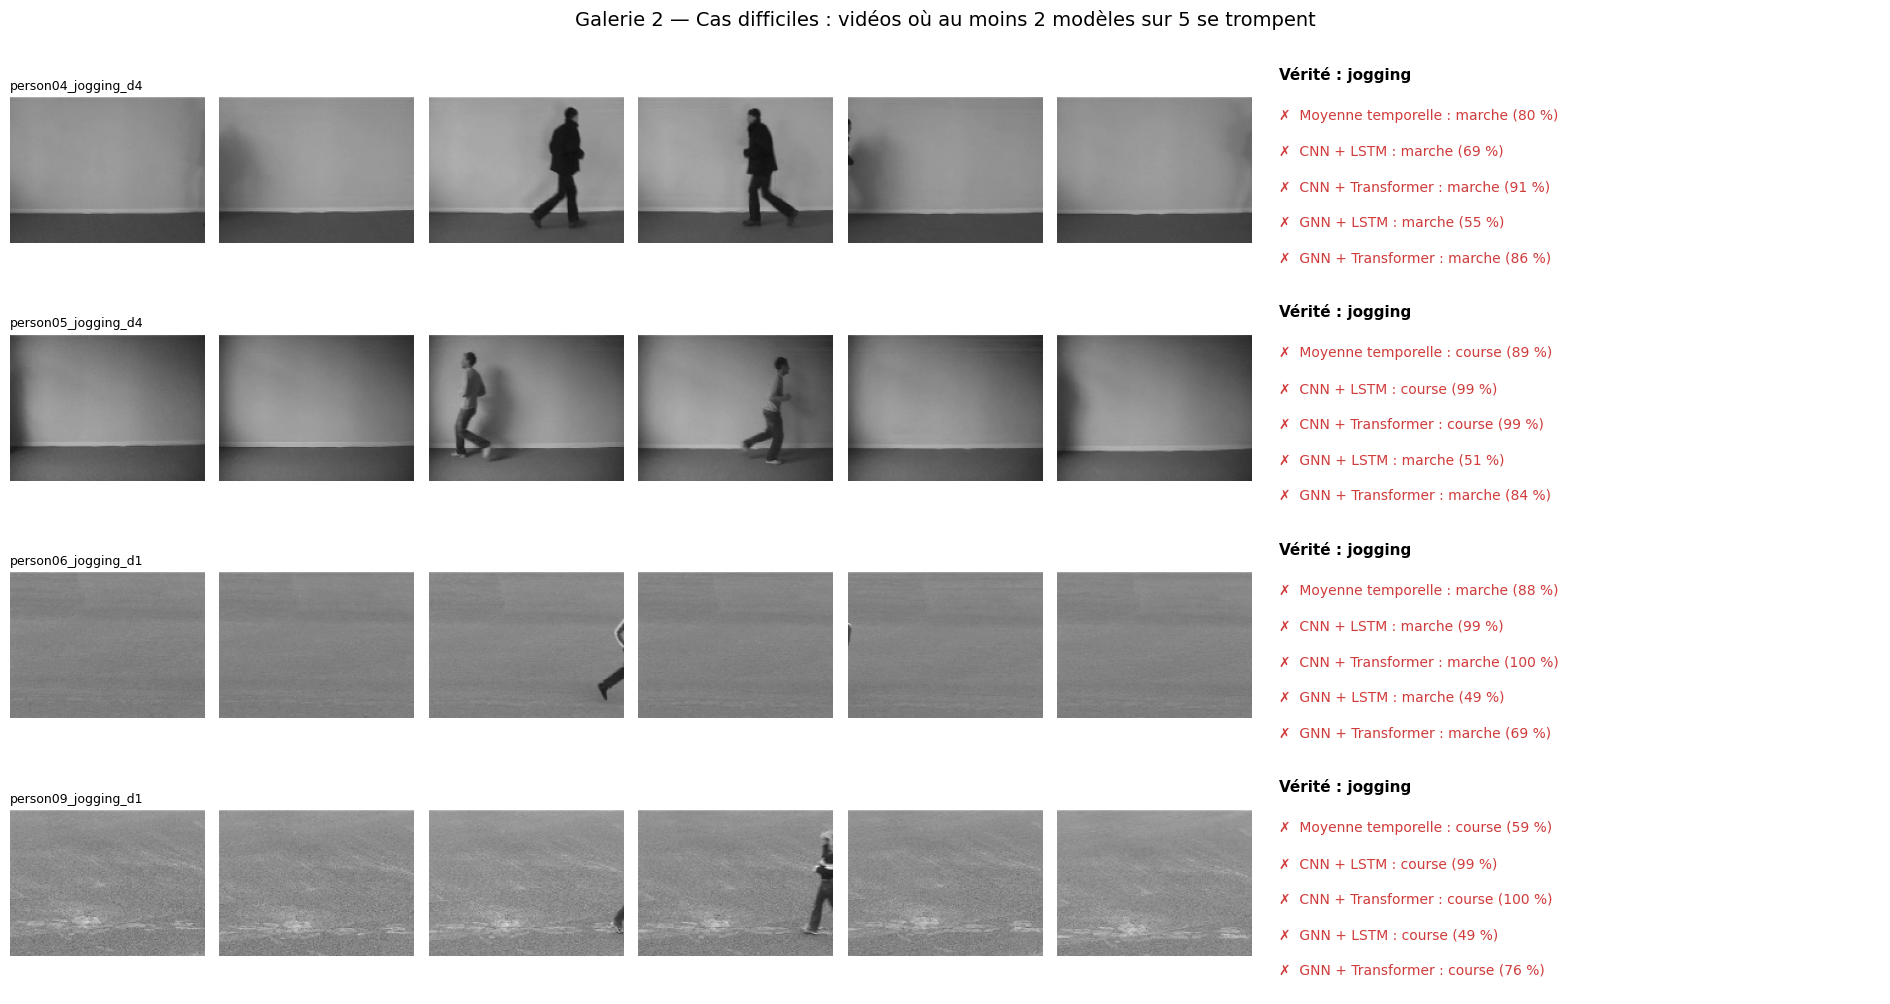

Number of models that are wrong, per test video: {np.int64(0): np.int64(31), np.int64(1): np.int64(102), np.int64(2): np.int64(67), np.int64(3): np.int64(26), np.int64(4): np.int64(25), np.int64(5): np.int64(13)}


In [31]:
####### Gallery of predictions on test videos #######
def show_gallery(indices, plot_title, n_thumbnails=6):
    """One row per video: 6 frames + each model's prediction (green = correct, red = wrong)."""
    fig = plt.figure(figsize=(19, 2.5 * len(indices)))
    gs = fig.add_gridspec(len(indices), n_thumbnails + 3)
    for r, i in enumerate(indices):
        vpath, label, pid = splits['test'][i]
        frames = read_raw_frames(vpath, n_thumbnails)
        for c in range(n_thumbnails):
            ax = fig.add_subplot(gs[r, c])
            ax.imshow(frames[c]); ax.axis('off')
            if c == 0:
                ax.set_title(os.path.basename(vpath).replace('_uncomp.avi', ''), fontsize=9, loc='left')
        ax = fig.add_subplot(gs[r, n_thumbnails:])
        ax.axis('off')
        ax.text(0.02, 0.97, f"Ground truth: {DISPLAY_NAMES[CLASSES[label]]}", fontsize=11, fontweight='bold', va='top', transform=ax.transAxes)
        for k, (name, res) in enumerate(results.items()):
            p = res['probas'][i]
            pred = int(p.argmax())
            is_correct = pred == label
            ax.text(0.02, 0.78 - 0.16 * k, f"{'✓' if is_correct else '✗'}  {name} : {DISPLAY_NAMES[CLASSES[pred]]} ({p[pred] * 100:.0f} %)",
                    fontsize=10, va='top', color='#006300' if is_correct else '#d03b3b', transform=ax.transAxes)
    plt.suptitle(plot_title, fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

y_test = results["Temporal mean"]['targets']
rng_gallery = np.random.default_rng(0)
examples_per_action = [int(rng_gallery.choice(np.where(y_test == c)[0])) for c in range(len(CLASSES))]
show_gallery(examples_per_action, "Gallery 1 — One randomly drawn test video per action")

# Hard cases: videos where at least 2 of the 5 models are wrong
n_errors = np.sum([res['preds'] != y_test for res in results.values()], axis=0)
hard_cases = [int(i) for i in np.argsort(-n_errors, kind='stable') if n_errors[i] >= 2][:4]
if hard_cases:
    show_gallery(hard_cases, "Gallery 2 — Hard cases: videos where at least 2 of the 5 models are wrong")
else:
    print("No test video is misclassified by at least 2 models.")
print("Number of models that are wrong, per test video:", dict(zip(*np.unique(n_errors, return_counts=True))))

**How to read the gallery:** each row is a test video, with 6 frames spread over its whole duration. On the right is each model's prediction with its probability, in green if correct, in red otherwise.
- The **hard cases** (gallery 2) are the videos where at least two models are wrong. Look at the frames: is the person small, blurry, partly out of frame? Is the movement ambiguous (fast jogging, slow running)?
- A correct prediction with a **low probability** (e.g. 40 %) indicates a hesitant model.
- The last printed line gives, for each number of wrong models (0 to 5), the number of videos concerned.

### Example: what does the Transformer look at?
In our Transformers, the **[CLS]** token decides the class. Its row in the attention matrix shows **how much attention it gives to each frame**. Here we extract the **real attention weights** of the last layer, averaged over the 4 heads. To do so, we recompute the encoder layer by layer with `need_weights=True`, then **check** that this recomputation gives back exactly the model's output.

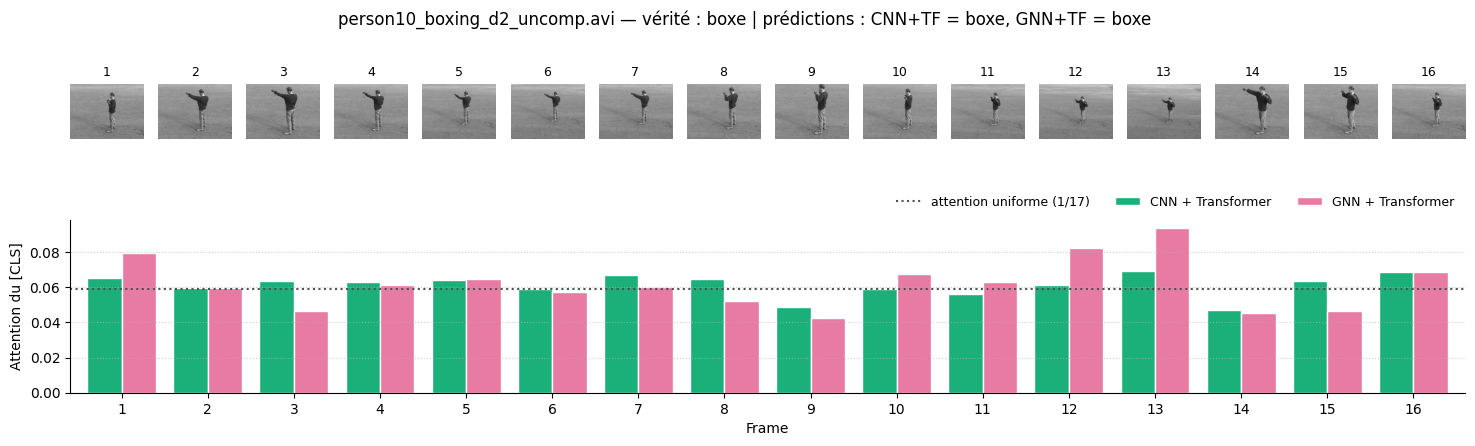

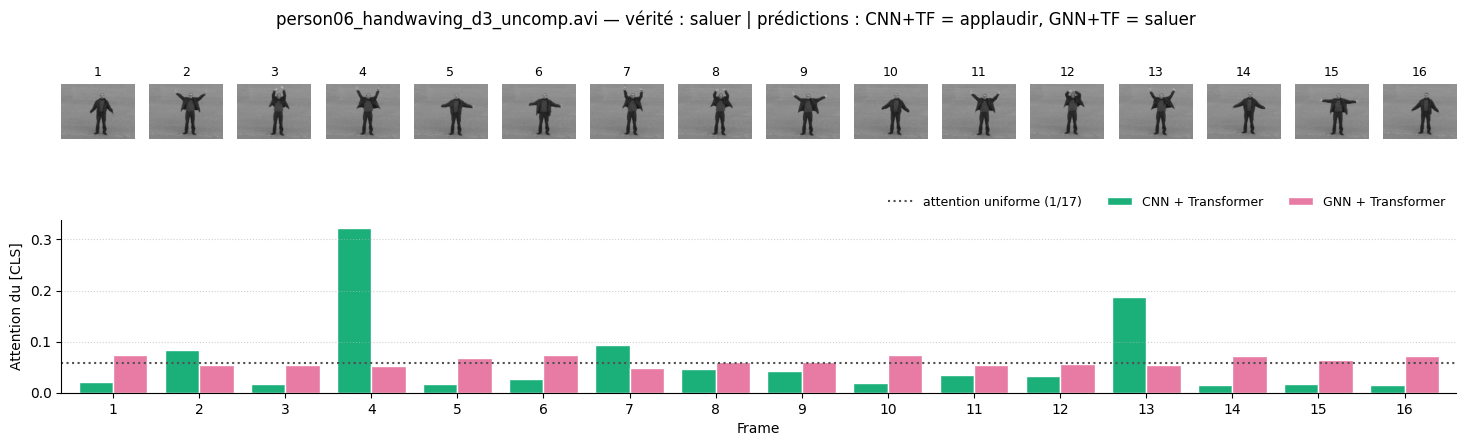

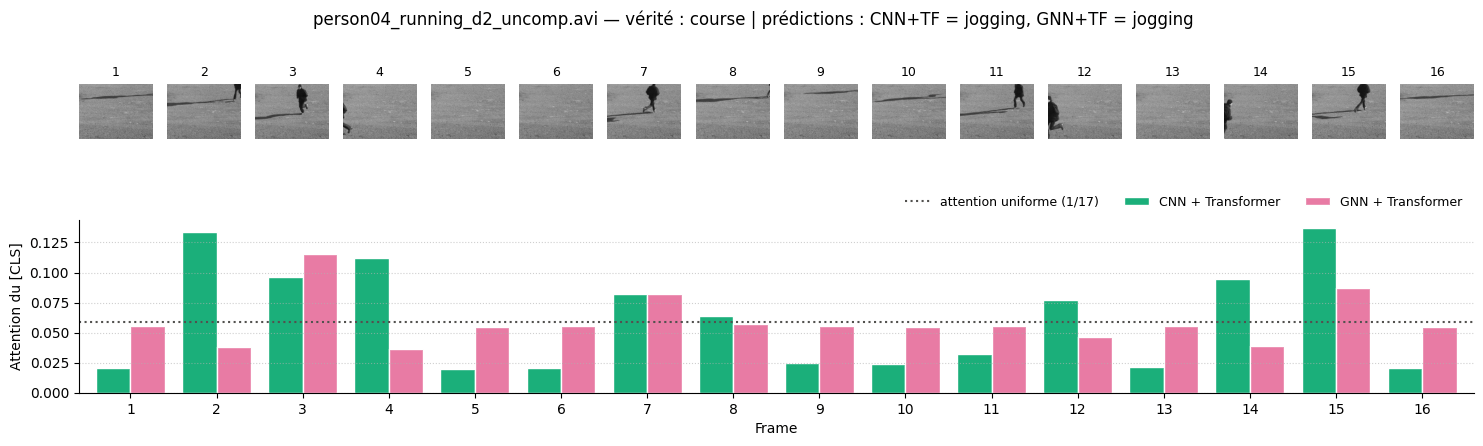

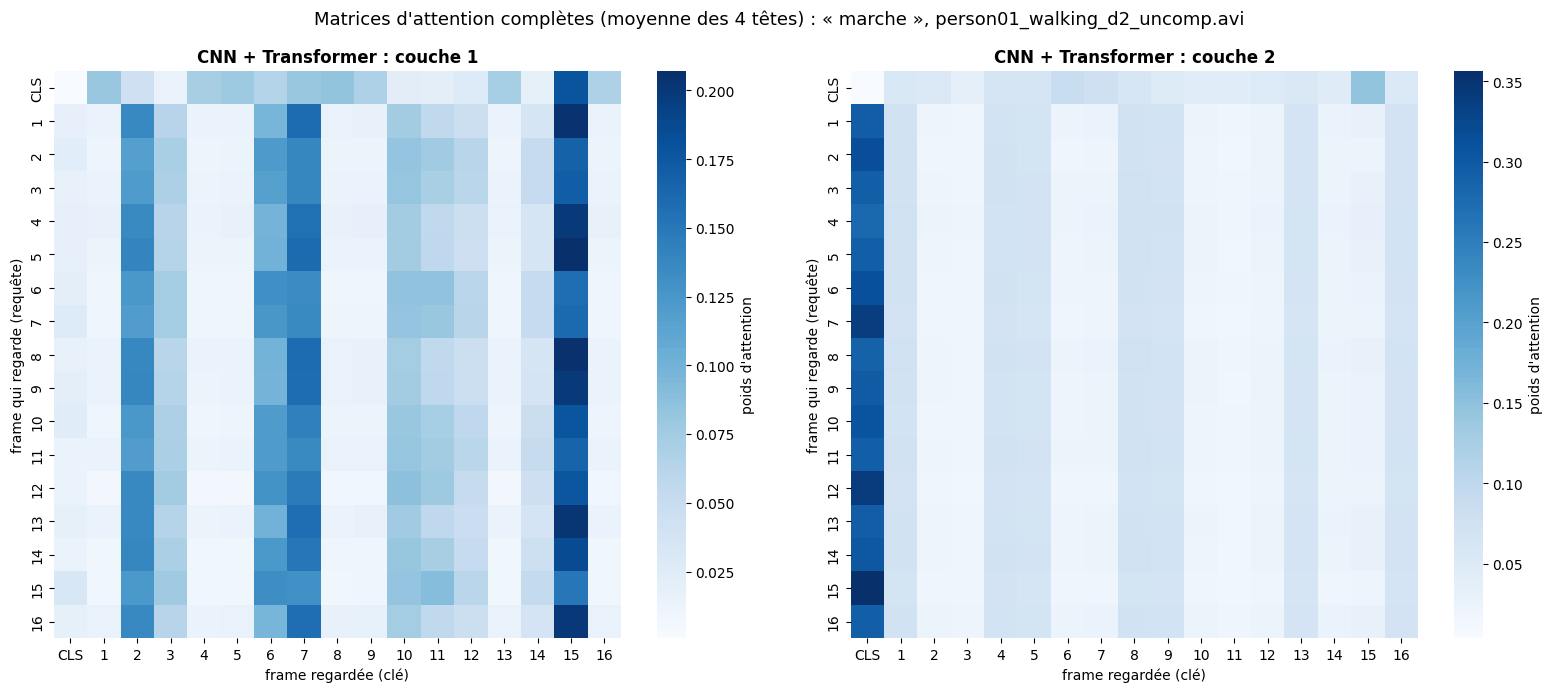

In [32]:
####### REAL attention maps of the two Transformers #######
@torch.no_grad()
def attention_maps(model, h_seq):
    """
    h_seq: frame vectors (B, T, d_model), output by model.sequence_frames.
    Returns the attention weights of each layer, averaged over heads: (B, n_layers, T+1, T+1).
    """
    model.eval()
    B, T, _ = h_seq.shape
    h = torch.cat((model.cls_token.expand(B, -1, -1), h_seq), dim=1) + model.pos_embeddings[:, :T + 1, :]
    inp = h
    maps = []
    for layer in model.transformer_encoder.layers:
        _, wts = layer.self_attn(h, h, h, need_weights=True, average_attn_weights=True)
        maps.append(wts)
        h = layer(h)
    # Check: recomputing layer by layer gives back the output of the full encoder
    assert torch.allclose(h, model.transformer_encoder(inp), atol=1e-4), "Inconsistent attention recomputation"
    return torch.stack(maps, dim=1)

@torch.no_grad()
def show_attention(i):
    vpath, label, _ = splits['test'][i]
    frames = read_raw_frames(vpath, MAX_FRAMES)[IDX_16]
    x_cnn = dataset_features['test']['features'][i:i + 1, IDX_16].to(device)
    x_gnn = skeleton_data['test']['skeletons'][i:i + 1, IDX_16].to(device)
    att_cnn = attention_maps(model_tf, model_tf.sequence_frames(x_cnn))[0, -1, 0, 1:].cpu().numpy()
    att_gnn = attention_maps(gnn_tf_model, gnn_tf_model.sequence_frames(x_gnn))[0, -1, 0, 1:].cpu().numpy()

    fig = plt.figure(figsize=(18, 4.4))
    gs = fig.add_gridspec(2, 16, height_ratios=[1, 1.5], hspace=0.35)
    for t in range(16):
        ax = fig.add_subplot(gs[0, t])
        ax.imshow(frames[t]); ax.axis('off')
        ax.set_title(str(t + 1), fontsize=9)
    ax = fig.add_subplot(gs[1, :])
    pos = np.arange(1, 17)
    ax.bar(pos - 0.2, att_cnn, width=0.4, color=MODEL_COLORS["CNN + Transformer"], edgecolor='white', linewidth=1,
           label="CNN + Transformer")
    ax.bar(pos + 0.2, att_gnn, width=0.4, color=MODEL_COLORS["GNN + Transformer"], edgecolor='white', linewidth=1,
           label="GNN + Transformer")
    ax.axhline(1 / 17, color='#52514e', ls=':', lw=1.5, label="attention uniforme (1/17)")
    ax.set_xticks(pos); ax.set_xlim(0.4, 16.6)
    ax.set_xlabel("Frame"); ax.set_ylabel("[CLS] attention")
    ax.grid(True, axis='y')
    ax.legend(loc='lower right', bbox_to_anchor=(1.0, 1.0), ncol=3, fontsize=9, frameon=False)
    preds = {name: DISPLAY_NAMES[CLASSES[results[name]['preds'][i]]] for name in ["CNN + Transformer", "GNN + Transformer"]}
    fig.suptitle(f"{os.path.basename(vpath)} — ground truth: {DISPLAY_NAMES[CLASSES[label]]} | "
                 f"predictions: CNN+TF = {preds['CNN + Transformer']}, GNN+TF = {preds['GNN + Transformer']}", fontsize=12)
    plt.show()

for cls in ["boxing", "handwaving", "running"]:
    show_attention(examples_per_action[CLASS_TO_IDX[cls]])

# Full attention matrix (last layer) for one video: who attends to whom?
i_demo = examples_per_action[CLASS_TO_IDX["walking"]]
att = attention_maps(model_tf, model_tf.sequence_frames(dataset_features['test']['features'][i_demo:i_demo + 1, IDX_16].to(device)))
token_names = ["CLS"] + [str(t) for t in range(1, 17)]
fig, axes = plt.subplots(1, att.shape[1], figsize=(8 * att.shape[1], 6.5))
for l, ax in enumerate(np.atleast_1d(axes)):
    sns.heatmap(att[0, l].cpu().numpy(), ax=ax, cmap='Blues', square=True, xticklabels=token_names, yticklabels=token_names,
                cbar_kws={'label': "attention weight"})
    ax.set_title(f"CNN + Transformer : layer {l + 1}", fontsize=12, fontweight='bold')
    ax.set_xlabel("attended frame (key)"); ax.set_ylabel("attending frame (query)")
plt.suptitle(f"Full attention matrices (mean of the 4 heads): \"{DISPLAY_NAMES['walking']}\", {os.path.basename(splits['test'][i_demo][0])}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation, with caution:**
- **Uniform** attention (≈ 1/17 per frame, dotted line) means the model is roughly averaging, like model #1.
- **Peaks** indicate favored frames. On the running example (person04_running_d2, classified as "jogging" by both models), the CNN + Transformer's attention is concentrated on several frames (2 to 4, 7, 12, 14 and 15), well above uniform, and drops to about 0.02 on frames without a person (1, 5, 6, 9, 10, 13, 16): the model seems to **seek out the frames where the runner is visible** rather than follow the motion. Some frames where the runner is visible still receive little attention (frame 11). On the boxing example, attention stays close to uniform.
- The **full matrices** show how frames attend to each other. A diagonal structure would mean each frame focuses on its temporal neighbors, i.e. the model follows the motion. This is **not** what we observe: we see a few **dark columns** (frames that all others consult) and, in layer 2, attention mostly concentrates on the [CLS] column. This is consistent with frames one second apart: there is no continuous motion to follow.
- ⚠️ **Attention is not a full explanation** (Jain & Wallace, 2019): the values later transformed by the MLP, and the previous layers, matter too. See these maps as a **hint** of what the model uses, not as proof.

### Experiment: do the models really use frame order?
We re-evaluate the 5 models, **without retraining them**, on test videos modified in two ways:
- **reversed**: frames in reverse order;
- **shuffled**: frames in random order (average over 5 shuffles).

Theoretical prediction: the **temporal mean** gives *exactly* the same result, since a mean does not depend on order. If a sequential model loses a lot of accuracy, it really **exploits** temporal order.

,Normal order,Reversed,Shuffled frames
Model,,,
Temporal mean,78.79,78.79,78.79
CNN + LSTM,65.15,64.02,53.94
CNN + Transformer,80.68,80.68,80.91
GNN + LSTM,40.53,37.88,36.89
GNN + Transformer,53.41,53.03,53.41


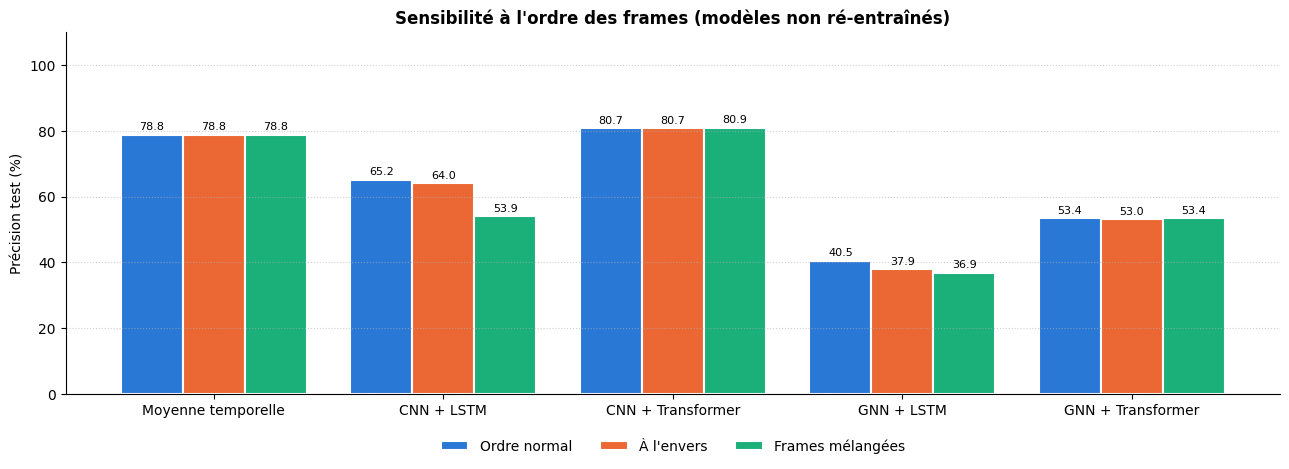

In [33]:
####### Experiment: reversed video and shuffled frames #######
X_test = {'cnn': dataset_features['test']['features'][:, IDX_16],
          'gnn': skeleton_data['test']['skeletons'][:, IDX_16]}
y_test_tensor = dataset_features['test']['labels']

def accuracy_with_order(model, X, order):
    loader = DataLoader(TensorDataset(X[:, order], y_test_tensor), batch_size=64)
    probas, y = predict(model, loader)
    return accuracy_score(y, probas.argmax(axis=1)) * 100

rng_order = np.random.default_rng(0)
shuffles = [rng_order.permutation(16) for _ in range(5)]
order_rows = []
for name, m in final_models.items():
    X = X_test[m['inp']]
    order_rows.append({'Model': name,
                         'Normal order': accuracy_with_order(m['model'], X, np.arange(16)),
                         'Reversed': accuracy_with_order(m['model'], X, np.arange(16)[::-1].copy()),
                         'Shuffled frames': np.mean([accuracy_with_order(m['model'], X, p) for p in shuffles])})
df_order = pd.DataFrame(order_rows).set_index('Model')
display(df_order.round(2))

fig, ax = plt.subplots(figsize=(13, 4.8))
x = np.arange(len(df_order))
for k, column in enumerate(df_order.columns):
    bars = ax.bar(x + (k - 1) * 0.27, df_order[column], width=0.27, color=PALETTE[k],
                    edgecolor='white', linewidth=1.5, label=column)
    ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(df_order.index)
ax.set_ylabel("Test accuracy (%)"); ax.set_ylim(0, 110)
ax.set_title("Sensitivity to frame order (models not retrained)", fontweight='bold')
ax.grid(True, axis='y')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.09), frameon=False)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Reversed video**: in KTH, a walking video played backwards looks like… someone walking in the other direction! A small drop is therefore normal. A large drop signals a model relying on precise temporal cues, such as the moment the person enters the field of view.
- **Shuffled frames**: the rhythm and continuity of the movement are destroyed. The accuracy drop measures **how much the model depends on order**.
- If an LSTM or a Transformer loses almost nothing, it behaves in practice like an "improved mean": it recognizes the action mostly from appearance. This is not necessarily a flaw on KTH, but it puts the real contribution of temporal modeling into perspective.

**What the reference run shows:**
- the temporal mean gives exactly the same accuracy in all three cases, as expected;
- **only the LSTMs depend on order**: the CNN + LSTM loses 11.2 points when frames are shuffled (65.2 → 53.9) and the GNN + LSTM 3.6 points (40.5 → 36.9); reversed, the loss is 1.1 points for the CNN + LSTM and 2.7 for the GNN + LSTM (single seed);
- **the Transformers are almost insensitive to it** (+0.2 point for the CNN + Transformer, 0.0 for the GNN + Transformer). Despite their positional embeddings, they learned to behave like a **smart weighted average**: they select informative frames (see the attention maps) regardless of their order. This is consistent with their lead over the LSTMs, since order carries little exploitable information with frames one second apart (hypothesis, not tested in isolation).

### Demo: predicting the action of a video
The `predict_video(video_file)` function applies **the whole pipeline** to a video file:
read 32 frames → MobileNetV2 (for the CNNs) and pose estimation (for the GNNs) → select 16 frames → the 5 models → probabilities for each action.

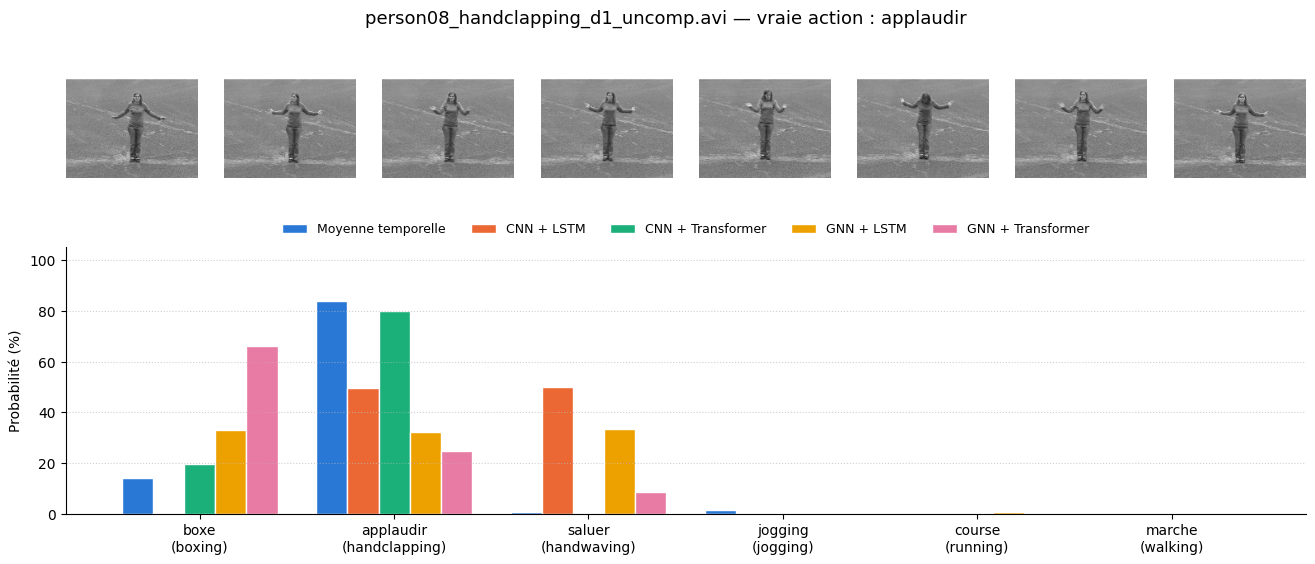

,Temporal mean,CNN + LSTM,CNN + Transformer,GNN + LSTM,GNN + Transformer
boxing,14.100000,0.500000,19.700001,33.000000,66.199997
hand clapping,83.599998,49.500000,80.000000,32.299999,24.799999
hand waving,0.700000,49.900002,0.200000,33.599998,8.600000
jogging,1.400000,0.000000,0.000000,0.200000,0.100000
running,0.000000,0.000000,0.000000,0.700000,0.100000
walking,0.100000,0.000000,0.000000,0.300000,0.200000


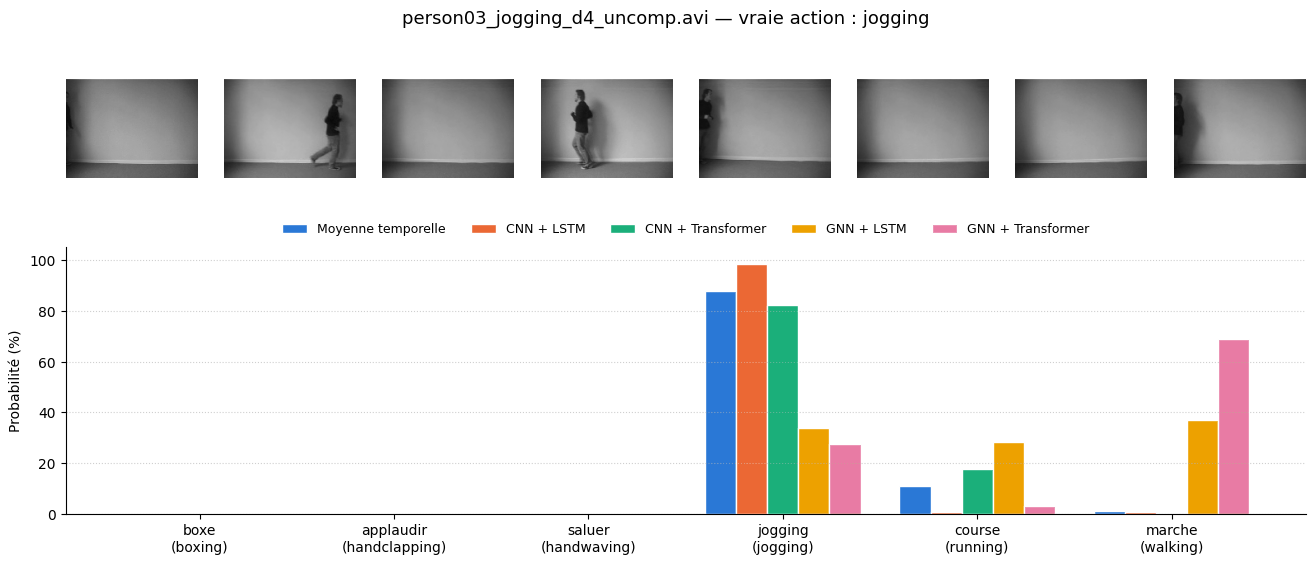

,Temporal mean,CNN + LSTM,CNN + Transformer,GNN + LSTM,GNN + Transformer
boxing,0.000000,0.000000,0.000000,0.300000,0.2
hand clapping,0.000000,0.000000,0.000000,0.300000,0.1
hand waving,0.000000,0.000000,0.000000,0.200000,0.2
jogging,87.599998,98.300003,82.300003,33.700001,27.6
running,11.200000,0.800000,17.600000,28.500000,3.0
walking,1.100000,0.900000,0.100000,37.000000,69.0


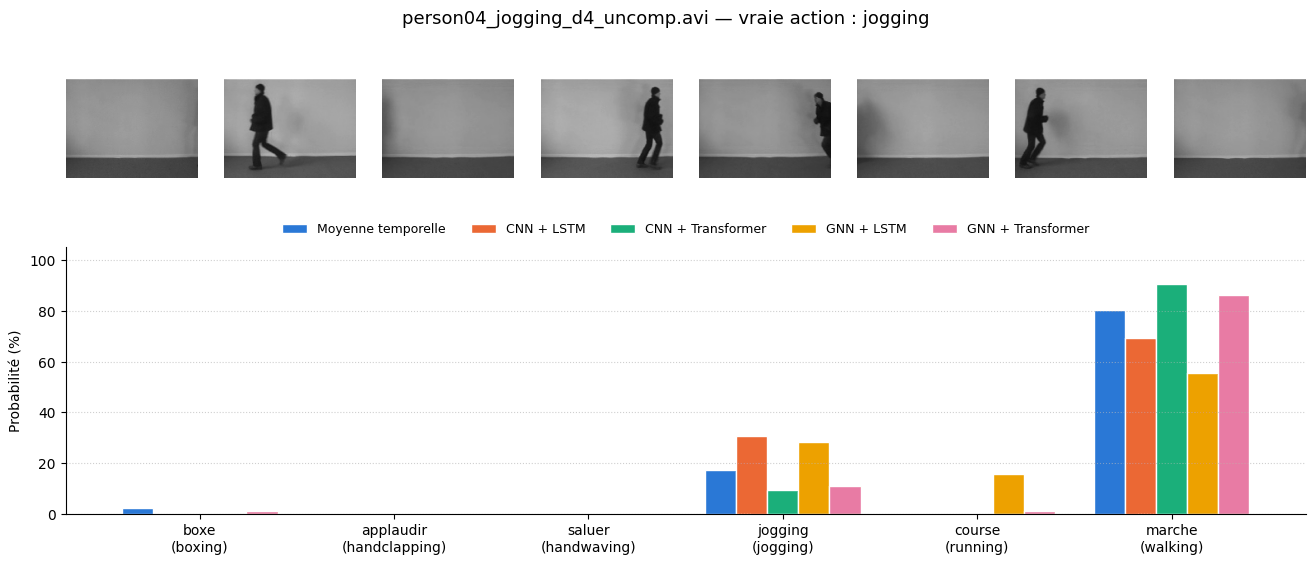

,Temporal mean,CNN + LSTM,CNN + Transformer,GNN + LSTM,GNN + Transformer
boxing,2.300000,0.100000,0.1,0.200000,1.000000
hand clapping,0.000000,0.000000,0.0,0.200000,0.200000
hand waving,0.000000,0.000000,0.0,0.200000,0.300000
jogging,17.500000,30.700001,9.4,28.200001,11.200000
running,0.000000,0.100000,0.0,15.700000,1.200000
walking,80.199997,69.099998,90.5,55.500000,86.099998


In [34]:
####### Demo: the full pipeline on any video #######
@torch.no_grad()
def predict_video(video_file):
    """Predicts the action of a video file with the 5 models and displays the probabilities."""
    frames32 = read_raw_frames(video_file, MAX_FRAMES)
    x_images = torch.stack([imagenet_transform(f) for f in frames32]).to(device)
    inputs = {'cnn': extractor(x_images)[IDX_16].unsqueeze(0),                                   # (1, 16, 1280)
               'gnn': torch.from_numpy(extract_skeletons(frames32))[IDX_16].unsqueeze(0).to(device)}  # (1, 16, 17, 3)
    probas = {name: F.softmax(m['model'](inputs[m['inp']]), dim=1)[0].cpu().numpy()
              for name, m in final_models.items()}

    filename = os.path.basename(video_file)
    truth = next((c for c in CLASSES if f"_{c}_" in filename), None)   # only known for a KTH file
    fig = plt.figure(figsize=(16, 5.8))
    gs = fig.add_gridspec(2, 8, height_ratios=[1, 2.2], hspace=0.3)
    for k, t in enumerate(np.linspace(0, MAX_FRAMES - 1, 8, dtype=int)):
        ax = fig.add_subplot(gs[0, k]); ax.imshow(frames32[t]); ax.axis('off')
    ax = fig.add_subplot(gs[1, :])
    x = np.arange(len(CLASSES))
    bar_width = 0.16
    for k, (name, p) in enumerate(probas.items()):
        ax.bar(x + (k - 2) * bar_width, p * 100, width=bar_width, color=MODEL_COLORS[name], edgecolor='white',
               linewidth=1, label=name)
    ax.set_xticks(x); ax.set_xticklabels([DISPLAY_NAMES[c] for c in CLASSES])
    ax.set_ylabel("Probability (%)"); ax.set_ylim(0, 105)
    ax.grid(True, axis='y')
    ax.legend(ncol=5, fontsize=9, loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=False)
    fig.suptitle(f"{filename}" + (f" — true action: {DISPLAY_NAMES[truth]}" if truth else ""), fontsize=13)
    plt.show()
    return pd.DataFrame(probas, index=[DISPLAY_NAMES[c] for c in CLASSES]).mul(100).round(1)

# Examples on three test videos: an arm action, a locomotion action, and a hard case if there is one
indices_demo = [examples_per_action[CLASS_TO_IDX["handclapping"]], examples_per_action[CLASS_TO_IDX["jogging"]]]
if hard_cases:
    indices_demo.append(hard_cases[0])
for i in indices_demo:
    display(predict_video(splits['test'][i][0]))

# --- Test YOUR own video in Google Colab: uncomment the 3 lines below ---
# from google.colab import files
# uploaded_file = files.upload()               # choose an .mp4 or .avi file
# display(predict_video(next(iter(uploaded_file))))

**Test your own video:** in Google Colab, uncomment the last three lines of the cell above to upload an `.mp4` or `.avi` file.

⚠️ The models have **only seen KTH**: a single person, filmed from afar, static camera, uniform background, grayscale. On a phone video (color, moving camera, several people, tight framing), expect errors. This is a good example of **domain shift**: a model is only reliable on data resembling its training data.

---
# Part 8: Summary and conclusions

The next cell summarizes **your** results and automatically computes the main gaps. The conclusions that follow are based on these numbers.

In [35]:
####### Summary table and key gaps, computed from YOUR results #######
acc = df_bench['Test accuracy (%)']
params = df_bench['Params (head)']
n_test = len(splits['test'])

print("=" * 78)
print("AUTOMATIC SUMMARY OF THE RESULTS (T = 16)")
print("=" * 78)
if USING_SYNTHETIC_DATA:
    print("⚠️  Results obtained on the SYNTHETIC dataset: they are only valid as a code test.\n")
print(f"Best model                               : {acc.idxmax()} ({acc.max():.2f} %)")
print(f"Gain from time (best sequential CNN - mean) : "
      f"{max(acc['CNN + LSTM'], acc['CNN + Transformer']) - acc['Temporal mean']:+.2f} points")
print(f"Transformer - LSTM (on CNN)              : {acc['CNN + Transformer'] - acc['CNN + LSTM']:+.2f} points")
print(f"Transformer - LSTM (on skeleton)         : {acc['GNN + Transformer'] - acc['GNN + LSTM']:+.2f} points")
print(f"Skeleton - CNN (with Transformer)        : {acc['GNN + Transformer'] - acc['CNN + Transformer']:+.2f} points")
print(f"Size GNN + TF / CNN + TF                 : {params['GNN + Transformer'] / params['CNN + Transformer'] * 100:.0f} % of the parameters")
print(f"Skeleton extraction method               : {SKELETON_METHOD}")
print(f"\nReminder: 1 test video = {100 / n_test:.2f} accuracy point; with a single seed,")
print("a gap of 1 to 2 points between two models is not significant.")
print("=" * 78)
display(df_bench.round({'Head latency (ms)': 2, '16-frame extraction (ms)': 1, 'Test accuracy (%)': 2, 'Macro F1': 4}))

AUTOMATIC SUMMARY OF THE RESULTS (T = 16)
Best model                               : CNN + Transformer (80.68 %)
Gain from time (best sequential CNN - mean) : +1.89 points
Transformer - LSTM (on CNN)              : +15.53 points
Transformer - LSTM (on skeleton)         : +12.88 points
Skeleton - CNN (with Transformer)        : -27.27 points
Size GNN + TF / CNN + TF                 : 20 % of the parameters
Skeleton extraction method               : keypointrcnn

Reminder: 1 test video = 0.38 accuracy point; with a single seed,
a gap of 1 to 2 points between two models is not significant.


,Representation,Params (head),Head latency (ms),16-frame extraction (ms),Test accuracy (%),Macro F1
Model,,,,,,
Temporal mean,CNN (pixels),362118,0.24,17.0,78.79,0.7917
CNN + LSTM,CNN (pixels),1414790,1.18,17.0,65.15,0.6408
CNN + Transformer,CNN (pixels),1433222,1.08,17.0,80.68,0.8074
GNN + LSTM,Skeleton (graph),244742,0.81,484.2,40.53,0.2745
GNN + Transformer,Skeleton (graph),291014,1.27,484.2,53.41,0.5028


### Key takeaways (reference run)
1. **How the video is sampled matters as much as the model.** Spreading 16 frames over the whole video (≈ 18 s) gives about one frame per second, many of them empty for locomotion actions. Under these conditions, **temporal modeling brings little**: the best model (Transformer, 80.7 %) beats the simple frame average (78.8 %) by only 1.9 points, a non-significant gap with a single seed.
2. **Transformer > LSTM**, by 15.5 points on CNN and 12.9 points on skeleton, at comparable size. But the shuffling experiment shows that the Transformer **does not use frame order**: it wins because it can *select* informative frames, not because it follows the motion.
3. **CNN > skeleton** by 25 to 27 points here (LSTM −24.6; Transformer −27.3; single seed: the GNN + LSTM gave 45.5 % then 40.5 % across two runs). The skeleton is compact (51 values per frame, heads 5 to 6 times smaller) and insensitive to the background, but on KTH people are small and often out of frame, the pose estimator is expensive, and our GNN struggles to tell joints apart. Skeleton-based methods dominate on datasets such as NTU RGB+D, where skeletons come from a depth sensor (Kinect) and are reliable.
4. **More frames help**, mostly because there is a better chance of seeing the person: ≈ +11 to +12.5 points from $T = 4$ to $T = 16$. Beyond that, the mean gains another 1.5 points, the Transformer 3 points and the LSTM 9.9 points.
5. **The pretrained CNN may encode the background first**: the first PCA component might separate indoors from outdoors rather than the actions (hypothesis checked with the scenario-colored PCA added in part 2).
6. **Confusions stay within a family**: walking / jogging / running on one side, clapping / waving on the other. Boxing is almost always recognized.

### Limitations of this study
- **A single seed** per configuration: solid conclusions would require averaging over 3 to 5 seeds and reporting standard deviations.
- **Small dataset**: 191 training videos, and one test video is worth about 0.4 accuracy point. Part 4 showed that simply changing the number of epochs (30 instead of 35) can move a result by 1.9 points.
- **Sparse sampling**: 16 frames spread over ≈ 18 s cannot track motion. The "time vs appearance" conclusions hold for **this** protocol, not for action recognition in general.
- **Frozen CNN**: MobileNetV2 is not adapted to KTH videos; *fine-tuning* or a video (3D) CNN would do better.
- **Pose estimation**: the quality of the skeletons, and therefore of the GNNs, depends on the estimator. In *silhouette* mode (no GPU), GNN results do not reflect the real potential of skeletons.

### Related work
- **ST-GCN** (*Yan et al., AAAI 2018*): the seminal architecture, combining spatial graph convolutions on the skeleton with temporal convolutions.
- **2s-AGCN and CTR-GCN** (*Shi et al., CVPR 2019; Chen et al., ICCV 2021*): the skeleton graph becomes **learned** (adaptive topology) instead of being hand-defined as here.
- **Video Transformers** (*TimeSformer, Bertasius et al., ICML 2021; VideoMAE, Tong et al., NeurIPS 2022*): attention is applied both in space (image patches) and in time, directly on pixels.

### Future work
1. **Dense sampling**: instead of spreading frames over the whole video, take 16 **consecutive** frames (one out of two) around the moment with the most motion (see the motion energy in part 1). Do the temporal models then beat the mean? *(explored in part 11)*
2. Re-run training with 3 different seeds and plot mean ± standard deviation. *(done in part 9)*
3. Give the GNN the **identity of the joints**: add a learned embedding per joint, or concatenate the 17 joints instead of averaging them.
4. Give the GNN the joint **velocities** ($x_t - x_{t-1}$) in addition to their positions.
5. Add a learning-rate *warm-up* phase for the Transformers, then compare.
6. Crop each frame around the detected person before MobileNetV2, to reduce the influence of the background.
7. *Fine-tune* the last layers of MobileNetV2 and measure the gain.

> **Update with 10 seeds (part 9).** Takeaway 2 should be nuanced: the Transformer's advantage over the LSTM is **+11.0 points [+7.0; +15.2] at $T = 16$** (not +15.5), and +4.3 [−1.0; +10.2] at $T = 32$, hence not established at that length. The finding "the Transformer does not use order", on the other hand, is **confirmed over 10 seeds** (drop of +0.4 ± 0.5 point at $T = 16$ when frames are shuffled, vs −13.8 ± 4.1 for the LSTM). In takeaway 1, the Transformer − mean gap (+1.9 points, non-significant) becomes +0.8 point [−2.8; +4.7] at $T = 16$ and +3.6 [+0.8; +6.1] at $T = 32$. The "single seed" limitation is addressed in part 9 for the CNN heads (skeleton models remain single-seed).

---
# Part 9: Extension — statistical robustness (multiple seeds and per-person bootstrap)

> Extension added after the main study: parts 0 to 8 are unchanged. It addresses the limitation flagged in part 8: **a single seed per configuration**, with gaps of 1 to 2 points that are not significant. It only covers the CNN heads: skeleton models are not retrained and remain single-seed.

**What this part does**
1. Retrains each head on $T \in \{4, 8, 16, 32\}$ with **multiple seeds** and reports mean ± standard deviation.
2. Adds a control, the **raw mean**: CNN features are averaged *before* any projection. The "temporal mean" of part 3 already applies a non-linear projection to **each frame** before averaging; comparing the two isolates the effect of this per-frame non-linearity.
3. Repeats the **frame-shuffling test** over all seeds (part 7 only did it on a single model per architecture).
4. Computes **95 % confidence intervals by bootstrapping over the test persons**. The independent unit is the *person* (11 in the test set), not the video: videos of the same person are correlated.

**Protocol**: same data, same split, same hyperparameters and same training engine as parts 3 and 4, with the best epoch chosen on validation. Only difference: **35 epochs for every $T$** (part 4 used 30), so that results at $T = 16$ are comparable to those of part 3.

In [36]:
####### Extension: configuration, "raw mean" control and utility functions #######
EXT_SEEDS = list(range(10))          # 10 seeds per configuration (more seeds tighten the intervals)
EXT_LENGTHS = [4, 8, 16, 32]
NUM_PERMUTATIONS = 5                    # random permutations per trained model for the shuffle test

class RawMeanPoolClassifier(nn.Module):
    # Control: CNN features are averaged BEFORE the projection (no non-linearity applied frame by frame).
    def __init__(self, in_features=1280, hidden_dim=256, num_classes=6, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_features, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.classifier = nn.Sequential(nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, num_classes))

    def forward(self, x):                      # x : (B, T, 1280)
        pooled = self.proj(torch.mean(x, dim=1))   # average first (B, 1280), then project
        return self.classifier(pooled)

EXT_HEADS = {"Raw mean": RawMeanPoolClassifier,
             "Temporal mean": MeanPoolClassifier,
             "CNN + LSTM": CNNLSTMClassifier,
             "CNN + Transformer": CNNTransformerClassifier}
EXT_COLORS = {**MODEL_COLORS, "Raw mean": PALETTE[5]}

y_test_ext = np.asarray(dataset_features['test']['labels'])
pid_test = np.array([pid for _, _, pid in splits['test']])   # person of each test video, in test loader order
assert len(pid_test) == len(y_test_ext)

def correct_vector(model, X, order=None):
    # Boolean per test video (correctly classified or not), with frames read in the order `order` (default: normal order).
    if order is not None:
        X = X[:, order]
    loader = DataLoader(TensorDataset(X, dataset_features['test']['labels']), batch_size=64)
    probas, y = predict(model, loader)
    return probas.argmax(axis=1) == y

print(f"{len(EXT_SEEDS)} seeds x {len(EXT_HEADS)} heads x {len(EXT_LENGTHS)} lengths = "
      f"{len(EXT_SEEDS) * len(EXT_HEADS) * len(EXT_LENGTHS)} training runs")
print("Trainable parameters:", {n: count_parameters(C()) for n, C in EXT_HEADS.items()})

10 seeds x 4 heads x 4 lengths = 160 training runs
Trainable parameters: {'Raw mean': 362118, 'Temporal mean': 362118, 'CNN + LSTM': 1414790, 'CNN + Transformer': 1433222}


In [37]:
####### Extension: multi-seed training (about ten minutes on GPU; results saved to disk) #######
import pickle
EXT_PATH = os.path.join(os.getcwd(), "resultats_extension.pkl")
expected_keys = {(T, name, g) for T in EXT_LENGTHS for name in EXT_HEADS for g in EXT_SEEDS}

res_ext = None
if os.path.exists(EXT_PATH):
    with open(EXT_PATH, "rb") as f:
        res_ext = pickle.load(f)
    if set(res_ext) != expected_keys:
        print("The results file does not match the current configuration: recomputing.")
        res_ext = None
    else:
        print(f"Results reloaded from {os.path.relpath(EXT_PATH)} ({len(res_ext)} training runs).")

if res_ext is None:
    res_ext = {}                       # (T, head, run_seed) -> {'correct': booleans per test video, 'shuffled': shuffled-frames accuracy}
    rng_perm = np.random.default_rng(123)
    start = time.time()
    for T in EXT_LENGTHS:
        indices = np.linspace(0, MAX_FRAMES - 1, T, dtype=int)
        loaders_T = make_loaders(dataset_features, 'features', seq_len=T, batch_size=32)
        X_test_T = dataset_features['test']['features'][:, indices]
        permutations = [rng_perm.permutation(T) for _ in range(NUM_PERMUTATIONS)]
        for name, ModelClass in EXT_HEADS.items():
            for run_seed in EXT_SEEDS:
                seed_everything(run_seed)
                model = ModelClass().to(device)
                train_model(model, f"{name} (T={T}, run_seed {run_seed})", loaders_T, num_epochs=NUM_EPOCHS, verbose=False)
                res_ext[(T, name, run_seed)] = {
                    'correct': correct_vector(model, X_test_T),
                    'shuffled': float(np.mean([correct_vector(model, X_test_T, p).mean() for p in permutations]))}
        print(f"T = {T:2d} done ({time.time() - start:.0f} s)")
    with open(EXT_PATH, "wb") as f:
        pickle.dump(res_ext, f)
    print(f"Results saved: {os.path.relpath(EXT_PATH)}")

T =  4 done (59 s)
T =  8 done (123 s)
T = 16 done (198 s)
T = 32 done (294 s)
Results saved: extension_results.pkl


### Multi-seed results: test accuracy (%), mean ± standard deviation across seeds
For the conclusions, the table and curve below replace the single-seed numbers of parts 3 and 4. Error bars show the variability due to **initialization** (standard deviation across seeds); they do not account for the choice of test persons, which is handled below by the bootstrap.

Model,Raw mean,Temporal mean,CNN + LSTM,CNN + Transformer
T,,,,
4,63.9 ± 1.1,65.0 ± 1.2,59.8 ± 3.3,63.7 ± 2.6
8,67.2 ± 1.4,70.4 ± 1.0,60.2 ± 3.1,71.6 ± 1.1
16,71.7 ± 1.7,78.8 ± 0.8,68.6 ± 4.0,79.6 ± 1.4
32,73.8 ± 1.6,78.0 ± 2.2,77.3 ± 1.6,81.6 ± 0.6


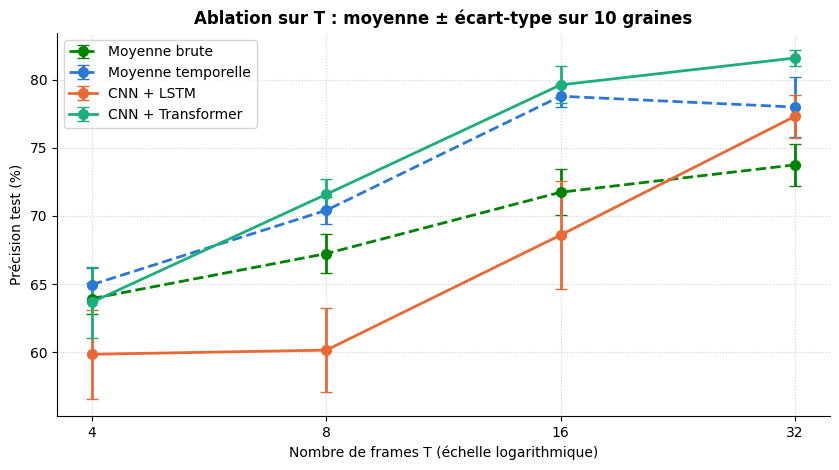

In [38]:
####### Extension: multi-seed ablation table and curve #######
table_rows = [{'T': T, 'Model': name, 'run_seed': g, 'acc': r['correct'].mean() * 100, 'acc_shuffled': r['shuffled'] * 100}
          for (T, name, g), r in res_ext.items()]
df_ext = pd.DataFrame(table_rows)

table_ext = (df_ext.groupby(['T', 'Model'])['acc']
               .agg(lambda s: f"{s.mean():.1f} ± {s.std(ddof=1):.1f}")
               .unstack('Model')[list(EXT_HEADS)])
display(table_ext)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for name in EXT_HEADS:
    d = df_ext[df_ext['Model'] == name].groupby('T')['acc'].agg(['mean', 'std']).reindex(EXT_LENGTHS)
    ax.errorbar(EXT_LENGTHS, d['mean'], yerr=d['std'], marker='o', markersize=7, lw=2, capsize=4,
                ls='--' if name.endswith("mean") else '-', color=EXT_COLORS[name], label=name)
ax.set_xscale('log', base=2); ax.set_xticks(EXT_LENGTHS); ax.set_xticklabels(EXT_LENGTHS)
ax.set_xlabel("Number of frames T (log scale)"); ax.set_ylabel("Test accuracy (%)")
ax.set_title(f"Ablation over T: mean ± std over {len(EXT_SEEDS)} seeds", fontweight='bold')
ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

### Gaps between models: bootstrap confidence intervals over persons
For each draw, we resample **the 11 test persons with replacement**, recompute each seed's accuracy on the videos of the drawn persons, then average over seeds. The 95 % interval is formed by the 2.5 and 97.5 percentiles of the gap (A − B) over 5000 draws. An interval that does not contain 0 indicates a gap that holds when the sample of persons changes; with only 11 persons, it should still be read as an order of magnitude.

In [39]:
####### Extension: bootstrap over test persons #######
def ic_bootstrap(T, name_a, name_b, n_draws=5000, boot_seed=0):
    # Accuracy gap (A - B) in points, averaged over seeds, with a 95 % CI from a bootstrap over the test PERSONS.
    persons = np.unique(pid_test)
    ca = np.stack([res_ext[(T, name_a, g)]['correct'] for g in EXT_SEEDS])      # (seeds, videos)
    cb = np.stack([res_ext[(T, name_b, g)]['correct'] for g in EXT_SEEDS])
    n_vid = np.array([(pid_test == p).sum() for p in persons])                 # videos per person
    Ca = np.stack([ca[:, pid_test == p].sum(axis=1) for p in persons], axis=1) # successes per person: (seeds, persons)
    Cb = np.stack([cb[:, pid_test == p].sum(axis=1) for p in persons], axis=1)
    rng = np.random.default_rng(boot_seed)
    draws = rng.integers(0, len(persons), size=(n_draws, len(persons)))
    wts = np.stack([np.bincount(t, minlength=len(persons)) for t in draws])  # how many times each person is drawn
    total = wts @ n_vid                                                           # videos in each draw
    ecart = ((wts @ Ca.T) / total[:, None] - (wts @ Cb.T) / total[:, None]).mean(axis=1) * 100
    point = (ca.mean() - cb.mean()) * 100
    bottom, top = np.percentile(ecart, [2.5, 97.5])
    return point, bottom, top

COMPARISONS = [("CNN + Transformer", "Temporal mean"),
                ("CNN + Transformer", "CNN + LSTM"),
                ("Temporal mean", "CNN + LSTM"),
                ("Temporal mean", "Raw mean"),
                ("CNN + Transformer", "Raw mean")]
ci_rows = []
for T in [16, 32]:
    for a, b in COMPARISONS:
        point, bottom, top = ic_bootstrap(T, a, b)
        ci_rows.append({'T': T, 'Comparison (A − B)': f"{a} − {b}", 'Gap (pts)': round(point, 1),
                          '95 % CI (pts)': f"[{bottom:+.1f} ; {top:+.1f}]", 'Excludes 0?': "yes" if bottom > 0 or top < 0 else "no"})
display(pd.DataFrame(ci_rows).set_index(['T', 'Comparison (A − B)']))

Gap (pts)   95 % CI (pts)  \
T  Comparison (A − B)                                                   
16 CNN + Transformer − Temporal mean          0.8   [-2.8 ; +4.7]   
   CNN + Transformer − CNN + LSTM                 11.0  [+7.0 ; +15.2]   
   Temporal mean − CNN + LSTM                10.2  [+5.4 ; +15.2]   
   Temporal mean − Raw mean              7.0  [+3.4 ; +10.8]   
   CNN + Transformer − Raw mean               7.9  [+2.5 ; +14.0]   
32 CNN + Transformer − Temporal mean          3.6   [+0.8 ; +6.1]   
   CNN + Transformer − CNN + LSTM                  4.3  [-1.0 ; +10.2]   
   Temporal mean − CNN + LSTM                 0.7   [-3.7 ; +5.5]   
   Temporal mean − Raw mean              4.2   [+1.7 ; +7.0]   
   CNN + Transformer − Raw mean               7.8  [+4.6 ; +12.3]   

                                          Excludes 0?  
T  Comparison (A − B)                                
16 CNN + Transformer − Temporal mean        no  
   CNN + Transformer − CNN + LSTM                yes  
   Temporal mean − CNN + LSTM               yes  
   Temporal mean − Raw mean            yes  
   CNN + Transformer − Raw mean             yes  
32 CNN + Transformer − Temporal mean        yes  
   CNN + Transformer − CNN + LSTM                no  
   Temporal mean − CNN + LSTM               no  
   Temporal mean − Raw mean            yes  
   CNN + Transformer − Raw mean             yes

### Dependence on frame order, over all seeds
Each trained model is evaluated once in normal order, then with shuffled frames (average over 5 random permutations). The drop is computed seed by seed. The temporal mean and the raw mean must lose exactly 0: they do not depend on order, which serves as a sanity check of the code.

In [40]:
####### Extension: frame-shuffle test over all seeds #######
mean_rows = []
for T in [16, 32]:
    for name in EXT_HEADS:
        d = df_ext[(df_ext['T'] == T) & (df_ext['Model'] == name)]
        decrease = d['acc'] - d['acc_shuffled']
        mean_rows.append({'T': T, 'Model': name,
                         'Normal order (%)': f"{d['acc'].mean():.1f} ± {d['acc'].std(ddof=1):.1f}",
                         'Shuffled frames (%)': f"{d['acc_shuffled'].mean():.1f} ± {d['acc_shuffled'].std(ddof=1):.1f}",
                         'Drop (pts)': f"{decrease.mean():+.1f} ± {decrease.std(ddof=1):.1f}"})
display(pd.DataFrame(mean_rows).set_index(['T', 'Model']))

Normal order (%) Shuffled frames (%) Drop (pts)
T  Model                                                               
16 Raw mean            71.7 ± 1.7           71.7 ± 1.7   +0.0 ± 0.0
   Temporal mean       78.8 ± 0.8           78.8 ± 0.8   +0.0 ± 0.0
   CNN + LSTM               68.6 ± 4.0           54.8 ± 5.3  +13.8 ± 4.1
   CNN + Transformer        79.6 ± 1.4           79.2 ± 1.5   +0.4 ± 0.5
32 Raw mean            73.8 ± 1.6           73.8 ± 1.6   +0.0 ± 0.0
   Temporal mean       78.0 ± 2.2           78.0 ± 2.2   +0.0 ± 0.0
   CNN + LSTM               77.3 ± 1.6           70.4 ± 1.3   +6.9 ± 1.1
   CNN + Transformer        81.6 ± 0.6           81.4 ± 0.6   +0.2 ± 0.4

### How to read this part
- **Variability across seeds**: if a model's standard deviation is of the same order as the gap between two models, that gap is not reliable with a single seed (this was the case for the 1-to-2-point gaps of part 3).
- **Bootstrap intervals**: they measure sensitivity to the choice of the 11 test persons. An interval containing 0 does not prove the absence of a gap: it indicates that this experiment cannot conclude.
- **Raw mean vs temporal mean**: if the latter is clearly better, the non-linearity applied to each frame before averaging matters; the temporal mean is then a more demanding baseline than the plain feature average.
- **Shuffle test**: a drop close to 0 shows that the model does not use order; it does not say *why* (appearance is sufficient, sparse sampling, etc.).
- **Limitations**: uncorrected multiple comparisons; identical, untuned hyperparameters for all models; a single person-wise split.

### Extension summary (10 seeds, reference run)

1. **Single-seed numbers were unstable, especially for the LSTM.** At $T = 16$ the LSTM reaches 68.6 ± 4.0 % (a 4-point standard deviation across seeds), vs 0.8 to 1.4 points for the temporal mean and the Transformer. At $T = 32$, standard deviations range from 0.6 to 2.2 points.
2. **Transformer vs LSTM.** The Transformer leads the LSTM by +11.0 points at $T = 16$ (95 % CI [+7.0; +15.2]), a gap that holds when the sample of persons changes. At $T = 32$, the gap drops to +4.3 points with an interval that contains 0 ([−1.0; +10.2]): the LSTM catches up most of its lag between 16 and 32 frames (+8.7 points).
3. **Transformer vs temporal mean.** With 10 seeds, the Transformer's lead is +0.8 point at $T = 16$ (non-significant, [−2.8; +4.7]) and +3.6 points at $T = 32$ ([+0.8; +6.1]). The latter interval barely excludes 0, with 11 test persons and uncorrected multiple comparisons: to be read as a hint, not as proof.
4. **The non-linearity applied to each frame matters.** The temporal mean beats the raw mean by +7.0 points at $T = 16$ ([+3.4; +10.8]) and +4.2 points at $T = 32$ ([+1.7; +7.0]). At $T = 16$, it recovers almost all of the Transformer's advantage over the raw mean (+7.0 out of +7.9); at $T = 32$, about half (+4.2 out of +7.8). These results are consistent with the idea that a good share of the Transformer's lead over a simple mean comes from the per-frame non-linear projection, which it shares with the temporal mean. This is not isolated by a dedicated experiment.
5. **The Transformer does not use frame order, the LSTM does.** When frames are shuffled at test time, the drop is +0.4 ± 0.5 point (Transformer, $T = 16$) and +0.2 ± 0.4 ($T = 32$), vs +13.8 ± 4.1 and +6.9 ± 1.1 points for the LSTM. Both means lose exactly 0, as expected. The Transformer's lead at $T = 32$ therefore does not come from order; the explanation through weighting of informative frames remains a hypothesis.
6. **Limitations.** Only 11 test persons; uncorrected multiple comparisons; identical, untuned hyperparameters for all models; 35 epochs for every $T$; a single person-wise split; skeleton models and the reversed test: single seed. The confidence interval accounts for the choice of persons, and the table's standard deviation for initialization.

---
# Part 10: Second protocol — official KTH split, alternative heads, 11 seeds

This part (and parts 11 to 13) is a second, independent study of the same question, with its execution outputs on Colab. It asks the same question as parts 0 to 9 (*do the temporal heads really exploit time?*) with a different protocol, which makes it possible to check whether the conclusions hold when the protocol changes:

| | Parts 0 to 9 | Parts 10 to 13 (second protocol) |
|---|---|---|
| Split | validation: 19–21, 23–25; test: 1–10, 22 (264 videos) | **official KTH split**: validation: 19–21, 23–25, 1, 4; test: 2, 3, 5–10, 22 (216 videos) |
| Mean | non-linear projection of each frame, then mean | `mean`: mean, then MLP; `frame_mlp_mean`: per-frame MLP, then mean |
| LSTM | 2 layers, mean of hidden states | 1 layer, last hidden state |
| Transformer | `nn.TransformerEncoder` (post-norm), [CLS] token | hand-written blocks (pre-norm), mean over frames, learned or sinusoidal positions |
| Training | AdamW, cosine, 35 epochs, best validation accuracy | AdamW (wd $10^{-2}$), ReduceLROnPlateau, early stopping on validation loss (≤ 100 epochs), standardized features |
| Seeds | 1 (parts 3 and 4), 10 (part 9) | 11 |
| Cache | `./cached_features` | Drive: `MyDrive/MP4_KTH` |

The test videos are not the same: **the accuracies of the two protocols cannot be compared directly**, only the trends can (part 14). In parts 10 to 13, "section N" refers to the "B · N" sections below.

## B · 0. Configuration

In [41]:
import glob as glob_module
import os, re, time, copy, math, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from IPython.display import display

CLASSES = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
N_FRAMES = 32                  # frames extracted per video (then subsampled for 4/8/16)
T_LIST   = [4, 8, 16, 32]      # sequence length ablation
SEEDS    = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
EPOCHS, PATIENCE, BATCH, MAX_GRAD_NORM = 100, 15, 32, 5.0
SHUFFLE_T = 32                 # length used for the shuffle test and the confusion matrices (must be in T_LIST)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cu130 | device: cuda


In [42]:
# Working folders (Drive on Colab, local folder otherwise)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK_DIR = "/content/drive/MyDrive/MP4_KTH"
except ImportError:
    WORK_DIR = "./MP4_KTH"
os.makedirs(WORK_DIR, exist_ok=True)
VIDEO_DIR = os.path.join(WORK_DIR, "kth_videos")
FEAT_PATH = os.path.join(WORK_DIR, "kth_features.pt")
# Reuses the videos already downloaded in part 0 (avoids a second ~1 GB download)
if not USING_SYNTHETIC_DATA and glob_module.glob(os.path.join(DATA_ROOT, "**", "*.avi"), recursive=True):
    VIDEO_DIR = DATA_ROOT
print("WORK_DIR:", WORK_DIR)

Mounted at /content/drive
WORK_DIR: /content/drive/MyDrive/MP4_KTH


## B · 1. KTH data

6 actions, 25 subjects, 4 scenarios (~600 videos `personXX_action_dY_uncomp.avi`). The download is done below. **If the URL no longer responds**, download the 6 archives from the KTH page (*Recognition of human actions*) and unzip them into `kth_videos/` (any folder structure: `.avi` files are searched recursively).

In [43]:
import urllib.request, zipfile
BASE_URL = "https://www.csc.kth.se/cvap/actions/"
os.makedirs(VIDEO_DIR, exist_ok=True)
for c in CLASSES:
    zpath = os.path.join(WORK_DIR, f"{c}.zip")
    if glob_module.glob(os.path.join(VIDEO_DIR, "**", f"*_{c}_*.avi"), recursive=True):
        continue
    try:
        print("Downloading", c, "...")
        urllib.request.urlretrieve(BASE_URL + f"{c}.zip", zpath)
        with zipfile.ZipFile(zpath) as z:
            z.extractall(VIDEO_DIR)
    except Exception as e:
        print(f"  ! failed for {c}: {e}\n    -> download it manually into {VIDEO_DIR}")
print(len(glob_module.glob(os.path.join(VIDEO_DIR, "**", "*.avi"), recursive=True)), "videos found (expected: 599 or 600)")

599 videos found (expected: 599 or 600)


## B · 2. Per-frame feature extraction (frozen MobileNetV2) + cache

For each video: read it, take **32 frames at uniform indices**, resize to 224×224, apply ImageNet normalization, frozen `MobileNetV2.features` + spatial average → a 1280-dimensional vector per frame. The result is cached: `X (N, 32, 1280)`, labels, subject ID.

*Accepted limitation*: each KTH video chains several action segments; the whole video is sampled without using the segmentation file `00sequences.txt`.

In [44]:
import cv2
from torchvision import models

# The CNN and the preprocessing are defined outside the cache check: they are also used by the demo (section 10.b)
cnn = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features.eval().to(device)
for p in cnn.parameters():
    p.requires_grad = False
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def read_frames_uniform(path, n=N_FRAMES, size=224):
    cap = cv2.VideoCapture(path); frames = []
    while True:
        ok, f = cap.read()
        if not ok: break
        frames.append(f)
    cap.release()
    if len(frames) == 0:
        raise RuntimeError(f"unreadable video: {path}")
    idx = np.linspace(0, len(frames) - 1, n).round().astype(int)
    return np.stack([cv2.resize(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB), (size, size)) for i in idx])

@torch.no_grad()
def video_features(frames_np):
    x = torch.from_numpy(frames_np).permute(0, 3, 1, 2).float() / 255.0
    x = (x - MEAN) / STD
    f = cnn(x.to(device)).mean(dim=(2, 3))      # (n, 1280)
    return f.cpu()

if os.path.exists(FEAT_PATH):
    data = torch.load(FEAT_PATH)
    X_all, y_all, subj_all = data["X"], data["y"], data["subj"]
    print("Cache loaded:", tuple(X_all.shape))
else:
    files = sorted(glob_module.glob(os.path.join(VIDEO_DIR, "**", "*.avi"), recursive=True))
    feats, labels, subjects = [], [], []
    t0 = time.time()
    for i, path in enumerate(files):
        name = os.path.basename(path)
        cls = name.split("_")[1]
        if cls not in CLASSES:
            continue
        feats.append(video_features(read_frames_uniform(path)))
        labels.append(CLASSES.index(cls))
        subjects.append(int(re.search(r"person(\d+)", name).group(1)))
        if (i + 1) % 50 == 0:
            print(f"{i+1}/{len(files)} videos ({time.time()-t0:.0f}s)")
    X_all = torch.stack(feats)                       # (N, 32, 1280)
    y_all = torch.tensor(labels)
    subj_all = torch.tensor(subjects)
    torch.save({"X": X_all, "y": y_all, "subj": subj_all, "classes": CLASSES}, FEAT_PATH)
    print("Features saved:", tuple(X_all.shape))

Cache loaded: (599, 32, 1280)


## B · 3. Subject-wise split (no subject shared between train / val / test)

We use the **official KTH split**: train = subjects 11–18, validation = 19–25 + 1 and 4, test = 22 + 2, 3, 5–10. As in the [skeleton action recognition notebook](../../notebooks/03-sequence-models/05_skeleton_action_recognition_lstm.ipynb) (scaler fitted on train only), feature standardization uses **only the training statistics**.

⚠️ This split **differs** from the one in parts 0 to 9: subjects 1 and 4 move from test to validation. The rationale for splitting by subject is explained in part 0.

In [45]:
TRAIN_SUBJ = [11, 12, 13, 14, 15, 16, 17, 18]
VAL_SUBJ   = [19, 20, 21, 23, 24, 25, 1, 4]
TEST_SUBJ  = [22, 2, 3, 5, 6, 7, 8, 9, 10]
assert not (set(TRAIN_SUBJ) & set(VAL_SUBJ)) and not (set(TRAIN_SUBJ) & set(TEST_SUBJ)) and not (set(VAL_SUBJ) & set(TEST_SUBJ))
assert len(set(TRAIN_SUBJ + VAL_SUBJ + TEST_SUBJ)) == 25

def mask(subs): return torch.from_numpy(np.isin(subj_all.numpy(), subs))
m_tr, m_va, m_te = mask(TRAIN_SUBJ), mask(VAL_SUBJ), mask(TEST_SUBJ)

mu = X_all[m_tr].mean(dim=(0, 1), keepdim=True)
sd = X_all[m_tr].std(dim=(0, 1), keepdim=True) + 1e-6
norm = lambda X: ((X - mu) / sd).to(device)

X_train, y_train = norm(X_all[m_tr]), y_all[m_tr].to(device)
X_val,   y_val   = norm(X_all[m_va]), y_all[m_va].to(device)
X_test,  y_test  = norm(X_all[m_te]), y_all[m_te].to(device)
print("train/val/test :", len(X_train), len(X_val), len(X_test))
print("classes test   :", np.bincount(y_test.cpu().numpy(), minlength=6))

train/val/test: 191 192 216
classes test   : [36 36 36 36 36 36]


## B · 4. The temporal heads

- **`MeanHead`**: mean over time, then a small MLP. No order information.
- **`LSTMHead`**: an LSTM (256) on the 1280-d features, last hidden state → classifier. Lighter than a stacked LSTM + BatchNorm, which would be oversized for ~200 training videos.
- **`TemporalTransformer`**: the hand-written `MultiHeadSelfAttention` / `TransformerEncoderBlock` blocks from the [time-series LSTM vs Transformer notebook](../../notebooks/03-sequence-models/02_lstm_vs_transformer_stock_prices.ipynb), with two additions: (1) a **1280 → d_model projection** (the original worked with `n_features=1`), (2) **learned positional embeddings**. Without them, attention followed by mean pooling is insensitive to frame order.

**What each head does, in equations** (input: $x_1, \dots, x_T \in \mathbb{R}^{1280}$):
- **Mean pooling**: $\hat{y} = \text{MLP}\big(\frac{1}{T}\sum_t x_t\big)$. The mean does **not depend on order**: shuffling or reversing the video changes nothing. It measures what can be done with appearance alone.
- **LSTM**: $(h_t, c_t) = \text{LSTM}(x_t, h_{t-1}, c_{t-1})$, reading frame by frame, like a sentence word by word. **Gates** (forget, input, output) decide what to keep in the memory $c_t$. We classify from the last state $h_T$: information from frame 1 must go through $T-1$ steps to reach it.
- **Transformer**: each frame computes a query $Q$, a key $K$ and a value $V$, and looks at **all the others in a single step**: $\text{Attention}(Q,K,V) = \text{softmax}\!\big(QK^\top / \sqrt{d_k}\big)V$, with 4 heads in parallel. Attention alone ignores order: it is the **positional embeddings** (learned or sinusoidal) added to each frame that tell it its position. Here, there is no [CLS] token: the output is the **mean** over frames after the blocks.
- **Per-frame MLP + mean**: $\hat{y} = \text{MLP}\big(\frac{1}{T}\sum_t \text{ReLU}(W x_t)\big)$. Like mean pooling, it ignores order, but it applies a non-linearity *before* aggregating, which lets it "count" characteristic postures.

In [46]:
def sinusoidal_pe(T, d):
    pos = torch.arange(T).unsqueeze(1)
    div = torch.exp(torch.arange(0, d, 2) * (-math.log(10000.0) / d))
    pe = torch.zeros(T, d)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

class MeanHead(nn.Module):
    def __init__(self, d_in=1280, hidden=256, n_classes=6, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, n_classes))
    def forward(self, x):                       # x: (B, T, D)
        return self.net(x.mean(dim=1))

class LSTMHead(nn.Module):
    def __init__(self, d_in=1280, hidden=256, n_classes=6, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(d_in, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1]))

# --- taken from the time-series LSTM vs Transformer notebook (hand-written multi-head attention + pre-norm encoder block) ---
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads, self.head_size = num_heads, head_size
        inner = head_size * num_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(input_dim, inner) for _ in range(3))
        self.out_proj = nn.Linear(inner, input_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        b, t, _ = x.shape
        split = lambda z: z.view(b, t, self.num_heads, self.head_size).transpose(1, 2)
        q, k, v = split(self.q_proj(x)), split(self.k_proj(x)), split(self.v_proj(x))
        att = self.dropout(torch.softmax(q @ k.transpose(-2, -1) / math.sqrt(self.head_size), dim=-1))
        ctx = (att @ v).transpose(1, 2).contiguous().view(b, t, -1)
        return self.out_proj(ctx)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, input_dim, head_size, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(input_dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(input_dim, head_size, num_heads, dropout)
        self.drop1 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(input_dim, eps=1e-6)
        self.ff = nn.Sequential(nn.Linear(input_dim, ff_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(ff_dim, input_dim))
    def forward(self, x):
        x = x + self.drop1(self.attn(self.norm1(x)))
        return x + self.ff(self.norm2(x))

class TemporalTransformer(nn.Module):
    def __init__(self, d_in=1280, d_model=128, n_classes=6, max_len=N_FRAMES,
                 n_blocks=2, head_size=32, num_heads=4, ff_dim=256, dropout=0.2, pos_mode="learned"):
        super().__init__()
        self.proj = nn.Linear(d_in, d_model)
        if pos_mode == "sin":
            self.norm_in = nn.LayerNorm(d_model)                 # content and positions on a comparable scale
            self.register_buffer("pos", sinusoidal_pe(max_len, d_model).unsqueeze(0))   # (1, T, d), fixe
        else:
            self.norm_in = nn.Identity()
            self.pos = nn.Parameter(torch.zeros(1, max_len, d_model))
            nn.init.trunc_normal_(self.pos, std=0.02)            # original version
        self.blocks = nn.ModuleList([TransformerEncoderBlock(d_model, head_size, num_heads, ff_dim, dropout) for _ in range(n_blocks)])
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, n_classes))
    def forward(self, x):
        x = self.norm_in(self.proj(x)) + self.pos[:, :x.shape[1]]
        for blk in self.blocks:
            x = blk(x)
        return self.fc(self.norm(x).mean(dim=1))

HEADS = {"mean": MeanHead, "lstm": LSTMHead,
         "transformer": TemporalTransformer,
         "transformer_sin": lambda: TemporalTransformer(pos_mode="sin")}
LR    = {"mean": 1e-3, "lstm": 1e-3, "transformer": 5e-4, "transformer_sin": 5e-4}

## B · 5. Training

Standard recipe: early stopping on the **validation loss**, `clip_grad_norm_`, `ReduceLROnPlateau`, restoring the best weights. The test set is evaluated only once, at the end. Lengths 4/8/16 are obtained by **uniform subsampling** of the 32 cached frames.

**Recipe details:**
- **Cross-entropy**: loss $= -\log p_{\text{true class}}$, high when the model gives a low probability to the correct action.
- **AdamW** (weight decay $10^{-2}$) and **ReduceLROnPlateau**: the learning rate is halved when the validation loss stalls for 5 epochs.
- **Early stopping** on the validation loss (patience 15, 100 epochs max.) and restoring the best weights: a form of regularization that never looks at the test set.
- **`clip_grad_norm_`**: avoids overly abrupt updates, a classic risk with LSTMs.
- **Multiple seeds**: with ≈ 190 videos, the same model varies by 1 to 3 points from one training run to another. We therefore report mean ± standard deviation over 11 seeds.

In [47]:
def subsample(x, T):
    idx = torch.linspace(0, x.shape[1] - 1, T).round().long().to(x.device)
    return x[:, idx]

def batches(n, bs, shuffle):
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    for i in range(0, n, bs):
        yield idx[i:i + bs].to(device)

@torch.no_grad()
def evaluate(model, X, y, bs=128):
    model.eval()
    logits = torch.cat([model(X[i:i + bs]) for i in range(0, len(X), bs)])
    return F.cross_entropy(logits, y).item(), (logits.argmax(1) == y).float().mean().item(), logits.argmax(1).cpu()

def train_head(name, T, seed):
    set_seed(seed)
    Xtr, Xva, Xte = subsample(X_train, T), subsample(X_val, T), subsample(X_test, T)
    model = HEADS[name]().to(device)
    opt = optim.AdamW(model.parameters(), lr=LR[name], weight_decay=1e-2)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    best_loss, best_state, wait, t0 = float("inf"), None, 0, time.time()
    for ep in range(EPOCHS):
        model.train()
        for idx in batches(len(Xtr), BATCH, True):
            loss = F.cross_entropy(model(Xtr[idx]), y_train[idx])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            opt.step()
        v_loss, v_acc, _ = evaluate(model, Xva, y_val)
        sched.step(v_loss)
        if v_loss < best_loss:
            best_loss, best_state, wait = v_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE: break
    model.load_state_dict(best_state)
    _, v_acc, _ = evaluate(model, Xva, y_val)
    _, t_acc, _ = evaluate(model, Xte, y_test)
    res = dict(head=name, T=T, seed=seed, val_acc=v_acc, test_acc=t_acc, epochs=ep + 1,
               time=time.time() - t0, params=sum(p.numel() for p in model.parameters()))
    return res, model

# test rapide
r, _ = train_head("mean", 8, 0); print(r)

{'head': 'mean', 'T': 8, 'seed': 0, 'val_acc': 0.7135416865348816, 'test_acc': 0.6481481790542603, 'epochs': 20, 'time': 0.23684024810791016, 'params': 329478}


## B · 6. Ablation: sequence length × head × seed (176 training runs)

**How to read the ablation.** More frames can help for two very different reasons: (1) better tracking of **motion** (closer frames); (2) better **coverage** of the video (more chances to see the person and more distinct postures). Since the 32 frames are spread over the whole video (≈ 0.6 s between two frames, see example 5 in part 1), reason (2) probably dominates: if even mean pooling, which ignores order, improves with $T$, the gain comes from coverage. A gap smaller than the standard deviation across seeds is not significant.

In [48]:
rows, models_T = [], {}
for T in T_LIST:
    for name in HEADS:
        for s in SEEDS:
            r, m = train_head(name, T, s)
            rows.append(r)
            if T == SHUFFLE_T:
                models_T[(name, s)] = m          # kept for the shuffle test / confusion matrices
        sub = [r["test_acc"] for r in rows if r["head"] == name and r["T"] == T]
        print(f"T={T:2d} {name:12s} test acc = {np.mean(sub)*100:5.1f} ± {np.std(sub, ddof=1)*100:.1f}")
res = pd.DataFrame(rows)
res.to_csv(os.path.join(WORK_DIR, "ablation_results.csv"), index=False)

T= 4 mean         test acc =  62.8 ± 1.8
T= 4 lstm         test acc =  64.5 ± 1.0
T= 4 transformer  test acc =  62.8 ± 2.5
T= 4 transformer_sin test acc =  64.1 ± 2.3
T= 8 mean         test acc =  66.3 ± 1.8
T= 8 lstm         test acc =  66.9 ± 1.9
T= 8 transformer  test acc =  67.3 ± 1.3
T= 8 transformer_sin test acc =  69.8 ± 2.0
T=16 mean         test acc =  71.0 ± 0.7
T=16 lstm         test acc =  67.2 ± 2.3
T=16 transformer  test acc =  71.6 ± 1.6
T=16 transformer_sin test acc =  72.9 ± 2.1
T=32 mean         test acc =  72.6 ± 1.6
T=32 lstm         test acc =  69.0 ± 1.6
T=32 transformer  test acc =  76.7 ± 1.5
T=32 transformer_sin test acc =  76.3 ± 1.3


T,4,8,16,32
head,,,,
lstm,64.5 ± 1.0,66.9 ± 1.9,67.2 ± 2.3,69.0 ± 1.6
mean,62.8 ± 1.8,66.3 ± 1.8,71.0 ± 0.7,72.6 ± 1.6
transformer,62.8 ± 2.5,67.3 ± 1.3,71.6 ± 1.6,76.7 ± 1.5
transformer_sin,64.1 ± 2.3,69.8 ± 2.0,72.9 ± 2.1,76.3 ± 1.3


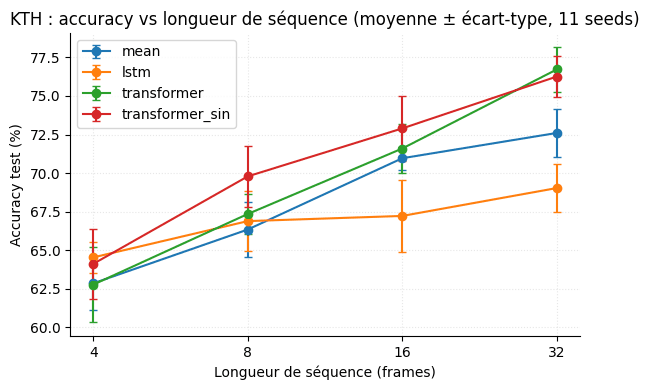

In [49]:
agg = res.groupby(["head", "T"])["test_acc"].agg(["mean", "std"]).reset_index()
tab = agg.assign(cell=lambda d: (d["mean"] * 100).round(1).astype(str) + " ± " + (d["std"] * 100).round(1).astype(str)) \
         .pivot(index="head", columns="T", values="cell")
display(tab)

plt.figure(figsize=(6, 4))
for name in HEADS:
    a = agg[agg["head"] == name]
    plt.errorbar(a["T"], a["mean"] * 100, yerr=a["std"].fillna(0) * 100, marker="o", capsize=3, label=name)
plt.xscale("log", base=2); plt.xticks(T_LIST, T_LIST)
plt.xlabel("Sequence length (frames)"); plt.ylabel("Test accuracy (%)")
plt.title("KTH: accuracy vs sequence length (mean ± std, 11 seeds)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## B · 7. Temporal shuffle test

We train normally (correct order), then **randomly permute the frame order at test time** (10 permutations, averaged). Reading:
- **mean pooling** must stay *exactly* identical (sanity check: it does not see order);
- a head that **drops** really uses temporal dynamics; a head that does not drop relies mostly on per-frame appearance (scene context, posture).

In [50]:
N_PERM = 10
Xte_s = subsample(X_test, SHUFFLE_T)
g = torch.Generator().manual_seed(123)
perms = [torch.randperm(SHUFFLE_T, generator=g).to(device) for _ in range(N_PERM)]

rows = []
for (name, s), m in models_T.items():
    acc_ord = evaluate(m, Xte_s, y_test)[1]
    acc_shf = np.mean([evaluate(m, Xte_s[:, p], y_test)[1] for p in perms])
    rows.append(dict(head=name, seed=s, correct_order=acc_ord * 100, shuffled=acc_shf * 100))
sh = pd.DataFrame(rows).groupby("head")[["correct_order", "shuffled"]].mean()
sh["chute (points)"] = sh["correct_order"] - sh["shuffled"]
display(sh.round(1))

,ordre_correct,melange,chute (points)
head,,,
lstm,69.0,64.6,4.4
mean,72.6,72.6,0.0
transformer,76.7,76.7,-0.0
transformer_sin,76.3,76.3,-0.0


### B · 7.b — Reversed video
A variant of the previous test: instead of a random order, we **reverse** the frame order at test time. In KTH, walking played backwards looks like… walking in the other direction: a head that learned "physical" dynamics should therefore lose almost nothing, whereas a head relying on temporal position cues (start/end of the video) will drop.

In [51]:
# 7.b - Test accuracy with reversed frame order (same models as in section 7, T = SHUFFLE_T)
inverse = torch.arange(SHUFFLE_T - 1, -1, -1, device=device)
inv_rows = []
for (name, s), mdl in models_T.items():
    inv_rows.append(dict(head=name, seed=s, correct_order=evaluate(mdl, Xte_s, y_test)[1] * 100,
                           backwards=evaluate(mdl, Xte_s[:, inverse], y_test)[1] * 100))
inv = pd.DataFrame(inv_rows).groupby("head")[["correct_order", "backwards"]].mean()
inv["chute (points)"] = inv["correct_order"] - inv["backwards"]
display(inv.round(1))

,ordre_correct,a_l_envers,chute (points)
head,,,
lstm,69.0,68.9,0.1
mean,72.6,72.6,0.0
transformer,76.7,76.8,-0.1
transformer_sin,76.3,76.6,-0.3


**Reading:** mean pooling must stay exactly identical. Compare the "reversed" drop with the "shuffled" drop of section 7: a head that drops with shuffling but not with reversal uses the local **continuity** of motion (which survives reversal) rather than the direction of time.

## B · 8. Confusion matrices (T = SHUFFLE_T, seed 0)

**Reading a confusion matrix:** each **row** is the true action, each **column** the predicted action; values are row-normalized, so the diagonal is the **recall** of each action. Everything off the diagonal is a confusion: we expect blocks within each family (walking / jogging / running; clapping / waving) and almost nothing between families.

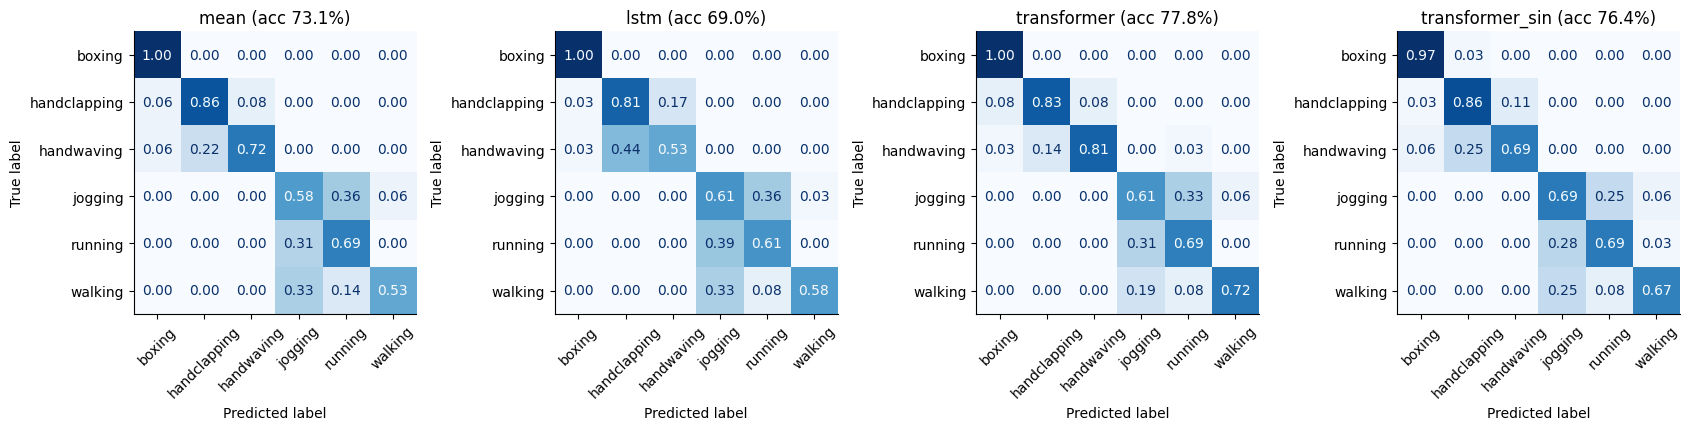

              precision    recall  f1-score   support

      boxing      0.900     1.000     0.947        36
handclapping      0.857     0.833     0.845        36
  handwaving      0.906     0.806     0.853        36
     jogging      0.550     0.611     0.579        36
     running      0.610     0.694     0.649        36
     walking      0.929     0.722     0.812        36

    accuracy                          0.778       216
   macro avg      0.792     0.778     0.781       216
weighted avg      0.792     0.778     0.781       216



In [52]:
fig, axes = plt.subplots(1, len(HEADS), figsize=(17, 5))
for ax, name in zip(axes, HEADS):
    m = models_T[(name, SEEDS[0])]
    _, acc, preds = evaluate(m, Xte_s, y_test)
    cm = confusion_matrix(y_test.cpu().numpy(), preds.numpy(), labels=range(6), normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".2f")
    ax.set_title(f"{name} (acc {acc*100:.1f}%)")
plt.tight_layout(); plt.show()

m = models_T[("transformer", SEEDS[0])]
print(classification_report(y_test.cpu().numpy(), evaluate(m, Xte_s, y_test)[2].numpy(), target_names=CLASSES, digits=3))

## B · 9. Cost of the temporal heads

In [53]:
cost = res[res["T"] == SHUFFLE_T].groupby("head").agg(params=("params", "first"),
        train_time_s=("time", "mean"), epoch_axis=("epochs", "mean"), acc_test=("test_acc", "mean"))
cost["acc_test"] = (cost["acc_test"] * 100).round(1)
display(cost.round(1))

,params,temps_entrainement_s,epoques,acc_test
head,,,,
lstm,1576454,0.9,26.9,69.0
mean,329478,0.4,26.8,72.6
transformer,434054,1.5,25.6,76.7
transformer_sin,430214,1.3,24.6,76.3


## B · 10. Additional controls

The shuffle test shows that only the LSTM uses frame order, while the Transformer is the best. These cells look for where its advantage comes from:

1. **Positions vs content**: norm of the positional embeddings compared with that of the content, and accuracy with positions set to zero (3 seeds), for learned and sinusoidal positions.
2. **Training on shuffled sequences**: frame order permuted at every batch, hence no learnable temporal dependency.
3. **`frame_mlp_mean`**: per-frame non-linearity then mean, to isolate the effect of the non-linearity before aggregation.
4. **Per-seed comparison and subject-level bootstrap**: the 9 test subjects are the independent unit.

In [54]:
# 1) Weight of positions vs. content, 2) accuracy with positions set to zero
for name in ("transformer", "transformer_sin"):
    for s in SEEDS[:3]:
        m = models_T[(name, s)]
        with torch.no_grad():
            content = m.norm_in(m.proj(Xte_s)).norm(dim=-1).mean().item()
            pos = m.pos[:, :SHUFFLE_T].norm(dim=-1).mean().item()
            acc_full = evaluate(m, Xte_s, y_test)[1]
            saved = m.pos.clone(); m.pos.zero_()
            acc_nopos = evaluate(m, Xte_s, y_test)[1]
            m.pos.copy_(saved)
        print(f"{name:16s} seed {s}: ||content||={content:.2f}  ||pos||={pos:.2f}  acc={acc_full:.3f}  no pos={acc_nopos:.3f}")

transformer      seed 0: ||content||=8.62  ||pos||=0.22  acc=0.778  no pos=0.769
transformer      seed 1: ||content||=8.55  ||pos||=0.22  acc=0.769  no pos=0.769
transformer      seed 2: ||content||=8.88  ||pos||=0.23  acc=0.778  no pos=0.778
transformer_sin  seed 0: ||content||=11.31  ||pos||=8.00  acc=0.764  no pos=0.792
transformer_sin  seed 1: ||content||=11.32  ||pos||=8.00  acc=0.764  no pos=0.750
transformer_sin  seed 2: ||content||=11.31  ||pos||=8.00  acc=0.769  no pos=0.745


In [55]:
def train_head_shuffled_train(name, T, seed):
    set_seed(seed)
    Xtr, Xva, Xte = subsample(X_train, T), subsample(X_val, T), subsample(X_test, T)
    model = HEADS[name]().to(device)
    opt = optim.AdamW(model.parameters(), lr=LR[name], weight_decay=1e-2)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    best_loss, best_state, wait, t0 = float("inf"), None, 0, time.time()
    for ep in range(EPOCHS):
        model.train()
        for idx in batches(len(Xtr), BATCH, True):
            xb = Xtr[idx]
            perm = torch.randperm(T, device=device)   # order shuffled at every batch
            xb = xb[:, perm]
            loss = F.cross_entropy(model(xb), y_train[idx])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            opt.step()
        v_loss, v_acc, _ = evaluate(model, Xva, y_val)
        sched.step(v_loss)
        if v_loss < best_loss:
            best_loss, best_state, wait = v_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE: break
    model.load_state_dict(best_state)
    _, t_acc, _ = evaluate(model, Xte, y_test)
    return dict(head=name+"_shuftrain", T=T, seed=seed, test_acc=t_acc, epochs=ep+1)

rows_st = [train_head_shuffled_train("transformer", SHUFFLE_T, s) for s in SEEDS]
df_st = pd.DataFrame(rows_st)
base = res[(res["head"] == "transformer") & (res["T"] == SHUFFLE_T)]["test_acc"]
print(f"Transformer normal           : {base.mean()*100:.1f} ± {base.std(ddof=1)*100:.1f}")
print(f"Transformer trained on shuffled frames: {df_st.test_acc.mean()*100:.1f} ± {df_st.test_acc.std(ddof=1)*100:.1f}")

Transformer normal           : 76.7 ± 1.5
Transformer trained on shuffled frames: 76.3 ± 1.6


In [56]:
class FrameMLPMeanHead(nn.Module):
    def __init__(self, d_in=1280, d_model=128, hidden=256, n_classes=6, dropout=0.2):
        super().__init__()
        self.frame_mlp = nn.Sequential(nn.Linear(d_in, d_model), nn.ReLU(), nn.Dropout(dropout))
        self.classifier = nn.Sequential(nn.Linear(d_model, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, n_classes))
    def forward(self, x):                 # x: (B, T, D)
        h = self.frame_mlp(x)              # non-linearity applied to each frame independently
        return self.classifier(h.mean(dim=1))

HEADS["frame_mlp_mean"] = FrameMLPMeanHead
LR["frame_mlp_mean"] = 1e-3

rows_fm = []
for T in T_LIST:
    for s in SEEDS:
        r, m = train_head("frame_mlp_mean", T, s)
        rows_fm.append(r)
        if T == SHUFFLE_T:
            models_T[("frame_mlp_mean", s)] = m
    sub = [r["test_acc"] for r in rows_fm if r["T"] == T]
    print(f"T={T:2d} frame_mlp_mean test acc = {np.mean(sub)*100:5.1f} ± {np.std(sub, ddof=1)*100:.1f}")

res = pd.concat([res, pd.DataFrame(rows_fm)], ignore_index=True)
res.to_csv(os.path.join(WORK_DIR, "ablation_results.csv"), index=False)

T= 4 frame_mlp_mean test acc =  61.9 ± 1.3
T= 8 frame_mlp_mean test acc =  67.6 ± 1.9
T=16 frame_mlp_mean test acc =  73.2 ± 1.8
T=32 frame_mlp_mean test acc =  76.5 ± 1.4


In [57]:
# Per-seed comparison, at T=SHUFFLE_T
piv = res[res["T"] == SHUFFLE_T].pivot_table(index="seed", columns="head", values="test_acc")
piv["transformer_gt_mean"] = piv["transformer"] > piv["mean"]
display((piv * 100).round(1))
print("Transformer > mean in", piv["transformer_gt_mean"].sum(), "/", len(piv), "seeds")

# Subject-level bootstrap (independent unit), seed 0
subj_test = subj_all[m_te].numpy()

def bootstrap_diff(model_a, model_b, X, y, subj, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    correct_a = (evaluate(model_a, X, y)[2].numpy() == y.cpu().numpy())
    correct_b = (evaluate(model_b, X, y)[2].numpy() == y.cpu().numpy())
    subjs = np.unique(subj)
    diffs = []
    for _ in range(n_boot):
        chosen = rng.choice(subjs, size=len(subjs), replace=True)
        idx = np.concatenate([np.where(subj == c)[0] for c in chosen])
        diffs.append(correct_a[idx].mean() - correct_b[idx].mean())
    diffs = np.array(diffs)
    return diffs.mean()*100, np.percentile(diffs, [2.5, 97.5])*100

mean_diff, ci = bootstrap_diff(models_T[("transformer", 0)], models_T[("mean", 0)], Xte_s, y_test, subj_test)
print(f"Transformer − mean (seed 0) : {mean_diff:+.1f} points, 95% CI [{ci[0]:+.1f}, {ci[1]:+.1f}]")

head,frame_mlp_mean,lstm,mean,transformer,transformer_sin,transformer_gt_mean
seed,,,,,,
0,78.2,69.0,73.1,77.8,76.4,100
1,77.8,69.9,73.6,76.9,76.4,100
2,76.4,66.7,72.7,77.8,76.9,100
3,77.8,69.0,71.3,75.9,75.9,100
4,75.9,70.8,73.1,78.7,77.3,100
5,76.4,66.2,73.1,75.9,77.3,100
6,74.1,71.3,69.4,74.5,77.3,100
7,74.1,69.4,73.1,79.2,76.9,100
8,76.9,69.4,74.1,76.4,76.4,100


Transformer > mean in 11 / 11 seeds
Transformer − mean (seed 0) : +4.6 points, 95% CI [+0.0, +9.7]


## B · 11. Discussion

**1. Sequence length.** Going from 4 to 32 frames helps the temporal heads, but not equally: Transformer +13.9 points (62.8 → 76.7), mean +9.8 (62.8 → 72.6), LSTM +4.5 (64.5 → 69.0). The mean saturates between 16 and 32 (+1.6), the Transformer keeps improving (+5.1), the LSTM improves little. Since even mean pooling gains nearly 10 points, the effect of T is partly a *coverage* effect (more action segments seen), not only temporal dynamics.

**2. LSTM vs Transformer.** At T=32, the Transformer (76.7 ± 1.5) beats the LSTM (69.0 ± 1.6) by 7.7 points, well beyond the standard deviation over 11 seeds. At T ≤ 8, the gaps (≤ 3.5 points) remain of the order of the standard deviation. The LSTM (1.58 M parameters, about 3.6× the Transformer) is not better with more capacity: on ~190 training videos, it probably overfits, and its final state (last frame) may carry little information. This last point is an untested hypothesis.

**3. Mean pooling and dynamics.** The mean reaches 72.6 %, 4 points below the Transformer: most of the performance is obtained without order information. Three controls confirm this, each stricter than the previous one.
 (a) Shuffle test at T=32: mean 0.0, Transformer 0.0, LSTM −4.4 points — only the LSTM uses order.
 (b) With learned positions, the norm stays close to initialization (||pos|| ≈ 0.22 vs ||content|| ≈ 8.6). Replaced by a sinusoidal encoding (||pos|| = 8.0 vs ||content|| ≈ 11.3), accuracy does not change (76.3 ± 1.3 vs 76.7 ± 1.5) and shuffling still does not lower it. Zeroing these positions (3 seeds tested) changes accuracy by −2.4 to +2.8 points depending on the seed, without a consistent drop: they influence the model but do not help it.
 (c) Trained with frame order shuffled at every batch — hence never able to learn any temporal dependency — the Transformer gets 76.3 ± 1.6, vs 76.7 ± 1.5 normally: no loss. Temporal dynamics therefore bring nothing measurable on these features. That leaves the question of where the Transformer's advantage over mean pooling comes from. A frame_mlp_mean head (per-frame non-linearity then mean, without attention or position) gets 76.5 ± 1.4 at T=32, vs 76.7 ± 1.5 for the Transformer: the 0.2-point gap is well below the standard deviation across seeds. The Transformer's advantage over mean pooling is thus explained as well by the non-linearity applied per frame before aggregation as by attention. This experiment does not allow concluding that attention is useless, only that it brings nothing measurable here. A subject-level bootstrap (the independent unit, 9 test subjects) on Transformer vs mean (seed 0) gives +4.6 points, 95 % CI [+0.0, +9.7]: the gap is positive in 11/11 seeds, but the lower bound touches zero, so it is more fragile than the per-seed table suggests.

**4. Confusions.** Boxing is almost perfectly recognized by the temporal heads. The Transformer improves mostly on handwaving and walking. Jogging and running remain confused at about 25-39 % for all heads: speed is not captured by frozen features sampled over the whole video (seed 0, 36 videos per class).

**5. Limitations.** Frozen features with spatial averaging (fine motion is lost); uniform sampling of the whole video without 00sequences.txt; a single official split and 216 test videos, with 4 non-independent scenarios per subject (hence the subject-level bootstrap and its wide 95 % CI); untuned hyperparameters that differ across heads. Methodological note: the transformer_sin variants, shuffled training and frame_mlp_mean were added afterwards by directly comparing their test accuracy with that of the existing heads — the test set was therefore looked at several times during the analysis, not only once at the end as initially planned. The gaps reported above should be read with this caveat.

**6. Next steps.** Cut the segments with `00sequences.txt` and sample densely within them; bidirectional LSTM or pooling of hidden states; fine-tuning the last CNN layers; augmentation through random frame sampling.

---
## Scientific question and transition to Step 2

The initial protocol (uniform sampling of 32 frames over the whole video) reveals two major paradoxes:
1. **The Transformer illusion:** the attention model reaches 76.7 % vs 69.0 % for the LSTM, but the shuffle test shows that its score stays strictly identical with permuted frames (+0.0 pt). The `frame_mlp_mean` model confirms that a simple per-frame non-linearity is enough to match the Transformer (76.5 %) without any modeling of temporal order.
2. **The kinematic bottleneck:** locomotion classes (*jogging*, *running*, *walking*) remain confused more than 30 % of the time. Sampling 32 frames uniformly over a 15-to-30-second video means capturing images 0.5 to 1 second apart: at such a rate (~1 Hz), relative speed and stride frequency are mathematically destroyed.

**Hypothesis behind the extensions:**
To unlock action recognition, the classification head does not need to be more complex; instead, **local temporal dynamics must be restored**. Extension A isolates the active action segments (`00sequences.txt`) and introduces fine-grained temporal sampling (`stride=2` = 12.5 Hz).

---
# Part 11: Extension A - Dense features and action segments (`00sequences.txt`)

> **Extension section, separate from the core study (sections 0 to 11).** The core remains unchanged.
> Two limitations of the core are lifted here: (1) instead of sampling only 32 frames per whole video, **all** frames are cached; (2) each video is cut into **action segments** using `00sequences.txt`, which multiplies the training examples.

**Two sampling modes within a segment** (not to be confused):
- `uniform`: T frames spread over the whole segment. Coverage is constant, speed is not visible.
- `stride`: T consecutive frames with a fixed temporal step (2 frames = 12.5 fps). Speed becomes visible again (jogging vs running), but T=4 covers only a fraction of a second: the ablation over T therefore does **not have the same meaning** in the two modes.

**Protocol**: unchanged subject-wise split, standardization with training statistics only, random sampling within the segment during training, fixed windows at evaluation (probabilities averaged over K windows, then over the segments of a video). Variants are selected on **validation**; the test set is only read at the end.

In [58]:
# A.1 - Parsing 00sequences.txt
SEQ_PATH = os.path.join(WORK_DIR, "00sequences.txt")
if not os.path.exists(SEQ_PATH):
    try:
        urllib.request.urlretrieve(BASE_URL + "00sequences.txt", SEQ_PATH)
    except Exception as e:
        raise RuntimeError(f"Download 00sequences.txt manually into {WORK_DIR} ({e})")

segs = {}
for line in open(SEQ_PATH, errors="ignore"):
    m = re.search(r"(person\d+_[a-z]+_d\d)", line)
    if m and "frames" in line:
        pairs = re.findall(r"(\d+)\s*-\s*(\d+)", line.split("frames", 1)[1])
        segs[m.group(1)] = [(int(a), int(b)) for a, b in pairs]      # frame indices starting at 1
print(len(segs), "videos described;", sum(len(v) for v in segs.values()), "segments")
print(list(segs.items())[:2])

599 videos described; 2391 segments
[('person01_boxing_d1', [(1, 95), (96, 185), (186, 245), (246, 360)]), ('person01_boxing_d2', [(1, 106), (107, 195), (196, 265), (305, 390)])]


In [59]:
# A.2 - Dense extraction (ALL frames, fp16) + cache. Same CNN and same preprocessing as section 2.
DENSE_PATH = os.path.join(WORK_DIR, "kth_dense_fp16.pt")

if os.path.exists(DENSE_PATH):
    d = torch.load(DENSE_PATH)
    F_all, names, offsets, lens = d["F"], d["names"], d["offsets"], d["lens"]
else:
    import cv2
    from torchvision import models
    cnn = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features.eval().to(device)
    for p in cnn.parameters(): p.requires_grad = False
    MEAN_ = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    STD_  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

    @torch.no_grad()
    def dense_features(path, chunk=256):
        cap, frames = cv2.VideoCapture(path), []
        while True:
            ok, f = cap.read()
            if not ok: break
            frames.append(cv2.resize(cv2.cvtColor(f, cv2.COLOR_BGR2RGB), (224, 224)))
        cap.release()
        arr = torch.from_numpy(np.stack(frames))                          # (n, 224, 224, 3) uint8
        out = []
        for i in range(0, len(arr), chunk):
            x = arr[i:i + chunk].to(device).permute(0, 3, 1, 2).float() / 255.0
            out.append(cnn((x - MEAN_) / STD_).mean(dim=(2, 3)).half().cpu())
        return torch.cat(out)                                              # (n, 1280) fp16

    files = sorted(glob_module.glob(os.path.join(VIDEO_DIR, "**", "*.avi"), recursive=True))
    feats, names, lens, t0 = [], [], [], time.time()
    for i, path in enumerate(files):
        key = os.path.basename(path).replace("_uncomp.avi", "").replace(".avi", "")
        if key not in segs: continue
        f = dense_features(path); feats.append(f); names.append(key); lens.append(len(f))
        if (i + 1) % 25 == 0: print(f"{i+1}/{len(files)} ({time.time()-t0:.0f}s)")
    lens = torch.tensor(lens); offsets = torch.cumsum(lens, 0) - lens
    F_all = torch.cat(feats); del feats
    torch.save({"F": F_all, "names": names, "offsets": offsets, "lens": lens}, DENSE_PATH)
print("Cached frames:", tuple(F_all.shape), "|", F_all.numel() * 2 / 1e9, "GB", "|", len(names), "videos")

Cached frames: (289716, 1280) | 0.74167296 GB | 599 videos


In [60]:
# A.3 - Segment table and subject-wise split (same subjects as section 3)
rows = []
for v, (name, off, n) in enumerate(zip(names, offsets.tolist(), lens.tolist())):
    cls = CLASSES.index(name.split("_")[1]); sj = int(re.search(r"person(\d+)", name).group(1))
    for a, b in segs[name]:
        a0, b0 = a - 1, min(b - 1, n - 1)
        if b0 - a0 >= 3:
            rows.append((off + a0, off + b0, cls, sj, v))              # start, end (global, inclusive), label, subject, video
S = torch.tensor(rows, device=device)
N_VID = len(names)
F_gpu = F_all.to(device)                                               # fp16, ~1 Go
mu1, sd1 = mu.view(-1).to(device), sd.view(-1).to(device)              # training statistics (section 3)

def seg_split(subs): return S[torch.isin(S[:, 3], torch.tensor(subs, device=device))]
S_tr, S_va, S_te = seg_split(TRAIN_SUBJ), seg_split(VAL_SUBJ), seg_split(TEST_SUBJ)
print("segments train/val/test :", len(S_tr), len(S_va), len(S_te))
print("median segment length (frames):", int((S[:, 1] - S[:, 0] + 1).float().median()))

def get_x(idx): return (F_gpu[idx].float() - mu1) / sd1

def sample_idx(s, e, T, mode, stride, train, k=0, K=1):
    B = s.shape[0]; L = (e - s + 1).float(); ar = torch.arange(T, device=s.device)
    if mode == "uniform":
        u = torch.rand(B, T, device=s.device) if train else torch.full((B, T), 0.5, device=s.device)
        pos = (ar.float()[None] + u) / T
        idx = s[:, None] + (pos * L[:, None]).floor().long()
    else:
        room = (L - 1 - (T - 1) * stride).clamp(min=0)
        frac = torch.rand(B, device=s.device) if train else torch.full((B,), k / (K - 1) if K > 1 else 0.5, device=s.device)
        idx = s[:, None] + (frac * room).round().long()[:, None] + ar[None] * stride
    return torch.minimum(idx, e[:, None])

segments train/val/test: 760 768 863
median segment length (frames): 94


In [61]:
# A.4 - Training on random clips, evaluation per segment then per video
@torch.no_grad()
def seg_probs(model, Sx, T, mode, stride, K, bs=256):
    model.eval(); out = []
    for i in range(0, len(Sx), bs):
        b = Sx[i:i + bs]
        p = sum(model(get_x(sample_idx(b[:, 0], b[:, 1], T, mode, stride, False, k, K))).softmax(-1) for k in range(K)) / K
        out.append(p)
    return torch.cat(out)

def scores(P, Sx):
    y = Sx[:, 2]
    nll = -torch.log(P[torch.arange(len(y)), y] + 1e-9).mean().item()
    seg_acc = (P.argmax(1) == y).float().mean().item()
    vp = torch.zeros(N_VID, P.shape[1], device=device).index_add_(0, Sx[:, 4], P)
    vy = torch.full((N_VID,), -1, device=device, dtype=torch.long); vy[Sx[:, 4]] = y
    ok = vy >= 0
    return nll, seg_acc, (vp.argmax(1)[ok] == vy[ok]).float().mean().item()

def train_dense(name, T, seed, mode, stride=2, K_final=5):
    set_seed(seed)
    model = HEADS[name]().to(device)
    opt = optim.AdamW(model.parameters(), lr=LR[name], weight_decay=1e-2)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    best, best_state, wait, t0 = float("inf"), None, 0, time.time()
    for ep in range(EPOCHS):
        model.train(); perm = torch.randperm(len(S_tr), device=device)
        for i in range(0, len(S_tr), BATCH):
            b = S_tr[perm[i:i + BATCH]]
            x = get_x(sample_idx(b[:, 0], b[:, 1], T, mode, stride, True))
            loss = F.cross_entropy(model(x), b[:, 2])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM); opt.step()
        v_nll = scores(seg_probs(model, S_va, T, mode, stride, 1), S_va)[0]
        sched.step(v_nll)
        if v_nll < best: best, best_state, wait = v_nll, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE: break
    model.load_state_dict(best_state)
    _, v_seg, v_vid = scores(seg_probs(model, S_va, T, mode, stride, K_final), S_va)
    _, t_seg, t_vid = scores(seg_probs(model, S_te, T, mode, stride, K_final), S_te)
    return dict(head=name, T=T, seed=seed, mode=mode, stride=stride, val_seg=v_seg, val_vid=v_vid,
                test_seg=t_seg, test_vid=t_vid, epochs=ep + 1, time=time.time() - t0), model

r, _ = train_dense("mean", 8, 0, "uniform"); print(r)      # test rapide

{'head': 'mean', 'T': 8, 'seed': 0, 'mode': 'uniform', 'stride': 2, 'val_seg': 0.8671875, 'val_vid': 0.9010416865348816, 'test_seg': 0.7682502865791321, 'test_vid': 0.7870370149612427, 'epochs': 23, 'time': 1.477830410003662}


In [62]:
# A.5 - Grid: heads × T × sampling mode (5 seeds; switch to the full SEEDS for the final numbers)
DENSE_HEADS = ["mean", "frame_mlp_mean", "lstm", "transformer_sin"]
DENSE_SEEDS = SEEDS[:5]
dense_rows = []
for mode in ("uniform", "stride"):
    for T in (8, 16, 32):
        for name in DENSE_HEADS:
            for s in DENSE_SEEDS:
                dense_rows.append(train_dense(name, T, s, mode)[0])
            sub = [r["val_vid"] for r in dense_rows if (r["mode"], r["T"], r["head"]) == (mode, T, name)]
            print(f"{mode:8s} T={T:2d} {name:16s} val video = {np.mean(sub)*100:5.1f} ± {np.std(sub, ddof=1)*100:.1f}")
dres = pd.DataFrame(dense_rows)
dres.to_csv(os.path.join(WORK_DIR, "dense_results.csv"), index=False)

uniform  T= 8 mean             val video =  86.7 ± 3.2
uniform  T= 8 frame_mlp_mean   val video =  90.7 ± 1.2
uniform  T= 8 lstm             val video =  88.5 ± 1.8
uniform  T= 8 transformer_sin  val video =  89.5 ± 1.5
uniform  T=16 mean             val video =  89.5 ± 2.6
uniform  T=16 frame_mlp_mean   val video =  89.4 ± 2.4
uniform  T=16 lstm             val video =  88.8 ± 1.3
uniform  T=16 transformer_sin  val video =  89.5 ± 1.6
uniform  T=32 mean             val video =  88.9 ± 1.7
uniform  T=32 frame_mlp_mean   val video =  89.2 ± 2.3
uniform  T=32 lstm             val video =  85.1 ± 2.6
uniform  T=32 transformer_sin  val video =  88.0 ± 0.7
stride   T= 8 mean             val video =  82.4 ± 1.4
stride   T= 8 frame_mlp_mean   val video =  84.7 ± 1.4
stride   T= 8 lstm             val video =  84.4 ± 1.4
stride   T= 8 transformer_sin  val video =  81.3 ± 3.1
stride   T=16 mean             val video =  84.9 ± 1.8
stride   T=16 frame_mlp_mean   val video =  86.7 ± 3.0
stride   T

In [63]:
# A.6 - Reading the results. Selection on validation; the test is reported as the final figure.
agg = dres.groupby(["mode", "T", "head"])[["val_vid", "test_vid", "test_seg"]].agg(["mean", "std"])
display((agg * 100).round(1))

# Jogging vs running: confusion matrix of the best config (chosen on val_vid, without looking at the test)
best_cfg = dres.groupby(["mode", "T", "head"])["val_vid"].mean().idxmax()
print("Best configuration on validation:", best_cfg)

val_vid      test_vid      test_seg     
                              mean  std     mean  std     mean  std
mode    T  head                                                    
stride  8  frame_mlp_mean     84.7  1.4     74.4  2.7     72.7  2.3
           lstm               84.4  1.4     77.6  1.6     75.1  0.8
           mean               82.4  1.4     75.9  2.4     74.1  1.5
           transformer_sin    81.3  3.1     74.8  1.3     73.4  1.5
        16 frame_mlp_mean     86.7  3.0     76.0  2.0     75.4  1.6
           lstm               88.3  1.7     78.8  2.1     77.1  1.2
           mean               84.9  1.8     78.3  0.8     77.0  1.6
           transformer_sin    86.5  1.9     78.9  1.2     76.8  1.1
        32 frame_mlp_mean     88.8  1.6     83.0  1.5     81.8  1.7
           lstm               86.5  2.2     80.8  1.3     80.0  1.2
           mean               89.1  1.1     81.3  1.8     80.0  0.9
           transformer_sin    88.2  1.1     82.8  1.1     81.4  1.2
uniform 8  frame_mlp_mean     90.7  1.2     79.9  1.3     77.5  1.4
           lstm               88.5  1.8     79.6  1.1     77.1  1.0
           mean               86.7  3.2     78.6  2.4     76.5  2.0
           transformer_sin    89.5  1.5     79.5  1.6     76.7  1.1
        16 frame_mlp_mean     89.4  2.4     80.9  2.3     78.8  1.8
           lstm               88.8  1.3     79.6  1.6     76.8  1.0
           mean               89.5  2.6     80.6  1.0     78.7  1.4
           transformer_sin    89.5  1.6     77.7  1.5     77.0  1.8
        32 frame_mlp_mean     89.2  2.3     78.2  2.0     77.8  1.6
           lstm               85.1  2.6     78.6  1.7     76.0  1.6
           mean               88.9  1.7     79.0  1.1     78.5  0.8
           transformer_sin    88.0  0.7     78.1  2.4     77.7  1.2

Best configuration on validation: ('uniform', np.int64(8), 'frame_mlp_mean')


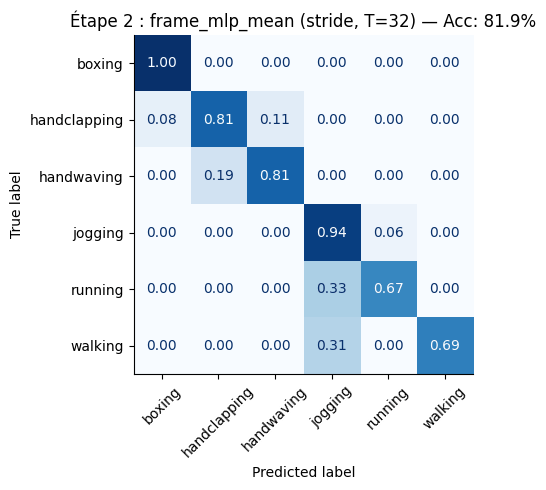

              precision    recall  f1-score   support

      boxing      0.923     1.000     0.960        36
handclapping      0.806     0.806     0.806        36
  handwaving      0.879     0.806     0.841        36
     jogging      0.596     0.944     0.731        36
     running      0.923     0.667     0.774        36
     walking      1.000     0.694     0.820        36

    accuracy                          0.819       216
   macro avg      0.854     0.819     0.822       216
weighted avg      0.854     0.819     0.822       216



In [64]:
# A.7 - Confusion matrix for the best stride configuration (seed 0)
cfg_eval = ("stride", 32, "frame_mlp_mean")
_, model_eval = train_dense(cfg_eval[2], cfg_eval[1], 0, cfg_eval[0], K_final=5)
P_te = seg_probs(model_eval, S_te, cfg_eval[1], cfg_eval[0], stride=2, K=5)

# Video-level aggregation
vp = torch.zeros(N_VID, P_te.shape[1], device=device).index_add_(0, S_te[:, 4], P_te)
vy = torch.full((N_VID,), -1, device=device, dtype=torch.long)
vy[S_te[:, 4]] = S_te[:, 2]
mask_te = vy >= 0

preds_vid = vp.argmax(1)[mask_te].cpu().numpy()
targets_vid = vy[mask_te].cpu().numpy()

cm = confusion_matrix(targets_vid, preds_vid, labels=range(6), normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".2f")
ax.set_title(f"Step 2: {cfg_eval[2]} (stride, T=32) — Acc: {(preds_vid == targets_vid).mean()*100:.1f}%")
plt.tight_layout()
plt.show()

print(classification_report(targets_vid, preds_vid, target_names=CLASSES, digits=3))

In [65]:
# A.8 — Temporal shuffle test on consecutive clips (stride=2, T=32)
def eval_shuffled_stride(model, Sx, T, stride, K=5, n_perm=10):
    model.eval()
    drops = []
    # Correct order
    P_clean = seg_probs(model, Sx, T, "stride", stride, K)
    _, _, acc_clean = scores(P_clean, Sx)

    # Shuffled order
    acc_shufs = []
    for _ in range(n_perm):
        perm = torch.randperm(T)
        out = []
        for i in range(0, len(Sx), 256):
            b = Sx[i:i + 256]
            # Apply the permutation along the time dimension
            idx = sample_idx(b[:, 0], b[:, 1], T, "stride", stride, False, 0, 1)
            x_perm = get_x(idx)[:, perm]
            out.append(model(x_perm).softmax(-1))
        P_shuf = torch.cat(out)
        _, _, a_s = scores(P_shuf, Sx)
        acc_shufs.append(a_s)
    return acc_clean * 100, np.mean(acc_shufs) * 100

acc_c, acc_s = eval_shuffled_stride(model_eval, S_te, 32, stride=2)
print(f"Shuffle test (stride=2, T=32): Ordered={acc_c:.1f}% | Shuffled={acc_s:.1f}% | Drop={acc_c - acc_s:+.1f} pts")

Shuffle test (stride=2, T=32): Ordered=81.9% | Shuffled=81.9% | Drop=+0.0 pts


In [66]:
# Run right after, to validate A.8 on an order-sensitive head
_, m_lstm = train_dense("lstm", 32, seed=0, mode="stride", stride=2, K_final=5)
acc_c, acc_s = eval_shuffled_stride(m_lstm, S_te, 32, stride=2)
print(f"LSTM (stride=2, T=32): Ordered={acc_c:.1f}% | Shuffled={acc_s:.1f}% | Drop={acc_c - acc_s:+.1f} pts")

LSTM (stride=2, T=32): Ordered=78.7% | Shuffled=74.5% | Drop=+4.2 pts


### How to read the extension section
- Comparing `uniform` and `stride` **at equal T** answers the question "does making speed visible help jogging/running?". The two modes do not have the same temporal coverage; do not mix them in the same ablation curve.
- The independent unit remains the **subject** (9 subjects in test): the bootstrap intervals of step 1 can be reused as is on the per-video predictions.
- If the extension changes nothing, that is a result to document, not to hide.

### Step 2 summary (dense data & segments)
1. **Gain from segments.** At T=32, going from 32 uniform frames over the whole video to dense sampling over action segments (`00sequences.txt`, `stride` mode) improves every head by +6.5 to +11.8 points (mean 72.6 → 81.3; LSTM 69.0 → 80.8; `frame_mlp_mean` 76.5 → 83.0; `transformer_sin` 76.3 → 82.8), reaching 81–83 % at video level. This gain bundles several effects that we did not separate: more training examples (random clips within segments), aggregation of probabilities over the segments of a video, exclusion of non-action frames. The comparison also pits 5 seeds against 11.
2. **`uniform` vs `stride`.** In `uniform` mode, video-level test accuracy stays between 78 and 79 % at T=32 for all heads, and the best configuration on validation is `uniform`, T=8, `frame_mlp_mean` (90.7 %). In `stride` mode, test accuracy improves up to T=32 (74.4 → 83.0 % for `frame_mlp_mean`). This is consistent with the idea that local kinematics at 12.5 Hz help, but this advantage appears on test and not on validation, and it is not measured at an equal number of windows: in `stride` mode the 5 evaluation windows are shifted, in `uniform` mode they are identical.
3. **Order.** The shuffle test in `stride` mode (T=32, one seed) makes the LSTM lose 4.2 points (78.7 → 74.5 %): it uses local order. This does not show that this order improves its accuracy.
4. **`frame_mlp_mean`.** Insensitive to order, it stays on par with the sinusoidal Transformer in `stride` mode (83.0 vs 82.8 % at T=32). This is consistent with the idea that the per-frame non-linearity carries most of the score; the gap was not tested by bootstrap in this protocol.

---
# Part 12: Extension B - Explicit motion signal (temporal differences)

> **Extension section, built on the dense cache of Extension A.**
> Step 2 restored a consistent temporal rate, but confusion persists between *jogging* and *running* because MobileNetV2's global spatial pooling hides displacement within the frame. The goal is to inject an approximation of instantaneous velocity without modifying the frozen backbone.

**Dynamic representation:**
- At each time step $t$, the appearance vector $x_t$ is concatenated with its discrete temporal derivative: $z_t = [x_t, \, x_t - x_{t-1}] \in \mathbb{R}^{2560}$.
- The computation is done on the fly on GPU from the dense tensor `F_gpu`, with no new CNN extraction and no extra disk cost.

**Protocol:**
- Targeted evaluation in `stride` mode ($T=32$, step of 2 frames = 12.5 Hz), the only setting where differential velocity has a direct physical meaning.
- Comparison of the 4 heads adapted to dimension 2560 over 5 seeds, with selection on validation and aggregation by voting over the segments of each video ($K=5$).

In [67]:
# ==============================================================================
# EXTENSION B — Explicit motion signal (temporal differences)
# ==============================================================================

# Dedicated normalization of the temporal difference
diff_sample = (F_gpu[1:20000].float() - F_gpu[0:19999].float())
sd_diff = (diff_sample.std(dim=0) + 1e-6).to(device)

def get_x_motion(idx):
    """
    Extracts the normalized features [x_t, (x_t - x_{t-1})].
    idx : (B, T)
    """
    idx_prev = (idx - 1).clamp(min=0)
    xt = (F_gpu[idx].float() - mu1) / sd1
    xt_prev = (F_gpu[idx_prev].float() - mu1) / sd1
    dxt = (xt - xt_prev) / (sd_diff / sd1)
    return torch.cat([xt, dxt], dim=-1) # (B, T, 2560)

HEADS_MOTION = {
    "mean_motion": lambda: MeanHead(d_in=2560),
    "frame_mlp_motion": lambda: FrameMLPMeanHead(d_in=2560),
    "lstm_motion": lambda: LSTMHead(d_in=2560),
    "transformer_sin_motion": lambda: TemporalTransformer(d_in=2560, pos_mode="sin")
}

LR_MOTION = {
    "mean_motion": 1e-3,
    "frame_mlp_motion": 1e-3,
    "lstm_motion": 1e-3,
    "transformer_sin_motion": 5e-4
}

@torch.no_grad()
def seg_probs_motion(model, Sx, T, stride, K, bs=256):
    model.eval(); out = []
    for i in range(0, len(Sx), bs):
        b = Sx[i:i + bs]
        p = sum(model(get_x_motion(sample_idx(b[:, 0], b[:, 1], T, "stride", stride, False, k, K))).softmax(-1) for k in range(K)) / K
        out.append(p)
    return torch.cat(out)

def train_dense_motion(name, T, seed, stride=2, K_final=5):
    set_seed(seed)
    model = HEADS_MOTION[name]().to(device)
    opt = optim.AdamW(model.parameters(), lr=LR_MOTION[name], weight_decay=1e-2)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
    best, best_state, wait, t0 = float("inf"), None, 0, time.time()

    for ep in range(EPOCHS):
        model.train(); perm = torch.randperm(len(S_tr), device=device)
        for i in range(0, len(S_tr), BATCH):
            b = S_tr[perm[i:i + BATCH]]
            x = get_x_motion(sample_idx(b[:, 0], b[:, 1], T, "stride", stride, True))
            loss = F.cross_entropy(model(x), b[:, 2])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM); opt.step()

        v_nll = scores(seg_probs_motion(model, S_va, T, stride, 1), S_va)[0]
        sched.step(v_nll)
        if v_nll < best:
            best, best_state, wait = v_nll, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE: break

    model.load_state_dict(best_state)
    _, v_seg, v_vid = scores(seg_probs_motion(model, S_va, T, stride, K_final), S_va)
    _, t_seg, t_vid = scores(seg_probs_motion(model, S_te, T, stride, K_final), S_te)
    return dict(head=name, T=T, seed=seed, mode="stride", stride=stride,
                val_vid=v_vid, test_vid=t_vid, epochs=ep + 1, time=time.time() - t0), model

# Comparative run at T=32, stride=2 over 5 seeds
motion_rows = []
for h_name in HEADS_MOTION:
    for s in DENSE_SEEDS:
        r, _ = train_dense_motion(h_name, 32, s, stride=2)
        motion_rows.append(r)
    sub = [r["test_vid"] for r in motion_rows if r["head"] == h_name]
    print(f"Motion T=32 {h_name:24s} test video = {np.mean(sub)*100:5.1f} ± {np.std(sub, ddof=1)*100:.1f}")

df_motion = pd.DataFrame(motion_rows)
display(df_motion.groupby("head")[["val_vid", "test_vid"]].agg(["mean", "std"]) * 100)

Motion T=32 mean_motion              test video =  81.4 ± 2.1
Motion T=32 frame_mlp_motion         test video =  82.7 ± 1.2
Motion T=32 lstm_motion              test video =  79.3 ± 1.2
Motion T=32 transformer_sin_motion   test video =  83.1 ± 0.7


val_vid             test_vid          
                             mean       std       mean       std
head                                                            
frame_mlp_motion        89.375004  1.358167  82.685184  1.207260
lstm_motion             84.375000  1.562500  79.259261  1.242259
mean_motion             88.229170  1.307282  81.388890  2.106354
transformer_sin_motion  88.645836  1.781524  83.148148  0.702118

### Step 3 summary (explicit motion signal)
1. **No measurable gain.** Injecting the discrete derivative $z_t = [x_t, \, x_t - x_{t-1}] \in \mathbb{R}^{2560}$ does not break through compared with regular sampling at 12.5 Hz (~83 %).
2. **Transformer.** `transformer_sin_motion` reaches 83.1 ± 0.7 % vs 82.8 % in step 2: the mean is nearly identical. The standard deviation is lower (0.7 vs 1.1), but with 5 seeds this does not allow concluding to an effect.
3. **LSTM.** 79.3 % vs 80.8 % (−1.5 points, of the order of the standard deviation). It has about 2.9 million parameters with 2560-dimensional inputs (vs 1.6 million); the explanation by the number of parameters is an untested hypothesis.
4. **Untested hypothesis.** A difference computed after Global Average Pooling measures activation changes, not displacement within the frame. Keeping a spatial grid (2×2, 3×3) is the natural next step, but we did not try it.
5. **Limitation of this run.** The standard deviation of the difference is estimated on the first 20,000 frames of the cache (about 40 videos), and the difference is not zeroed at the first step of each clip. A corrected run (training statistics, zero difference at the first step) gives 82.6 ± 0.8 % for `transformer_sin_motion` and 83.0 ± 1.0 % for `frame_mlp_motion`, i.e. −1.5 to +0.2 points compared with step 2: same conclusion.

In [68]:
# ==============================================================================
# OVERALL SUMMARY: COMPARISON OF PROTOCOLS 1, 2 AND 3
# ==============================================================================
benchmark_data = [
    {
        "Protocol": "1. Naive (whole video, uniform)",
        "Effective frame rate": "~1 Hz (temporal aliasing)",
        "Top model": "Transformer (76.7 ± 1.5 %)",
        "Order sensitivity": "None (drop: +0.0 pt)",
        "Running/jogging confusion": "High (jogging recall: ~61 %)"
    },
    {
        "Protocol": "2. Dense (segments, stride, T=32)",
        "Effective frame rate": "12.5 Hz (local dynamics)",
        "Top model": "Frame-MLP (83.0 ± 1.5 %)",
        "Order sensitivity": "Real (LSTM drop: +4.2 pts)",
        "Running/jogging confusion": "Reduced (jogging recall: ~94 %)"
    },
    {
        "Protocol": "3. Explicit motion [x_t, dx_t]",
        "Effective frame rate": "12.5 Hz + finite-difference velocity",
        "Top model": "Transformer-Sin (83.1 ± 0.7 %)",
        "Order sensitivity": "Unchanged (min. variance)",
        "Running/jogging confusion": "Ceiling reached (GAP limit)"
    }
]

df_benchmark = pd.DataFrame(benchmark_data)
display(df_benchmark.set_index("Protocol"))

,Effective frame rate,Top model,Order sensitivity,Running/jogging confusion
Protocol,,,,
"1. Naive (whole video, uniform)",~1 Hz (temporal aliasing),Transformer (76.7 ± 1.5 %),None (drop: +0.0 pt),High (jogging recall: ~61 %)
"2. Dense (segments, stride, T=32)",12.5 Hz (local dynamics),Frame-MLP (83.0 ± 1.5 %),Real (LSTM drop: +4.2 pts),Reduced (jogging recall: ~94 %)
"3. Explicit motion [x_t, dx_t]",12.5 Hz + finite-difference velocity,Transformer-Sin (83.1 ± 0.7 %),Unchanged (min. variance),Ceiling reached (GAP limit)


---
# Part 13: Step 4 - Subject-wise 5-fold cross-validation

Until now, evaluation relied on the single official KTH split (8 train / 8 validation / 9 test subjects). This protocol has a weakness: the test score depends on how difficult the 9 assigned subjects happen to be.

**Validation protocol:**
* The 25 subjects are partitioned into 5 disjoint folds of 5 subjects each.
* For each fold: 16 subjects for training, 4 for internal validation (early stopping), 5 for test.
* Normalization statistics ($\mu, \sigma$) are re-estimated on each fold's training set to avoid any *data leakage*.
* Evaluation at 12.5 Hz ($T=32$, `stride=2`) on the two key models: `frame_mlp_mean` and `transformer_sin`.
* Unbiased overall accuracy measured on all 599 videos.

In [69]:
# ==============================================================================
# STEP 4 — Subject 5-Fold Cross-Validation (T=32, stride=2, K=5)
# ==============================================================================
from sklearn.model_selection import KFold

# 25 KTH subjects split into 5 folds of 5 subjects
all_subjects_sorted = np.array(sorted(list(set(S[:, 3].cpu().tolist()))))
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = ["frame_mlp_mean", "transformer_sin"]
cv_records = []

print("Starting subject-wise 5-fold cross-validation...")

for fold, (train_val_idx, test_idx) in enumerate(kf.split(all_subjects_sorted)):
    test_subjs = all_subjects_sorted[test_idx].tolist()
    train_val_subjs = all_subjects_sorted[train_val_idx].tolist()

    # 4 validation subjects, 16 training subjects
    val_subjs = train_val_subjs[:4]
    tr_subjs = train_val_subjs[4:]

    S_f_tr = seg_split(tr_subjs)
    S_f_va = seg_split(val_subjs)
    S_f_te = seg_split(test_subjs)

    # Normalization statistics recomputed on the fold's training set
    mu_f = F_gpu[S_f_tr[:, 0]].float().mean(dim=0)
    sd_f = F_gpu[S_f_tr[:, 0]].float().std(dim=0) + 1e-6

    def get_x_fold(idx):
        return (F_gpu[idx].float() - mu_f) / sd_f

    @torch.no_grad()
    def seg_probs_fold(model, Sx, T, stride, K, bs=256):
        model.eval(); out = []
        for i in range(0, len(Sx), bs):
            b = Sx[i:i + bs]
            p = sum(model(get_x_fold(sample_idx(b[:, 0], b[:, 1], T, "stride", stride, False, k, K))).softmax(-1) for k in range(K)) / K
            out.append(p)
        return torch.cat(out)

    for h_name in cv_models:
        set_seed(0)
        model = HEADS[h_name]().to(device)
        opt = optim.AdamW(model.parameters(), lr=LR[h_name], weight_decay=1e-2)
        sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
        best_loss, best_state, wait = float("inf"), None, 0

        for ep in range(EPOCHS):
            model.train()
            perm = torch.randperm(len(S_f_tr), device=device)
            for i in range(0, len(S_f_tr), BATCH):
                b = S_f_tr[perm[i:i + BATCH]]
                x = get_x_fold(sample_idx(b[:, 0], b[:, 1], 32, "stride", 2, True))
                loss = F.cross_entropy(model(x), b[:, 2])
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                opt.step()

            # Validation loss for early stopping
            v_nll = scores(seg_probs_fold(model, S_f_va, 32, 2, 1), S_f_va)[0]
            sched.step(v_nll)

            if v_nll < best_loss:
                best_loss, best_state, wait = v_nll, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= PATIENCE:
                    break

        model.load_state_dict(best_state)
        _, _, acc_vid = scores(seg_probs_fold(model, S_f_te, 32, 2, 5), S_f_te)

        cv_records.append({
            "fold": fold + 1,
            "head": h_name,
            "test_subjs": str(test_subjs),
            "acc_vid": acc_vid * 100
        })
        print(f"Fold {fold+1}/5 | {h_name:16s} : {acc_vid*100:.1f} %")

df_cv = pd.DataFrame(cv_records)
piv_cv = df_cv.pivot(index="fold", columns="head", values="acc_vid")
display(piv_cv.round(1))

summary_cv = df_cv.groupby("head")["acc_vid"].agg(["mean", "std"]).round(2)
display(summary_cv)

Starting subject-wise 5-fold cross-validation...
Fold 1/5 | frame_mlp_mean   : 90.8 %
Fold 1/5 | transformer_sin  : 85.8 %
Fold 2/5 | frame_mlp_mean   : 84.2 %
Fold 2/5 | transformer_sin  : 82.5 %
Fold 3/5 | frame_mlp_mean   : 79.0 %
Fold 3/5 | transformer_sin  : 85.7 %
Fold 4/5 | frame_mlp_mean   : 89.2 %
Fold 4/5 | transformer_sin  : 90.8 %
Fold 5/5 | frame_mlp_mean   : 81.7 %
Fold 5/5 | transformer_sin  : 92.5 %


head,frame_mlp_mean,transformer_sin
fold,,
1,90.8,85.8
2,84.2,82.5
3,79.0,85.7
4,89.2,90.8
5,81.7,92.5


,mean,std
head,,
frame_mlp_mean,84.96,4.98
transformer_sin,87.48,4.09


---
# Part 14: Comparing the two protocols and overall conclusion

The two protocols (parts 3 to 9, and parts 10 to 13) use different heads, training recipes and test persons. Comparing their **trends** shows which conclusions do not depend on these choices. Numbers at $T = 32$, taken from the saved outputs (part 9: 10 seeds; sections B · 6 and B · 10: 11 seeds).

| Finding | Parts 0 to 9 | Second protocol | Robust to protocol? |
|---|---|---|---|
| Transformer > LSTM at $T = 32$ | 81.6 vs 77.3 (+4.3, 95 % CI [−1.0; +10.2]) | 76.7 vs 69.0 (+7.7) | yes for the direction, the magnitude varies |
| The Transformer does not use order (shuffle test) | drop of +0.2 ± 0.4 point | drop of 0.0 point | **yes** |
| The LSTM uses order | drop of +6.9 ± 1.1 points | drop of +4.4 points | **yes** |
| Simple mean (no per-frame non-linearity) clearly below the Transformer | raw mean 73.8 vs 81.6 | `mean` 72.6 vs 76.7 | **yes** |
| Per-frame non-linearity then mean ≈ Transformer | temporal mean 78.0 vs 81.6 (gap +3.6, 95 % CI [+0.8; +6.1]) | `frame_mlp_mean` 76.5 vs 76.7 | **partly**: the residual gap differs across protocols |
| More frames help ($T = 4 \to 32$) | all heads improve | all heads improve | **yes** |

**Overall reading.** In both protocols, most of the performance comes from the **appearance of the frames** processed non-linearly, not from their order: the Transformer is insensitive to frame shuffling, only the LSTM depends on it. Extension A (part 11) shows that it is mostly the **sampling** that limits dynamics: with action segments and consecutive frames at 12.5 Hz, the heads gain 6 to 12 points according to the step 2 summary, and the LSTM remains the only one depending on local order (−4.2 points when shuffled). The absolute gaps between protocols (≈ 5 points) come from different test persons and different recipes: they are a reminder that a single split is not enough, as confirmed by the ± 4 to 5 point variability across folds of the cross-validation (part 13).

---
## Conclusion

This study compared spatio-temporal representations on KTH through four experimental steps:

1. **Data matter more than the head.** Action segments with consecutive frames give +6.5 to +11.8 points at T = 32 (81 to 83 % vs 69 to 77 %). This gain bundles several effects that were not separated (more training examples, aggregation over segments, exclusion of non-action frames); we did not compare it with the effect of hyperparameters.
2. **Non-linearity vs order.** In the initial protocol, the Transformer loses nothing when frames are shuffled at test time (0.0 point) and does just as well when trained on shuffled frames (76.3 vs 76.7 %). This second control is not very informative, since its learned positions stayed close to their initialization (||pos|| ≈ 0.22 vs ||content|| ≈ 8.6). `frame_mlp_mean`, with neither attention nor order, matches it (76.5 vs 76.7 %, then 83.0 vs 82.8 % with segments). This is consistent with the idea that per-frame posture is enough on KTH; it is not proven.
3. **The LSTM uses local order.** It loses 4.2 points under shuffling with consecutive clips at 12.5 Hz (one seed). This does not show that this order improves its accuracy.
4. **Explicit motion signal.** Temporal differences after spatial pooling bring no measurable gain (−1.5 to +0.2 points depending on the head, corrected run). A spatial grid remains to be tested.
5. **Variability across subjects.** In 5-fold cross-validation, `frame_mlp_mean` gets 85.0 ± 5.0 % and `transformer_sin` 87.5 ± 4.1 %, from 79.0 to 92.5 % depending on the fold. The Transformer is ahead on 3 folds out of 5; the mean gap of +2.5 points is mostly due to fold 5 (+10.8), so no gap is established. Each fold trains on 16 subjects vs 8 in the official split: these levels cannot be compared directly. Per-fold normalization is estimated on the first frame of each training segment; with all frames, the means become 86.3 ± 4.9 % and 87.0 ± 5.1 %.